# 03 ML Pipeline: Customer Tribe Discovery

This notebook starts from the prepared parquet outputs created by Notebook 02. It does not repeat raw loading, cleaning, or exploratory data quality work from Notebooks 01 and 02.

The goal is to discover product-first customer tribes from purchase behavior. The client hypothesis is roughly 10-15 tribes, but that range is not used as a modeling constraint. The final recommendation is selected from metrics, stability-ready diagnostics, cluster balance, product/sector lift interpretability, and business usefulness.

## Table of Contents

| Section | What it covers |
|---|---|
| [Stage 0: Load Prepared Data](#stage-0) | Sets the run mode, validates paths, loads prepared transactions, and previews the input data. |
| [Stage 0.5: Expensive Cache Audit](#stage-0-5) | Checks whether Stage 1-6 artifacts can be reused safely from cache. |
| [Stage 1: Basket Construction](#stage-1) | Converts checkout records into basket sentences for product embedding training. |
| [Stage 2: Item2Vec Product Embeddings](#stage-2) | Builds or loads product embeddings from product co-purchase behavior. |
| [Stage 3: Product Embedding Validation](#stage-3) | Reviews product-neighbor diagnostics and embedding quality checks. |
| [Stage 4: Customer Embeddings](#stage-4) | Creates product-first customer embeddings from purchased products and quantities. |
| [Stage 5: Official Feature Set](#stage-5) | Builds the official product/quantity feature set and supporting non-demographic behavior summaries. |
| [Stage 6: Hard UMAP-HDBSCAN Core Tribe Discovery](#stage-6) | Builds the UMAP customer manifold, runs three hard HDBSCAN passes, and exports core-tribe diagnostics. |
| [Stage 6.6: Quality, Stability, Readiness, and Promotion Audit](#stage-6-6) | Tests density quality, stability, confidence, readiness, and promotion blockers before profiling. |
| [Stage 6.7: Remaining-Customer Evidence](#stage-6-7) | Segments customers still unassigned after the hard merge and prepares affinity evidence. |
| [Stage 6.8: Tribe Evidence Assembly](#stage-6-8) | Precomputes all raw-data tribe evidence so Stage 7 can run from cached aggregate artifacts. |
| [Stage 7: Tribe Profiling and Stakeholder Handoff](#stage-7) | Profiles all retained tribes, audits review tribes, analyzes remaining customers, sizes soft audiences, maps relationships, and writes the final handoff. |

Tribe discovery is documented as a clear late-stage progression:

| Layer | Pipeline stage | What it proves | Main outputs |
|---|---|---|---|
| 1. Product-only modeling signal | Stages 4-5 | Official clustering uses product identity and quantity, not demographics, spend, or behavior KPIs. | Customer embeddings, feature-set diagnostics |
| 2. Organic core tribes | Stage 6.1-6.8 | Dense product-purchase behavior groups exist without forcing every customer into a tribe, retained clusters are checked before profiling, remaining customers are segmented separately, and all raw evidence is assembled before interpretation. | UMAP representation, hard HDBSCAN assignments, representation/density evidence, stability/readiness report, third-pass HDBSCAN, promotion audit, remaining-customer segments, tribe evidence bundle |
| 3. Tribe profiles | Stage 7 | Promoted and review tribes are profiled from Stage 6.8 aggregate and per-tribe evidence; only promoted tribes enter the final core story. | All-tribe profiles, persona cards, review audit, remaining-customer analysis, relationship atlas, manifest |
| 4. Supporting proof | Stage 7 | Detailed product and comparison artifacts support specific claims without crowding the main read. | Product summaries, tribe comparison, customer metric context |

Read the official result in that order: first whether hard organic core tribes exist, then whether Stage 6.6 stability/readiness supports profiling them, then what Stage 6.7 says about customers still outside the hard tribes, then whether Stage 6.8 assembled the evidence cache cleanly, then whether the Stage 7 evidence storyline makes the official tribes interpretable, distinct, caveated, and profileable. Spend and KPIs are interpretation context only; they are never part of the clustering signal.


<a id="stage-0"></a>

## Stage 0: Load Prepared Data

Notebook 03 starts from the prepared transaction parquet created earlier. It validates the fields needed for ML and only merges product metadata if the prepared file does not already contain it. No raw cleaning decisions are made here.


In [ ]:
import os
from pathlib import Path
import sys

from IPython.display import Image, Markdown, display

# Optional notebook override. Set to "dev" or "prod" to force a mode;
# leave as None to honor CARREFOUR_MODE, then the YAML default_mode.
NOTEBOOK_MODE_OVERRIDE = "prod"  # Set to "dev" or "prod" only when you intentionally want to override CARREFOUR_MODE.

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "src").is_dir():
        project_root = candidate
        break
else:
    project_root = Path.cwd().resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import configure_mode, load_config
from src.cache_audit import assert_mode_path_audit
from src.data_loader import load_prepared_transactions, peek
from src.stage_reports import display_stage_report, write_stage_report
from src.utils import set_global_seed

RUN_MODE = (NOTEBOOK_MODE_OVERRIDE or os.environ.get("CARREFOUR_MODE") or load_config().mode).strip().lower()
if RUN_MODE not in {"dev", "prod"}:
    raise ValueError(f"RUN_MODE must be 'dev' or 'prod', got {RUN_MODE!r}")
os.environ["CARREFOUR_MODE"] = RUN_MODE

previous_mode = globals().get("MODE")
CONFIG = configure_mode(RUN_MODE)
MODE = CONFIG.mode
DATA_PROCESSED = CONFIG.data_processed
MODELS = CONFIG.models
OUTPUTS = CONFIG.outputs

if previous_mode and previous_mode != MODE:
    for stale_name in [
        "transactions",
        "basket_path",
        "item2vec_model",
        "product_embeddings_path",
        "embedding_validation_csv",
        "embedding_validation_detail_md",
        "customer_embeddings_path",
        "behavior_path",
        "feature_sets",
        "model_suite",
        "stage6_diagnostics",
        "cluster_stability",
        "stability_table",
        "cluster_readiness_table",
        "stage6_winner_key",
        "stage6_stage1_assignment_path",
        "stage6_stage1_result_path",
        "stage6_stage1_candidate",
        "stage6_stage1_checks_path",
        "stage6_stage1_figure",
        "stage6_stage2_noise_feature_path",
        "stage6_stage2_noise_customers",
        "stage6_stage2_assignment_path",
        "stage6_stage2_result_path",
        "stage6_stage2_candidate",
        "stage6_stage2_checks_path",
        "stage6_stage2_figure",
        "stage6_lift_evidence_path",
        "stage6_lift_evidence",
        "stage6_4_projection_dir",
        "stage6_4_projection_figures",
        "stage6_6_projection_dir",
        "stage6_6_projection_figures",
        "stage6_6_winner_stability",
        "stage6_6_cluster_readiness",
        "stage6_6_cluster_readiness_figure",
        "stage6_7_noise_probe",
        "stage6_7_noise_umap_figure",
        "stage6_7_run_candidate_hdbscan",
        "stage6_7_candidate_probe",
        "stage6_7_diagnostics_path",
        "stage6_7_diagnostics",
        "stage6_7_report",
        "stage6_8_evidence",
        "stage6_8_manifest_path",
        "stage6_8_tribe_evidence_path",
        "stage6_8_product_lifts_path",
        "stage6_8_sector_lifts_path",
        "stage6_8_customer_metric_tests_path",
        "stage6_8_manifest",
        "stage6_8_overview_figure",
        "stage6_8_report",
        "selected_key",
        "selection_evidence_path",
        "selected",
        "selected_profile_path",
        "stage7_artifacts_dir",
        "stage7_figures_dir",
        "stage7_quality",
        "stage7_review_clusters",
        "stage7_final_tribes",
        "stage7_review_candidates",
        "product_summary_paths",
        "tribe_product_tables",
        "tribe_comparison_artifacts",
        "tribe_comparison",
        "customer_metric_tests_path",
        "customer_metric_tests",
        "stage7_significant_customer_metric_tests",
        "stage7_profile_overview",
        "stage7_profile_evidence",
        "stage7_noise_audit",
        "stage7_noise_audit_paths",
        "stage7_noise_summary_row",
        "stage7_storyline_paths",
        "stage7_storyline",
        "stage7_cluster_summary_paths",
        "tribe_vs_population_dashboard",
        "profile_comparison_heatmap",
        "stage7_theme_lift_heatmap",
        "stage7_lift_dir",
        "stage7_final_pack",
        "stage7_final_index",
        "stage7_card_paths",
        "stage7_card_count",
        "stage7_customer_metric_tests_path",
        "stage7_customer_metric_tests",
        "stage7_llm_evidence_path",
        "stage7_gemini_analysis",
        "stage7_gemini_analysis_path",
        "stage7_gemini_status",
        "stage7_gemini_reason",
        "top_lift_paths",
        "profile_export",
        "subsegment_opportunities",
        "subsegment_opportunities_path",
        "customer_subsegment_paths",
        "discovered_term_paths",
        "campaign_signal_paths",
        "profile_report_path",
        "clustering_atlas_paths",
        "llm_prompt_paths",
    ]:
        globals().pop(stale_name, None)

set_global_seed(CONFIG.random_seed)
CONFIG.ensure_directories()
mode_path_audit = assert_mode_path_audit(CONFIG)

transactions = load_prepared_transactions(cfg=CONFIG)
print(f"Run mode: {MODE}")
print(f"Data path: {DATA_PROCESSED}")
print(f"Model path: {MODELS}")
print(f"Output path: {OUTPUTS}")
peek(transactions, 3)

from src.visualization import plot_prepared_data_overview

stage0_figure = plot_prepared_data_overview(transactions, cfg=CONFIG)
stage0_report = write_stage_report(
    "00",
    "Load Prepared Data",
    summary=[
        f"Run mode active: {MODE}",
        "Mode/path audit passed; dev and prod namespaces are not mixed.",
        "Prepared transactions loaded from the configured mode path.",
    ],
    metrics={
        "mode_path_checks": mode_path_audit.height,
        "failed_mode_path_checks": mode_path_audit.filter(mode_path_audit.get_column("status") == "fail").height,
    },
    figures={"Prepared data overview": stage0_figure},
    artifacts={"Prepared transactions": CONFIG.prepared_transactions_path},
    cfg=CONFIG,
)
display_stage_report(stage0_report)
display(mode_path_audit.select(["check", "status", "exists", "reason"]).head(12))
display(Image(filename=str(stage0_figure)))


Run mode: prod
Data path: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\data\processed
Model path: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\models
Output path: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod


<a id="stage-0-5"></a>

## Stage 0.5: Expensive Cache Audit

Before expensive stages run, this audit checks whether Stage 1-6 artifacts can be reused. A cache hit requires the file to exist and its metadata hash to match the current inputs/config, so stale artifacts are less likely to slip into the run.


In [ ]:
import importlib
import os
import polars as pl

import src.utils
importlib.reload(src.utils)
import src.cache_audit
importlib.reload(src.cache_audit)
from src.cache_audit import stage_1_6_cache_audit
from src.stage_reports import display_stage_report, write_stage_report
# Optional: if existing artifacts were produced from the current data/config but metadata is missing,
# uncomment the next two lines once to adopt them into the cache manifest.

cache_audit = stage_1_6_cache_audit(CONFIG)
cache_misses = cache_audit.filter(~pl.col("cache_hit"))

stage0_5_report = write_stage_report(
    "00_5",
    "Expensive Cache Audit",
    summary=[
        "Checks whether expensive Stage 1-6 artifacts can be reused safely.",
        "Artifacts with cache_hit=False will be rebuilt when their stage runs.",
    ],
    metrics={
        "audited_artifacts": cache_audit.height,
        "cache_ready_artifacts": cache_audit.filter(pl.col("cache_hit")).height,
        "rebuild_artifacts": cache_misses.height,
    },
    artifacts={"Artifact metadata manifest": CONFIG.outputs / ".artifact_metadata.json"},
    cfg=CONFIG,
)
display_stage_report(stage0_5_report)
cache_display_cols = ["stage", "artifact", "cache_hit", "exists", "reason", "path"]
display(cache_audit.select([c for c in cache_display_cols if c in cache_audit.columns]).head(20))

if cache_misses.height:
    print("Artifacts listed as cache_hit=False will be rebuilt if their stage is run.")
else:
    print("All expensive Stage 1-6 artifacts are cache-ready.")


# Stage 0.5: Expensive Cache Audit

- Mode: `prod`

## Status
- Checks whether expensive Stage 1-6 artifacts can be reused safely.
- Artifacts with cache_hit=False will be rebuilt when their stage runs.

## Key Metrics

| Metric | Value |
|---|---|
| audited_artifacts | 14 |
| cache_ready_artifacts | 12 |
| rebuild_artifacts | 2 |

## Artifacts
- Artifact metadata manifest: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\.artifact_metadata.json`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

stage,artifact,cache_hit,exists,reason,path
str,str,bool,bool,str,str
"""1""","""basket_common_product_candidat…",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""1""","""basket_common_product_exposure""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""1""","""basket_product_ubiquity_diagno…",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""1""","""basket_sentences""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""2""","""item2vec_model""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
…,…,…,…,…,…
"""5""","""behavioral_features""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""5""","""feature_set_embeddings_only""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""6""","""model_b_hdbscan_assignments""",false,false,"""artifact missing""","""C:\Users\rothl\Desktop\IE Caps…"


Artifacts listed as cache_hit=False will be rebuilt if their stage is run.


In [ ]:
# In case of downloaded/ distributes files to make sure we can still run it
from src.cache_audit import adopt_existing_stage_1_6_cache_metadata
display(adopt_existing_stage_1_6_cache_metadata(CONFIG))


stage,artifact,adopted,reason,path
str,str,bool,str,str
"""1""","""basket_common_product_candidat…",true,"""metadata written""","""C:\Users\rothl\Desktop\IE Caps…"
"""1""","""basket_common_product_exposure""",true,"""metadata written""","""C:\Users\rothl\Desktop\IE Caps…"
"""1""","""basket_product_ubiquity_diagno…",true,"""metadata written""","""C:\Users\rothl\Desktop\IE Caps…"
"""1""","""basket_sentences""",true,"""metadata written""","""C:\Users\rothl\Desktop\IE Caps…"
"""2""","""item2vec_model""",true,"""metadata written""","""C:\Users\rothl\Desktop\IE Caps…"
…,…,…,…,…
"""5""","""behavioral_features""",true,"""metadata written""","""C:\Users\rothl\Desktop\IE Caps…"
"""5""","""feature_set_embeddings_only""",true,"""metadata written""","""C:\Users\rothl\Desktop\IE Caps…"
"""6""","""model_b_hdbscan_assignments""",false,"""artifact missing or metadata u…","""C:\Users\rothl\Desktop\IE Caps…"


<a id="stage-1"></a>

## Stage 1: Basket Construction

Each ticket becomes a basket sentence and each product id becomes a token. The assumption is simple: products bought together reveal shopping missions. Quantity is not repeated as extra tokens unless `baskets.repeat_product_by_quantity` is enabled.


[23:03:56] Stage 1 baskets: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\embeddings\basket_sentences.parquet
[23:03:59] Stage 1 figures: wrote basket summary | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage1_basket_sentence_lengths.png
[23:03:59] Stage 1 baskets: staple diagnostics cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage1
[23:04:02] Stage 1 figures: wrote common-product diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage1_common_product_diagnostics.png


# Stage 01: Basket Sentences and Common-Product Exposure

- Mode: `prod`

## Status
- Basket sentences use product identity; active Stage 1 settings do not repeat products by unidades.
- Common-product exposure and downsampling retention are audited before Item2Vec training.

## Key Metrics

| Metric | Value |
|---|---|
| n_baskets | 20019265 |
| avg_products_per_basket | 7.731 |
| median_products_per_basket | 5 |
| max_products_per_basket | 214 |
| common_product_candidates | 1429 |
| common_product_preview_rows | 50 |
| basket_retention_pct | 99.963 |
| unique_pair_retention_pct | 81.305 |
| fallback_basket_pct | 2.394 |
| auto_excluded_products | 1 |
| downsampled_common_candidate_products | 1428 |

## Visual Evidence
- Basket token summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage1_basket_sentence_lengths.png`
- Common-product exposure: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage1_common_product_diagnostics.png`

## Artifacts
- Basket sentences: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\embeddings\basket_sentences.parquet`
- Common-product candidates CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage1\common_product_candidates.csv`
- Product ubiquity diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage1\product_ubiquity_diagnostics.parquet`
- Downsampling plan: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage1\common_product_downsampling_plan.parquet`
- Downsampling summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage1\basket_downsampling_summary.csv`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

n_baskets,avg_products_per_basket,median_products_per_basket,max_products_per_basket
u32,f64,f64,u32
20019265,7.731258,5.0,214


raw_baskets,raw_unique_ticket_product_pairs,raw_common_candidate_pairs,excluded_pairs,manual_excluded_pairs,auto_excluded_pairs,candidate_baskets_after_exclusions,candidate_pairs_after_exclusions,sample_selected_pairs,sample_dropped_common_candidate_pairs,fallback_baskets,plan_products,common_candidate_products,excluded_products,manual_excluded_products,auto_excluded_products,downsampled_common_candidate_products,mean_keep_probability,mean_common_candidate_keep_probability,output_baskets,output_unique_ticket_product_pairs,baskets_dropped_by_downsampling,basket_retention_pct,unique_pair_retention_pct,unique_pairs_dropped_by_downsampling,fallback_basket_pct,sample_modulus
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,i64,f64,f64,i64,f64,i64
20026612,190362519,86651707,4105902,0,4105902,20019265,186256617,154294626,31961991,479473,117621,1429,1,0,1,1428,0.997105,0.761683,20019265,154774099,7347,99.963314,81.304923,35588420,2.394179,1000000


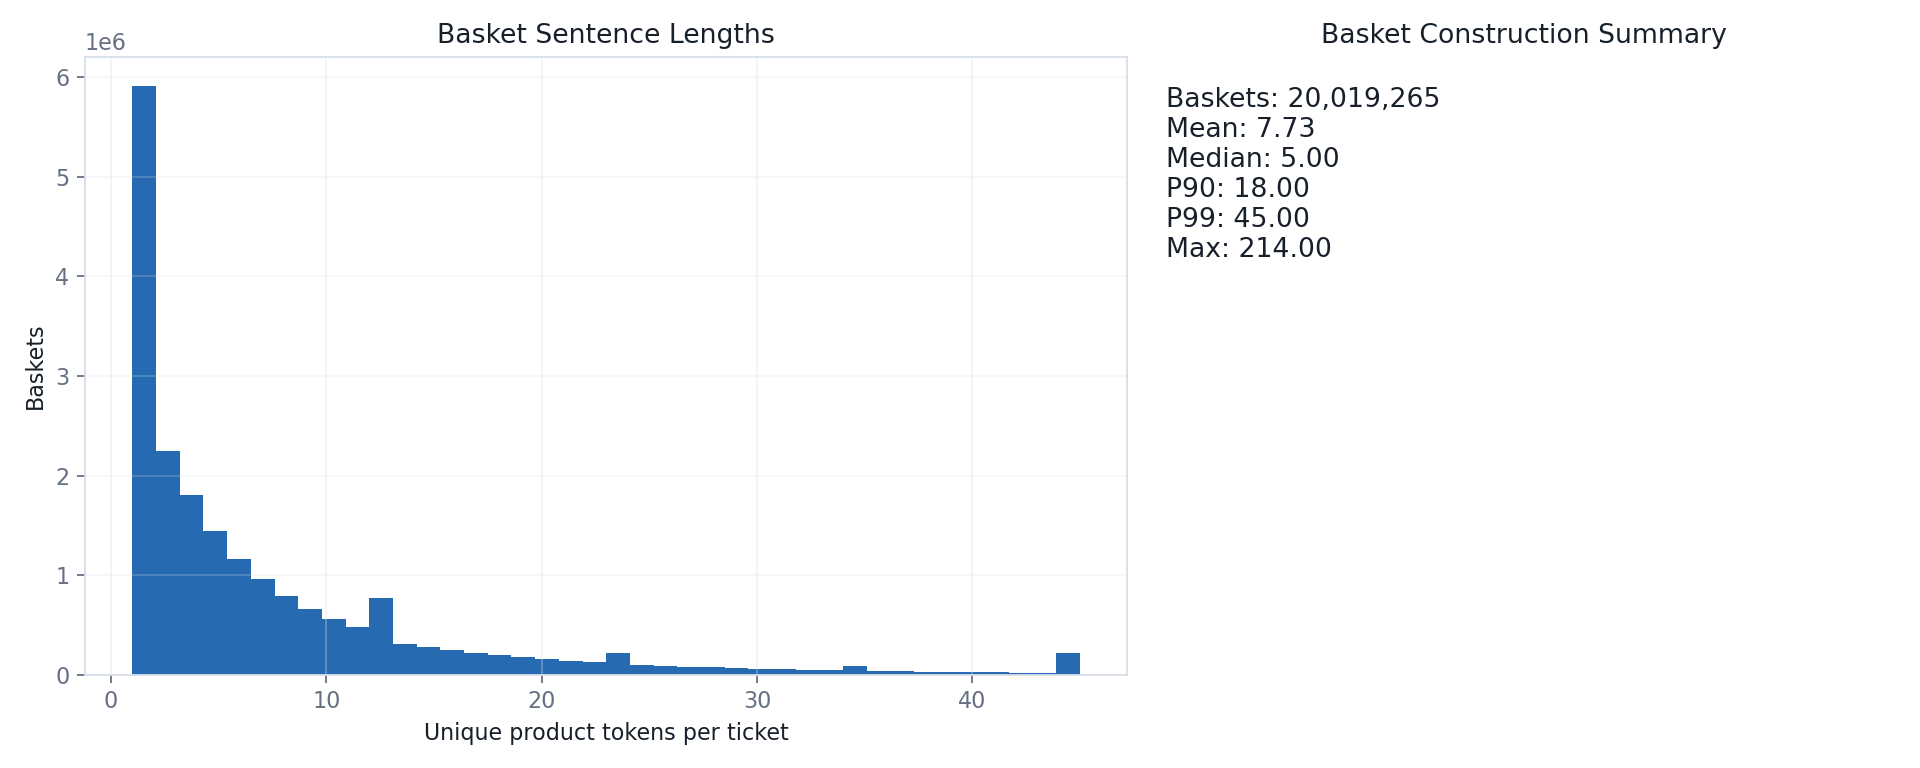

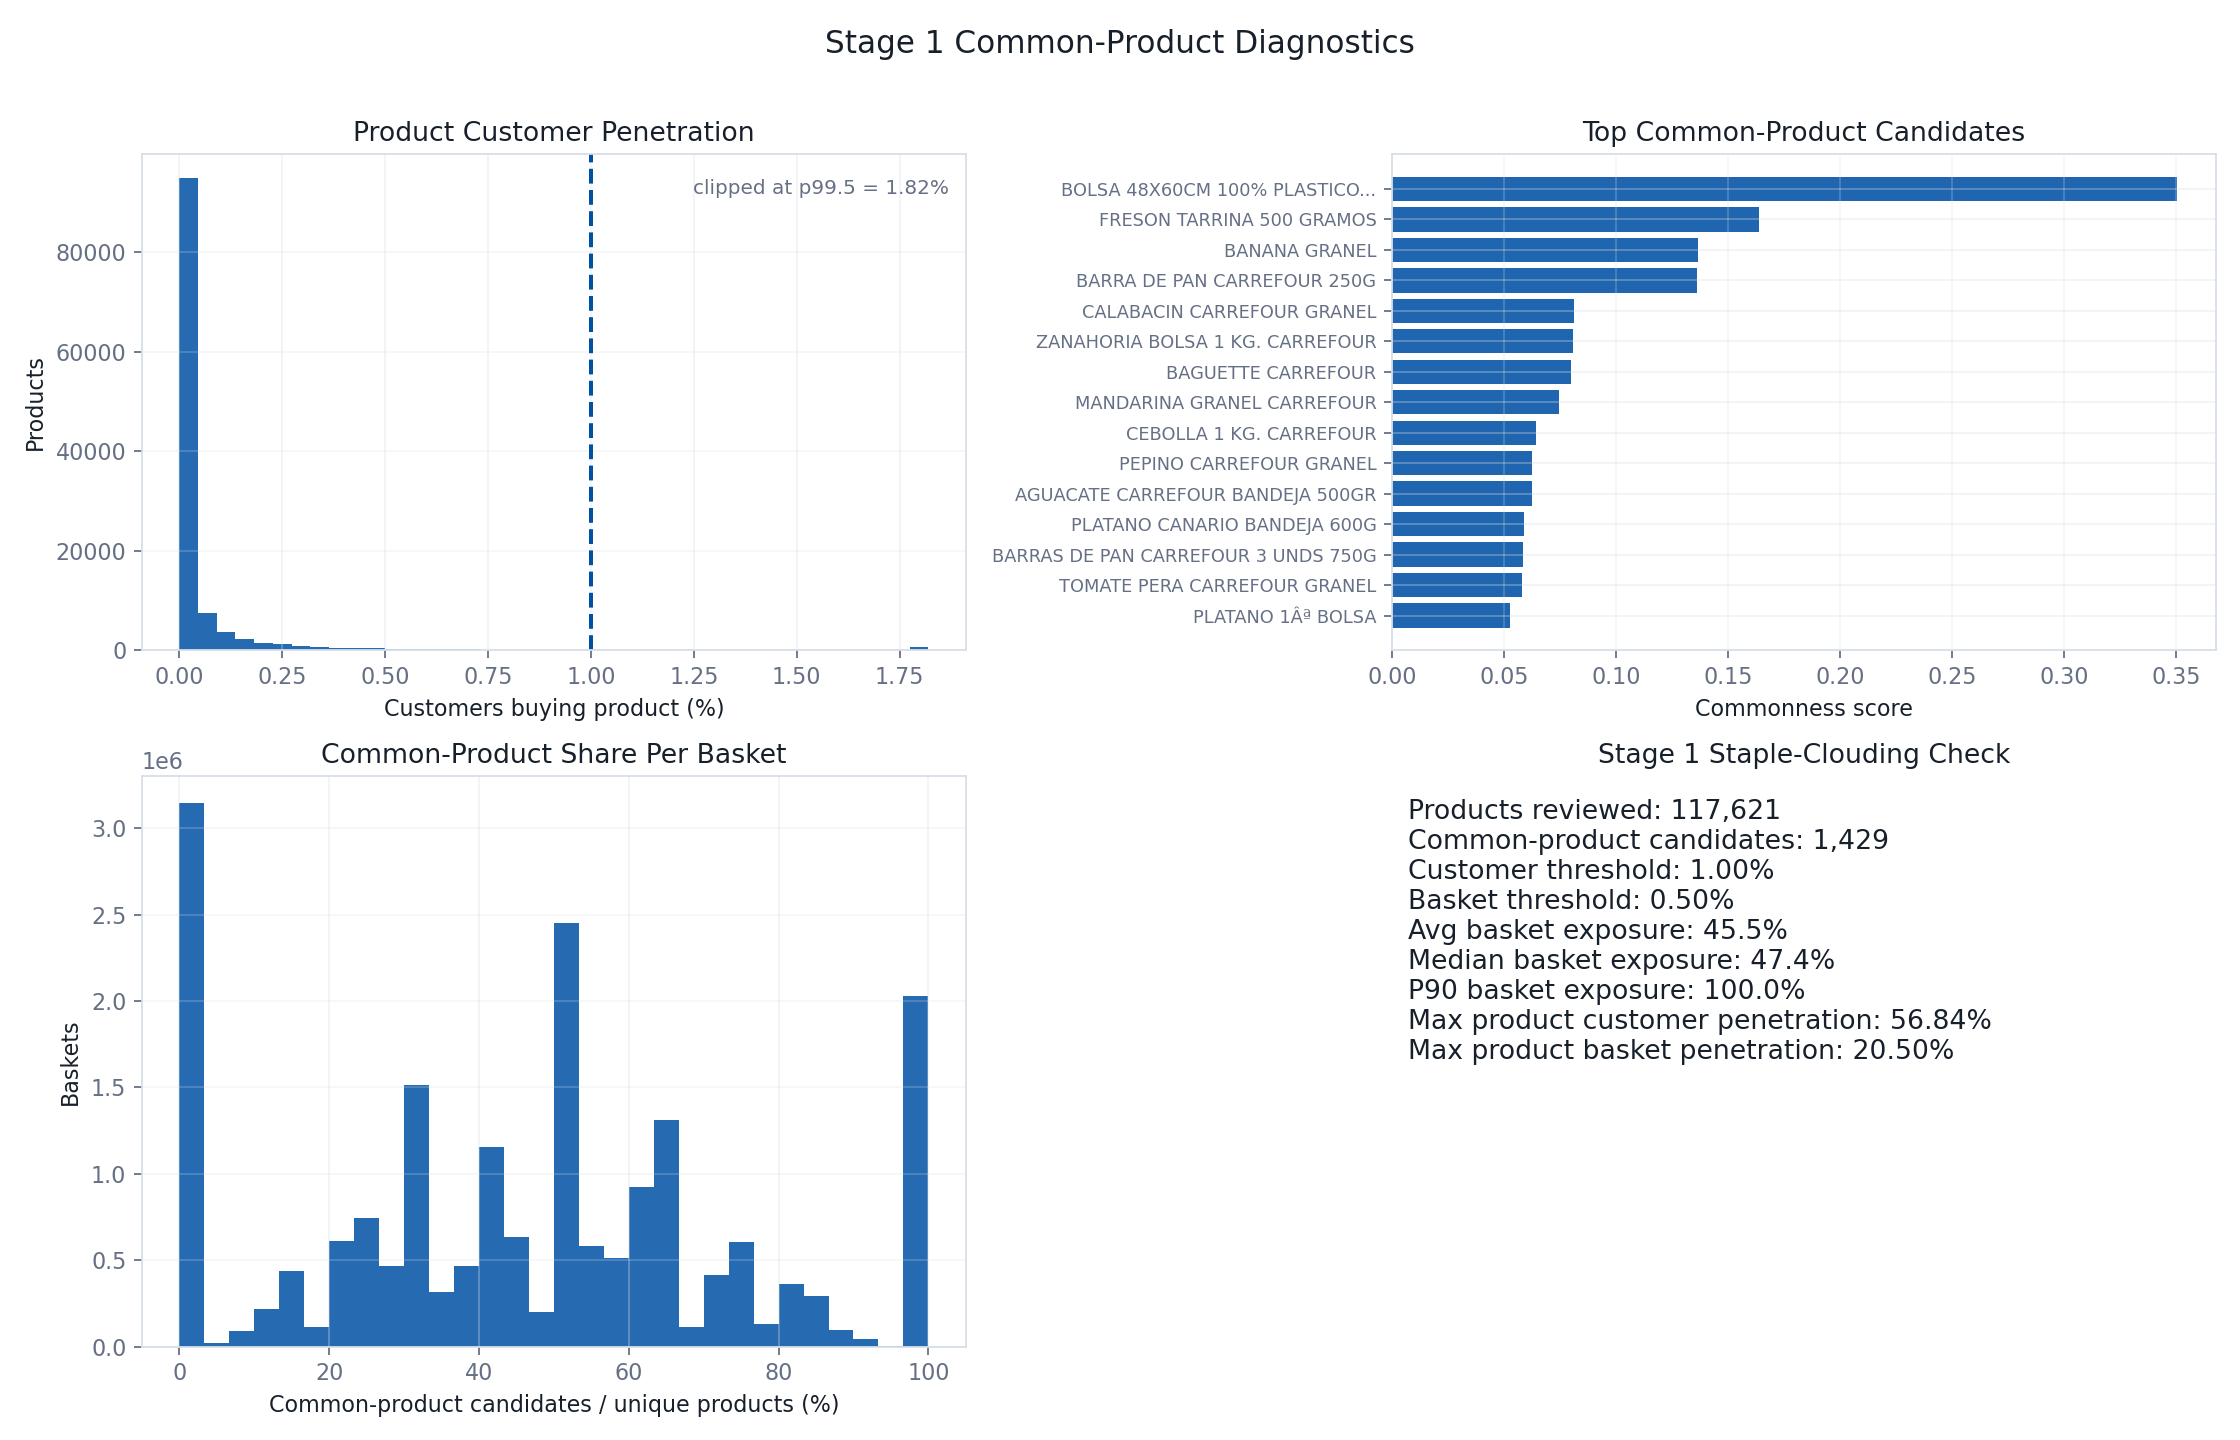

Stage 2 Item2Vec basket path: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\embeddings\basket_sentences.parquet


In [ ]:
from IPython.display import Image, display
import polars as pl

from src.basket_builder import (
    basket_summary,
    build_basket_sentences,
    build_basket_staple_diagnostics,
)
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import (
    plot_basket_staple_diagnostics,
    plot_basket_summary,
)

basket_path = build_basket_sentences(transactions=transactions, cfg=CONFIG)
stage1_basket_summary = basket_summary(basket_path)
stage1_figure = plot_basket_summary(basket_path, cfg=CONFIG)

stage1_diagnostics = build_basket_staple_diagnostics(transactions=transactions, cfg=CONFIG)
stage1_staple_figure = plot_basket_staple_diagnostics(
    stage1_diagnostics["product_diagnostics"],
    stage1_diagnostics["basket_exposure"],
    cfg=CONFIG,
)
stage1_product_diagnostics = pl.scan_parquet(stage1_diagnostics["product_diagnostics"])
stage1_common_products = stage1_product_diagnostics.filter(pl.col("common_product_candidate")).select(pl.len()).collect()[0, 0]
stage1_common_preview_rows = (
    pl.read_csv(stage1_diagnostics["common_products_csv"]).height
    if stage1_diagnostics["common_products_csv"].exists()
    else 0
)
stage1_downsampling_diag_cfg = CONFIG.get("baskets.diagnostics", {}) or {}
stage1_downsampling_plan_path = CONFIG.artifacts / str(stage1_downsampling_diag_cfg.get("output_dir", "stage1")) / str(stage1_downsampling_diag_cfg.get("downsampling_plan_output", "common_product_downsampling_plan.parquet"))
stage1_downsampling_summary_path = CONFIG.artifacts / str(stage1_downsampling_diag_cfg.get("output_dir", "stage1")) / str(stage1_downsampling_diag_cfg.get("downsampling_summary_output", "basket_downsampling_summary.csv"))
stage1_metrics = stage1_basket_summary.row(0, named=True)
stage1_metrics["common_product_candidates"] = stage1_common_products
stage1_metrics["common_product_preview_rows"] = stage1_common_preview_rows
stage1_downsampling_summary = None
if stage1_downsampling_summary_path.exists():
    stage1_downsampling_summary = pl.read_csv(stage1_downsampling_summary_path)
    stage1_metrics.update(
        stage1_downsampling_summary.select(
            [
                "basket_retention_pct",
                "unique_pair_retention_pct",
                "fallback_basket_pct",
                "auto_excluded_products",
                "downsampled_common_candidate_products",
            ]
        ).row(0, named=True)
    )
stage1_report = write_stage_report(
    "01",
    "Basket Sentences and Common-Product Exposure",
    summary=[
        "Basket sentences use product identity; active Stage 1 settings do not repeat products by unidades.",
        "Common-product exposure and downsampling retention are audited before Item2Vec training.",
    ],
    metrics=stage1_metrics,
    figures={
        "Basket token summary": stage1_figure,
        "Common-product exposure": stage1_staple_figure,
    },
    artifacts={
        "Basket sentences": basket_path,
        "Common-product candidates CSV": stage1_diagnostics["common_products_csv"],
        "Product ubiquity diagnostics": stage1_diagnostics["product_diagnostics"],
        "Downsampling plan": stage1_downsampling_plan_path if stage1_downsampling_plan_path.exists() else None,
        "Downsampling summary": stage1_downsampling_summary_path if stage1_downsampling_summary_path.exists() else None,
    },
    cfg=CONFIG,
)
display_stage_report(stage1_report)
display(stage1_basket_summary)
if stage1_downsampling_summary is not None:
    display(stage1_downsampling_summary)
display(Image(filename=str(stage1_figure)))
display(Image(filename=str(stage1_staple_figure)))
print(f"Stage 2 Item2Vec basket path: {basket_path}")


<a id="stage-2"></a>

## Stage 2: Item2Vec Product Embeddings

The Word2Vec model learns product proximity from basket co-occurrence. Products land near each other when they appear in similar baskets, without using demographics, spend, or manual labels.

The training function prints the active hyperparameters and one progress line per epoch. If a cached model already exists, it prints the cache details instead; pass `force=True` to retrain.


Item2Vec: loading cached model
  baskets: 20,019,265
  product tokens: 154,774,099; avg/basket: 7.73; median/basket: 5.00
  training baskets: 16,788,317; training tokens: 131,918,895; skipped short baskets: 3,230,948; capped baskets: 1,639,205
  model path: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\models\word2vec_product.model
  config: vector_size=128, window=20 (configured=2, full_basket_context=True), min_tokens_per_basket=2, max_tokens_per_basket=20, min_count=60, negative=10, sample=0.0001, epochs=5, sg=1, workers=5, seed=42
Item2Vec cache loaded: vocab=56,569, vector_size=128
[23:04:04] Stage 2 product embeddings: wrote training corpus diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage2\item2vec_training_corpus_diagnostics.csv
[23:04:04] Stage 2 product embeddings: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\embeddings\product_embeddings.parquet
[23:04:05] Stage 2 

# Stage 02: Product Embedding Training

- Mode: `prod`

## Status
- Item2Vec is trained on Stage 1 product-token baskets after Stage 2 corpus limits.
- Product quantities enter the official customer vectors in Stage 4, not as repeated Stage 2 tokens under the active conf...

## Key Metrics

| Metric | Value |
|---|---|
| embedded_products | 56569 |
| embedding_dimensions | 128 |
| word2vec_window | 2 |
| word2vec_min_count | 60 |
| baskets | 20019265 |
| training_baskets | 16788317 |
| skipped_short_basket_pct | 16.139 |
| capped_basket_pct | 8.188 |
| training_token_retention_pct | 85.233 |
| effective_window | 20 |

## Visual Evidence
- Product embedding diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage2_product_embedding_diagnostics.png`

## Artifacts
- Product embeddings: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\embeddings\product_embeddings.parquet`
- Training corpus diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage2\item2vec_training_corpus_diagnostics.csv`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

baskets,product_tokens,avg_tokens_per_basket,median_tokens_per_basket,max_tokens_per_basket,training_baskets,skipped_short_baskets,capped_baskets,training_product_tokens,training_basket_pct,skipped_short_basket_pct,capped_basket_pct,training_token_retention_pct,configured_window,effective_window,full_basket_context,min_tokens_per_basket,min_count,sample,negative,epochs,sg
i64,i64,f64,f64,i64,i64,i64,i64,i64,f64,f64,f64,f64,i64,i64,bool,i64,i64,f64,i64,i64,i64
20019265,154774099,7.731258,5.0,20,16788317,3230948,1639205,131918895,83.860806,16.139194,8.188138,85.233186,2,20,true,2,60,0.0001,10,5,1


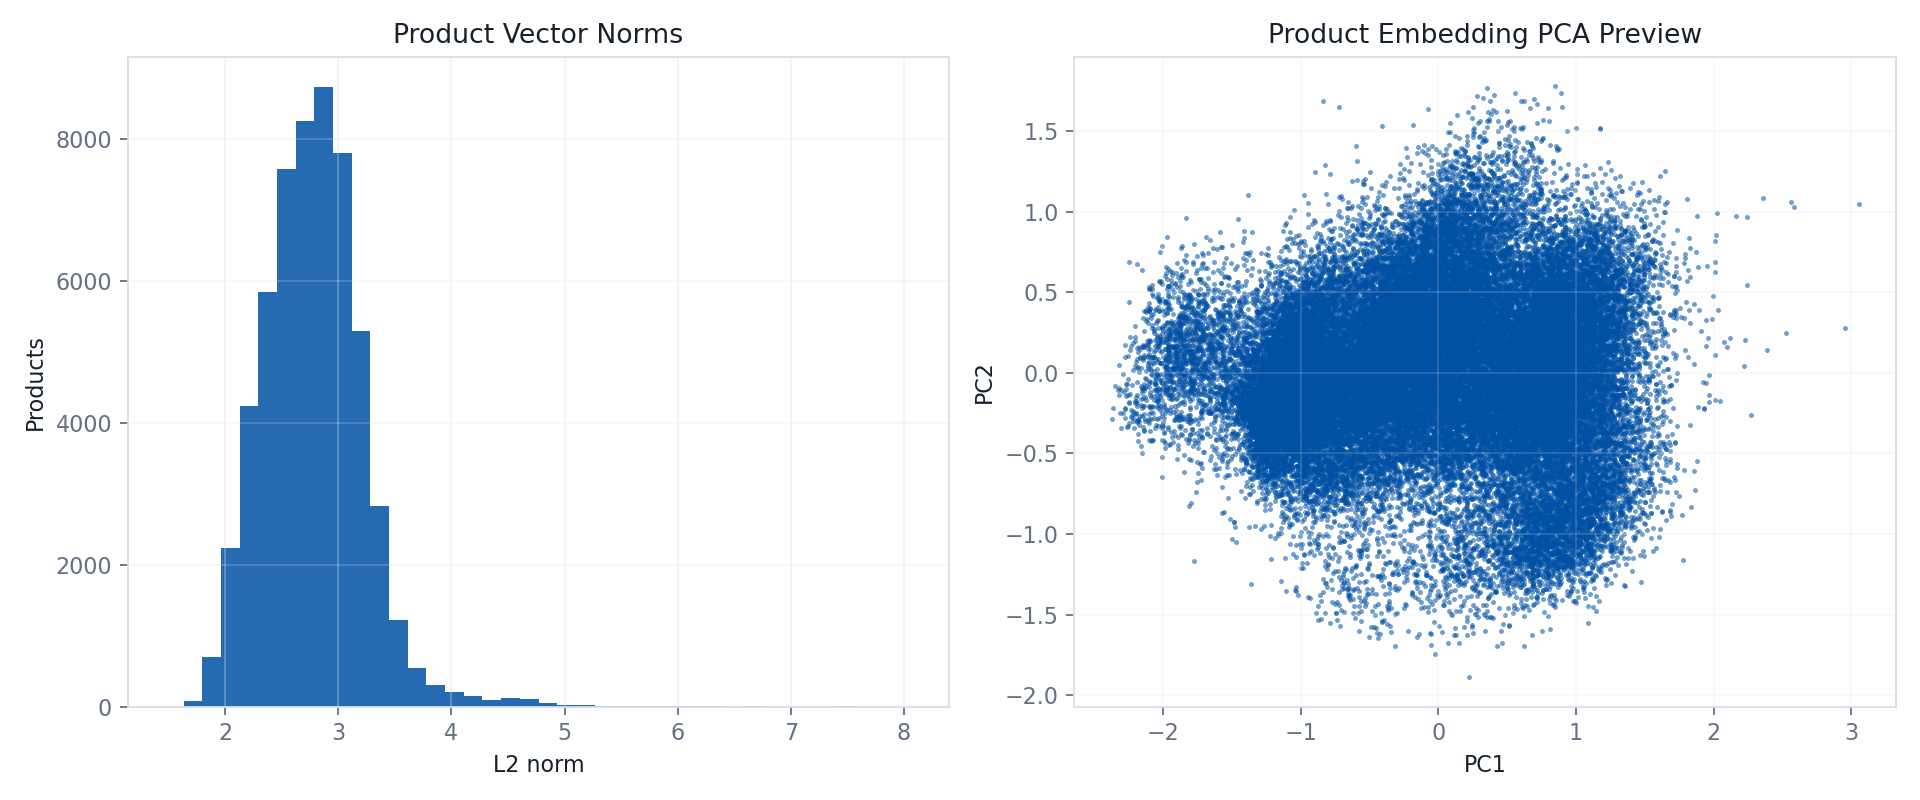

In [ ]:
from IPython.display import Image
import polars as pl

from src.item2vec import save_product_embeddings, train_item2vec, write_item2vec_training_diagnostics
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_product_embedding_diagnostics

item2vec_model = train_item2vec(basket_path, cfg=CONFIG, verbose=True)
stage2_training_diagnostics_path = write_item2vec_training_diagnostics(basket_path, cfg=CONFIG)
stage2_training_diagnostics = pl.read_csv(stage2_training_diagnostics_path)
product_embeddings_path = save_product_embeddings(item2vec_model, cfg=CONFIG)
stage2_figure = plot_product_embedding_diagnostics(product_embeddings_path, cfg=CONFIG)
stage2_schema = pl.read_parquet(product_embeddings_path, n_rows=1).columns
stage2_metrics = {
    "embedded_products": pl.scan_parquet(product_embeddings_path).select(pl.len()).collect()[0, 0],
    "embedding_dimensions": len([c for c in stage2_schema if c.startswith("emb_")]),
    "word2vec_window": CONFIG.get("word2vec.window"),
    "word2vec_min_count": CONFIG.get("word2vec.min_count"),
}
stage2_metrics.update(
    stage2_training_diagnostics.select(
        [
            "baskets",
            "training_baskets",
            "skipped_short_basket_pct",
            "capped_basket_pct",
            "training_token_retention_pct",
            "effective_window",
        ]
    ).row(0, named=True)
)
stage2_report = write_stage_report(
    "02",
    "Product Embedding Training",
    summary=[
        "Item2Vec is trained on Stage 1 product-token baskets after Stage 2 corpus limits.",
        "Product quantities enter the official customer vectors in Stage 4, not as repeated Stage 2 tokens under the active config.",
    ],
    metrics=stage2_metrics,
    figures={"Product embedding diagnostics": stage2_figure},
    artifacts={"Product embeddings": product_embeddings_path, "Training corpus diagnostics": stage2_training_diagnostics_path},
    cfg=CONFIG,
)
display_stage_report(stage2_report)
display(stage2_training_diagnostics)
display(Image(filename=str(stage2_figure)))


<a id="stage-3"></a>

## Stage 3: Product Embedding Validation

Before customer clustering, the nearest-neighbor report checks whether product embeddings capture meaningful substitutes, complements, or shared basket missions. Generic or random-looking neighbors are treated as warning signs.


[23:04:06] Stage 3 embedding validation: cache hit | csv=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage3\embedding_validation.csv, hubness=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage3\embedding_hubness.csv
[23:04:06] Stage 3 figures: wrote embedding validation summary | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage3_embedding_validation_summary.png


# Stage 03: Product Embedding Validation

- Mode: `prod`

## Status
- Guardrail status: action_needed
- Stage 3 found product-neighbor issues that should be addressed in Stage 1/2 before interpretation.
- Issues: Some high-inbound embedding hubs attract neighbors across several sectors (max cross-sector inbound share 93.9%...

## Key Metrics

| Metric | Value |
|---|---|
| validated_products | 1616 |
| guardrail_issue_count | 2 |

## Visual Evidence
- Embedding validation summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage3_embedding_validation_summary.png`

## Artifacts
- Validation CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage3\embedding_validation.csv`
- Hubness CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage3\embedding_hubness.csv`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

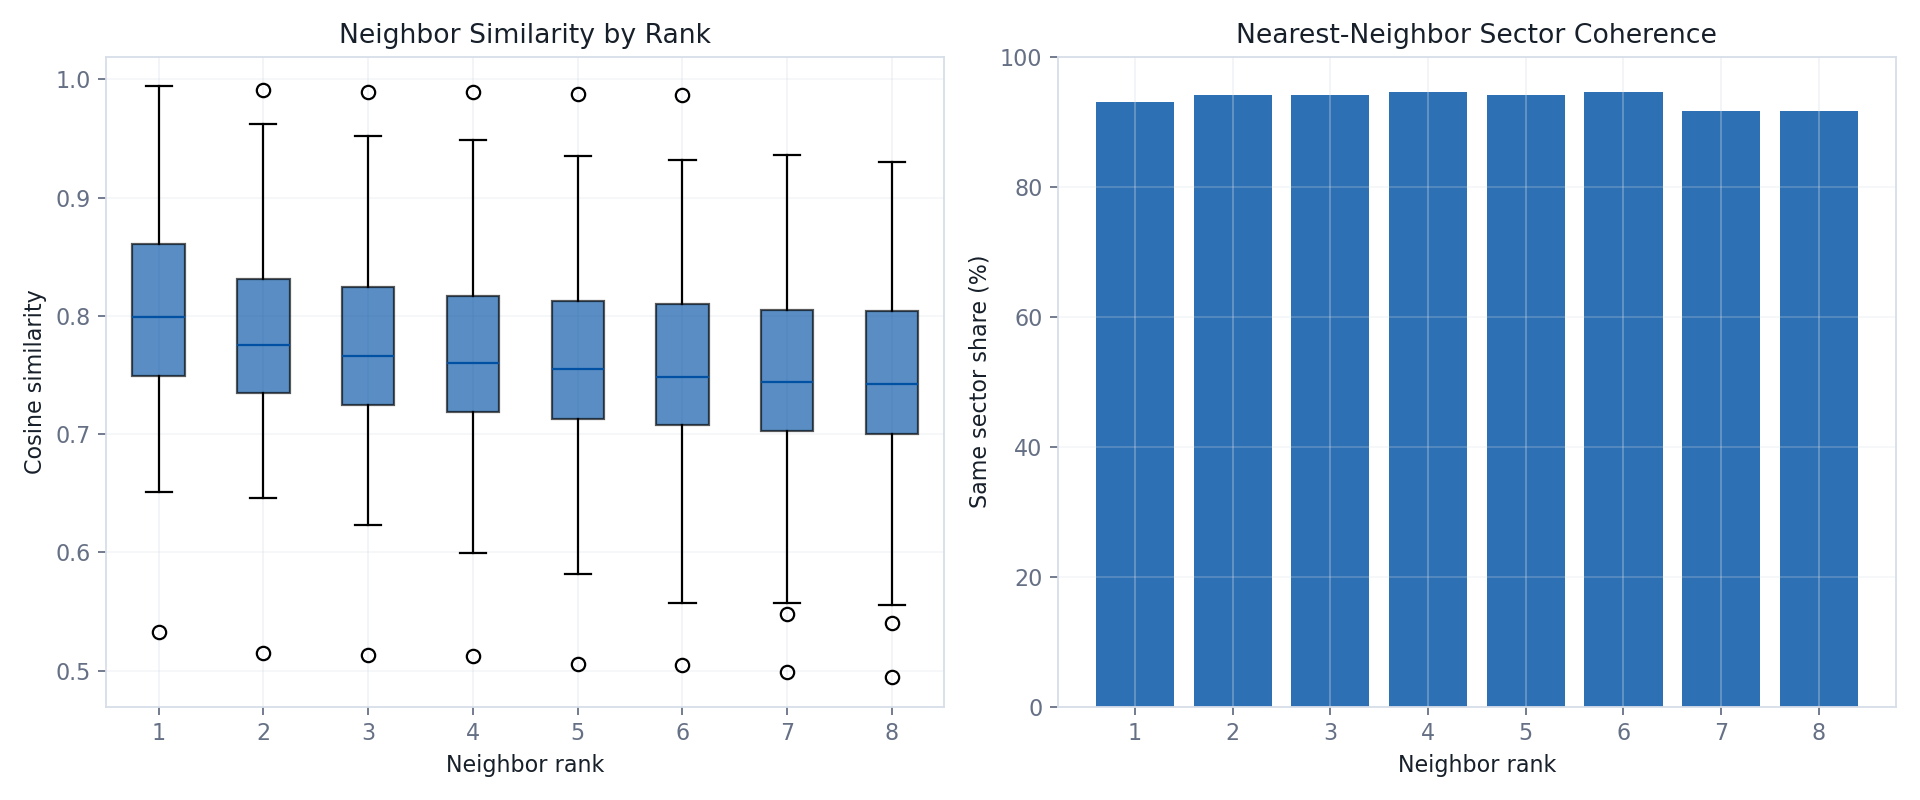

{'status': 'action_needed',
 'summary': 'Stage 3 found product-neighbor issues that should be addressed in Stage 1/2 before interpretation.',
 'issues': ['Some high-inbound embedding hubs attract neighbors across several sectors (max cross-sector inbound share 93.9%).',
  'Top hubness lift is high (73.30).'],
 'upstream_actions': ['Inspect the top hubness rows. If the hubs are sparse non-staples, raise `word2vec.min_count`; if they are true common staples, tune Stage 1 common-product exposure; if they are coherent products split by Carrefour sector taxonomy, keep as a watch item.',
  'Reduce broad co-occurrence blur upstream and rerun Stage 3; high hubness usually means a few products are absorbing too much neighborhood mass.'],
 'metrics': {'common_same_sector_share': 0.96875,
  'rare_same_sector_share': 0.88125,
  'common_rare_same_sector_gap': 0.08750000000000002,
  'generic_neighbor_warning_product_share': 0.0,
  'max_hub_cross_sector_share': 0.9393939393939394,
  'max_hubness_lift

In [ ]:
from IPython.display import Image
import polars as pl

from src.embedding_validation import product_embedding_guardrail_status, validate_product_embeddings
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_embedding_validation_quality_extracts, plot_embedding_validation_summary

embedding_validation_csv, embedding_validation_detail_md = validate_product_embeddings(
    product_embeddings_path,
    transactions=transactions,
    cfg=CONFIG,
)
stage3_figure = plot_embedding_validation_summary(embedding_validation_csv, cfg=CONFIG)
stage3_extract_figures = {}
if CONFIG.get("embedding_validation.write_extract_figures", False):
    stage3_extract_figures = plot_embedding_validation_quality_extracts(embedding_validation_csv, cfg=CONFIG)
stage3_guardrail_status = product_embedding_guardrail_status(embedding_validation_csv, cfg=CONFIG)
stage3_figures = {"Embedding validation summary": stage3_figure}
stage3_figures.update({f"Quality extract: {name}": path for name, path in stage3_extract_figures.items()})
stage3_issues = stage3_guardrail_status["issues"] or ["None"]
stage3_report = write_stage_report(
    "03",
    "Product Embedding Validation",
    summary=[
        f"Guardrail status: {stage3_guardrail_status['status']}",
        stage3_guardrail_status["summary"],
        "Issues: " + "; ".join(stage3_issues[:4]),
    ],
    metrics={
        "validated_products": pl.read_csv(embedding_validation_csv).height,
        "guardrail_issue_count": 0 if stage3_guardrail_status["issues"] is None else len(stage3_guardrail_status["issues"]),
    },
    figures=stage3_figures,
    artifacts={
        "Validation CSV": embedding_validation_csv,
        "Hubness CSV": stage3_guardrail_status["hubness_csv"],
    },
    cfg=CONFIG,
)
display_stage_report(stage3_report)
display(Image(filename=str(stage3_figure)))
for figure_path in stage3_extract_figures.values():
    display(Image(filename=str(figure_path)))
stage3_guardrail_status


<a id="stage-4"></a>

## Stage 4: Customer Embeddings

Each customer becomes one vector: a weighted average of the products they bought. Weighting uses quantity, recency decay, and repeat-basket frequency, so clustering is driven by product choice and purchase intensity rather than spend. IDF variants stay sandbox-only unless explicitly promoted in config.


[23:04:06] Stage 4 customer embeddings: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\customer_embeddings.parquet
[23:04:09] Stage 4 figures: wrote customer embedding diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage4_customer_embedding_diagnostics.png


# Stage 04: Customer Embeddings Coverage and Dominance Gates

- Mode: `prod`

## Status
- Customer vectors are weighted aggregations of purchased-product embeddings.
- Coverage gates check how much transaction signal survives product embedding coverage.
- Dominance gates check whether common products overwhelm customer vectors.

## Key Metrics

| Metric | Value |
|---|---|
| embedded_customers | 1478831 |
| weight_strategy | quantity_idf |
| quantity_transform | log1p |
| common_product_weight_share_pct | 36.613 |
| mean_customer_common_product_weight_share_pct | 33.081 |
| p95_customer_common_product_weight_share_pct | 64.699 |
| top_product_weight_share_pct | 0.8109 |
| top_10_product_weight_share_pct | 2.863 |
| mean_customer_top_product_weight_share_pct | 15.691 |
| stage4_gate_status | pass |
| stage4_gate_issues | None |
| recency_weighting_enabled | True |
| recency_reference_date | 2022-06-30 |
| recency_half_life_days | 180 |
| mean_recency_multiplier | 0.7223 |
| frequency_weighting_enabled | True |
| frequency_transform | log1p |
| mean_frequency_multiplier | 1.087 |
| p95_customer_product_basket_count | 4 |
| line_coverage_pct | 97.316 |
| unit_coverage_pct | 97.711 |
| product_coverage_pct | 48.094 |
| customer_coverage_pct | 99.738 |
| zero_embedded_customer_pct | 0.262 |

## Visual Evidence
- Customer embedding diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage4_customer_embedding_diagnostics.png`

## Artifacts
- Customer embeddings: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\customer_embeddings.parquet`
- Weight diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage4\customer_embedding_weight_diagnostics.csv`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

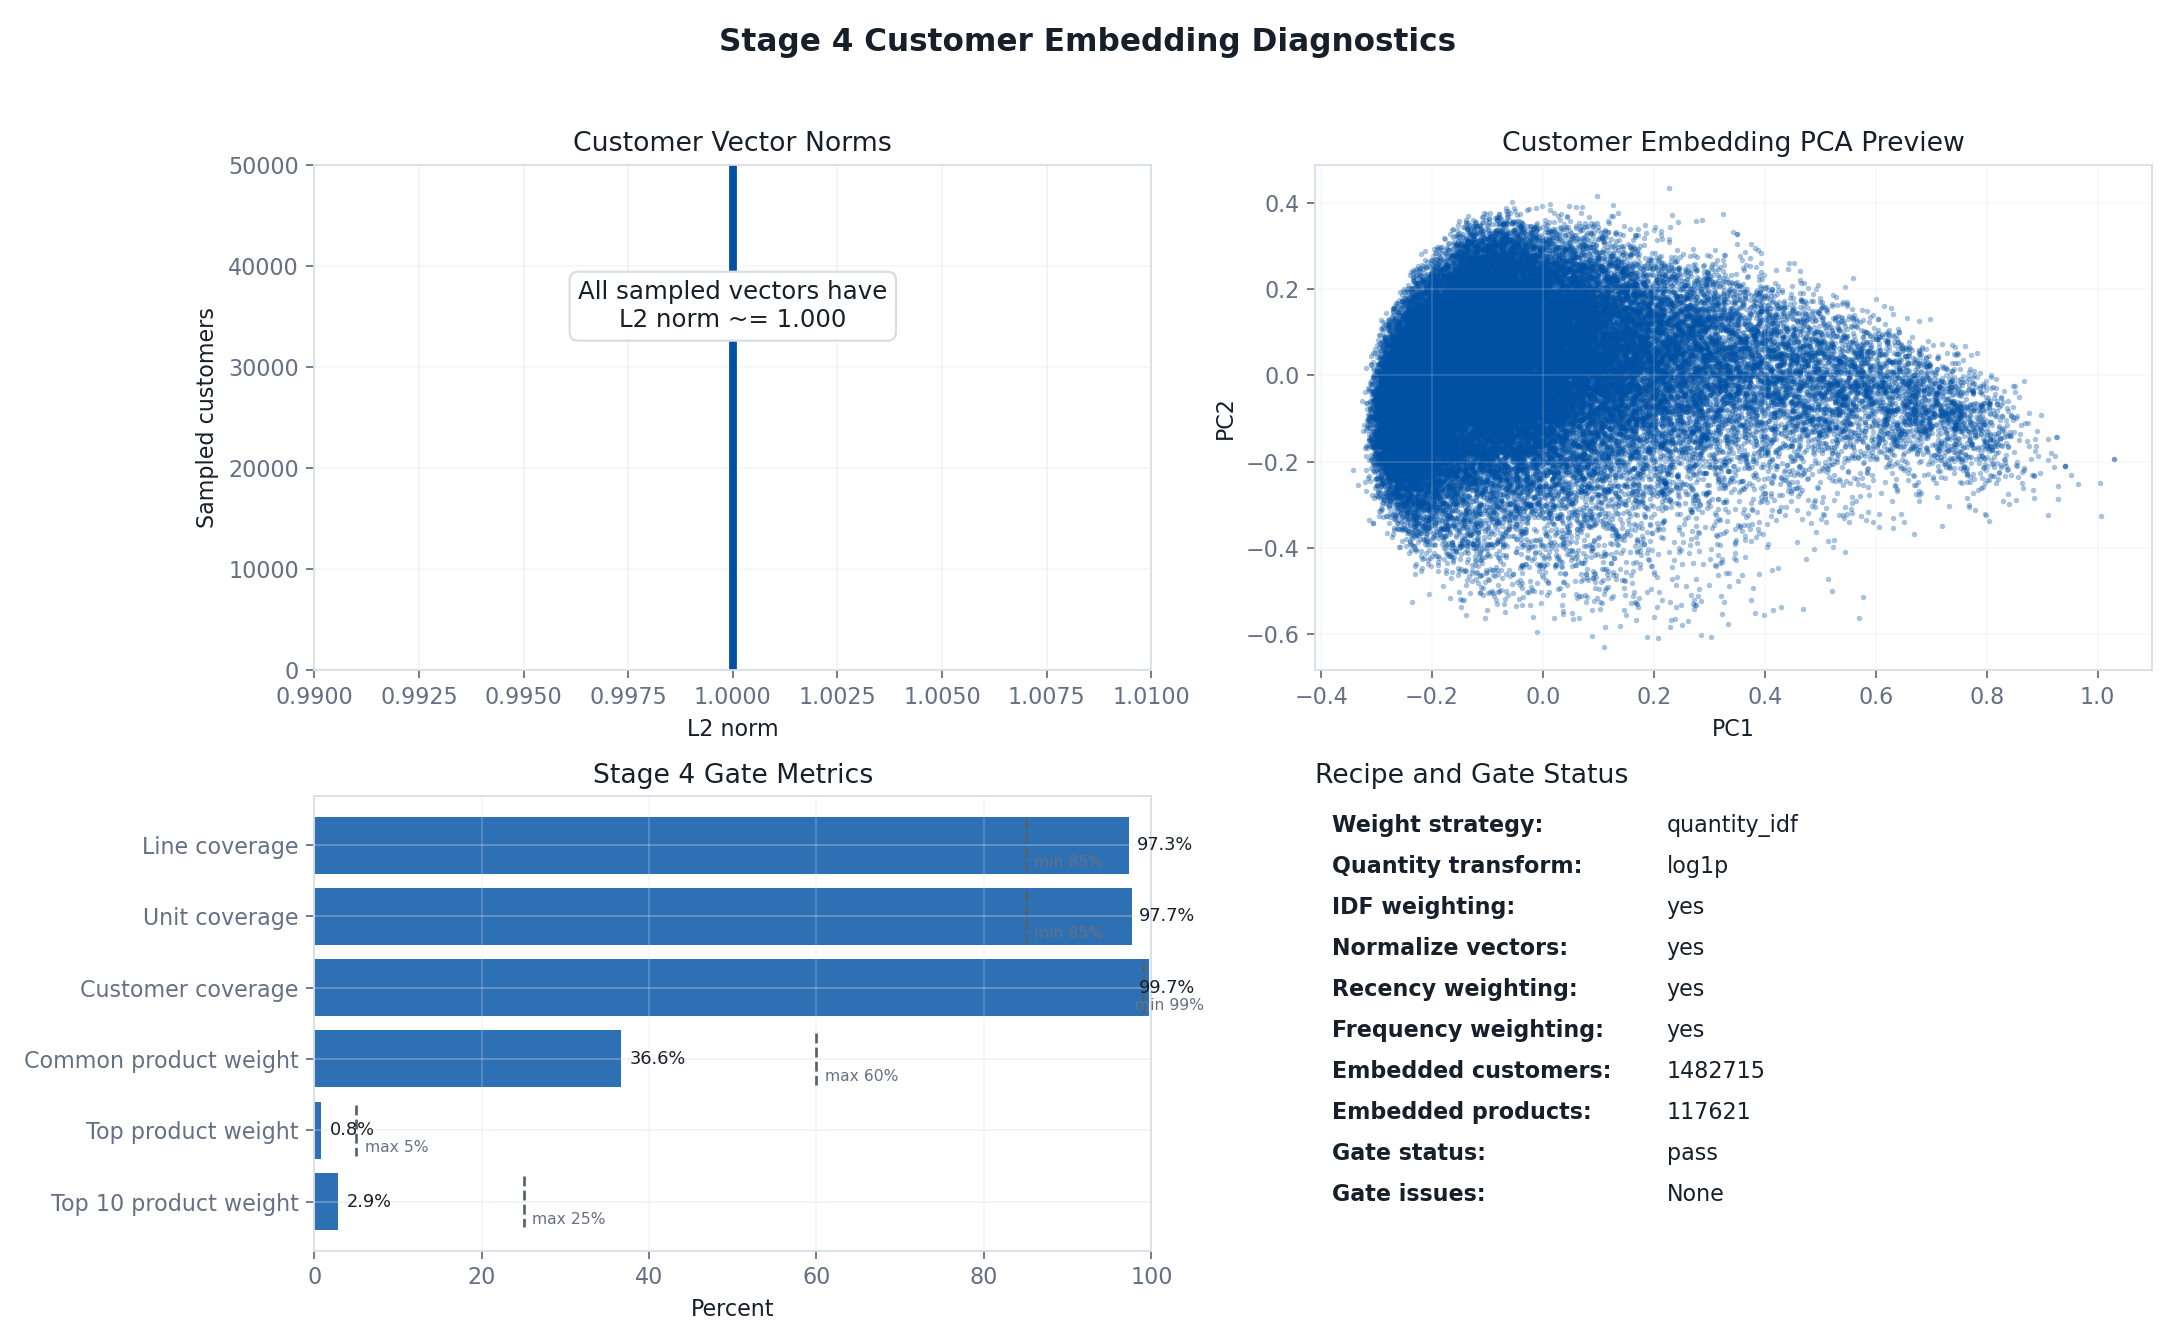

weight_strategy,quantity_transform,common_product_weight_share_pct,mean_customer_common_product_weight_share_pct,p95_customer_common_product_weight_share_pct,top_product_weight_share_pct,top_10_product_weight_share_pct,mean_customer_top_product_weight_share_pct,stage4_gate_status,stage4_gate_issues,recency_weighting_enabled,recency_reference_date,recency_half_life_days,mean_recency_multiplier,frequency_weighting_enabled,frequency_transform,mean_frequency_multiplier,p95_customer_product_basket_count,line_coverage_pct,unit_coverage_pct,product_coverage_pct,customer_coverage_pct,zero_embedded_customer_pct
str,str,f64,f64,f64,f64,f64,f64,str,str,bool,str,f64,f64,bool,str,f64,f64,f64,f64,f64,f64,f64
"""quantity_idf""","""log1p""",36.613475,33.081437,64.699324,0.810915,2.863453,15.691146,"""pass""","""None""",true,"""2022-06-30""",180.0,0.722256,true,"""log1p""",1.08749,4.0,97.316036,97.710791,48.094303,99.738048,0.261952


In [ ]:
from IPython.display import Image, display
import polars as pl

from src.customer_embeddings import build_customer_embeddings
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_customer_embedding_diagnostics

customer_embeddings_path = build_customer_embeddings(
    product_embeddings_path,
    transactions=transactions,
    normalize_vectors=CONFIG.get("customer_embeddings.normalize_vectors", False),
    cfg=CONFIG,
)
stage4_figure = plot_customer_embedding_diagnostics(customer_embeddings_path, cfg=CONFIG)

stage4_diag_cfg = CONFIG.get("customer_embeddings.diagnostics", {}) or {}
stage4_weight_summary_path = (
    CONFIG.artifacts
    / str(stage4_diag_cfg.get("output_dir", "stage4"))
    / f"{stage4_diag_cfg.get('output_prefix', 'customer_embedding')}_weight_diagnostics.csv"
)
stage4_display_cols = [
    "weight_strategy",
    "quantity_transform",
    "common_product_weight_share_pct",
    "mean_customer_common_product_weight_share_pct",
    "p95_customer_common_product_weight_share_pct",
    "top_product_weight_share_pct",
    "top_10_product_weight_share_pct",
    "mean_customer_top_product_weight_share_pct",
    "stage4_gate_status",
    "stage4_gate_issues",
    "recency_weighting_enabled",
    "recency_reference_date",
    "recency_half_life_days",
    "mean_recency_multiplier",
    "frequency_weighting_enabled",
    "frequency_transform",
    "mean_frequency_multiplier",
    "p95_customer_product_basket_count",
    "line_coverage_pct",
    "unit_coverage_pct",
    "product_coverage_pct",
    "customer_coverage_pct",
    "zero_embedded_customer_pct",
]
stage4_weight_summary = None
stage4_report_metrics = {
    "embedded_customers": pl.scan_parquet(customer_embeddings_path).select(pl.len()).collect()[0, 0]
}
if stage4_weight_summary_path.exists():
    stage4_weight_summary = pl.read_csv(stage4_weight_summary_path)
    available_stage4_cols = [c for c in stage4_display_cols if c in stage4_weight_summary.columns]
    if available_stage4_cols:
        stage4_report_metrics.update(stage4_weight_summary.select(available_stage4_cols).row(0, named=True))
stage4_report = write_stage_report(
    "04",
    "Customer Embeddings Coverage and Dominance Gates",
    summary=[
        "Customer vectors are weighted aggregations of purchased-product embeddings.",
        "Coverage gates check how much transaction signal survives product embedding coverage.",
        "Dominance gates check whether common products overwhelm customer vectors.",
    ],
    metrics=stage4_report_metrics,
    figures={"Customer embedding diagnostics": stage4_figure},
    artifacts={
        "Customer embeddings": customer_embeddings_path,
        "Weight diagnostics": stage4_weight_summary_path if stage4_weight_summary_path.exists() else None,
    },
    cfg=CONFIG,
    max_metric_rows=32,
)
display_stage_report(stage4_report)
display(Image(filename=str(stage4_figure)))
if stage4_weight_summary is not None:
    display(stage4_weight_summary.select([c for c in stage4_display_cols if c in stage4_weight_summary.columns]))


<a id="stage-5"></a>

## Stage 5: Official Feature Set

This stage locks the official clustering input. Behavioral features and spend KPIs are saved separately for profiling, but they do not enter the clustering feature set. The modeling boundary is product/quantity customer embeddings only.


[23:04:09] Stage 5 behavior: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\customer_behavior_features.parquet
[23:04:09] Stage 5 feature set: cache hit | variant=embeddings_only, path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\feature_set_embeddings_only.parquet
[23:04:11] Stage 5 figures: wrote behavioral feature summary | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage5_behavioral_feature_summary.png
[23:04:13] Stage 5 figures: wrote feature-set summary | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage5_feature_set_summary.png
[23:04:21] Stage 5 diagnostics: wrote feature-set diagnostics | rows=1, path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage5\feature_set_diagnostics.csv


# Stage 05: Official Product/Quantity Feature Set

- Mode: `prod`

## Status
- Official tribe selection uses embeddings_only to keep clustering product-first.
- Behavioral features are prepared separately for post-clustering interpretation.
- Product-exposure challenger features are opt-in and skipped by default to keep prod runs lean.

## Key Metrics

| Metric | Value |
|---|---|
| feature_sets_built | 1 |
| selection_feature_set | embeddings_only |
| feature_diagnostics_rows | 1 |
| product_exposure_challenger_enabled | False |

## Visual Evidence
- Behavioral feature summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage5_behavioral_feature_summary.png`
- Feature set summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage5_feature_set_summary.png`

## Artifacts
- Behavioral features: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\customer_behavior_features.parquet`
- Feature diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage5\feature_set_diagnostics.csv`
- embeddings_only: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\feature_set_embeddings_only.parquet`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

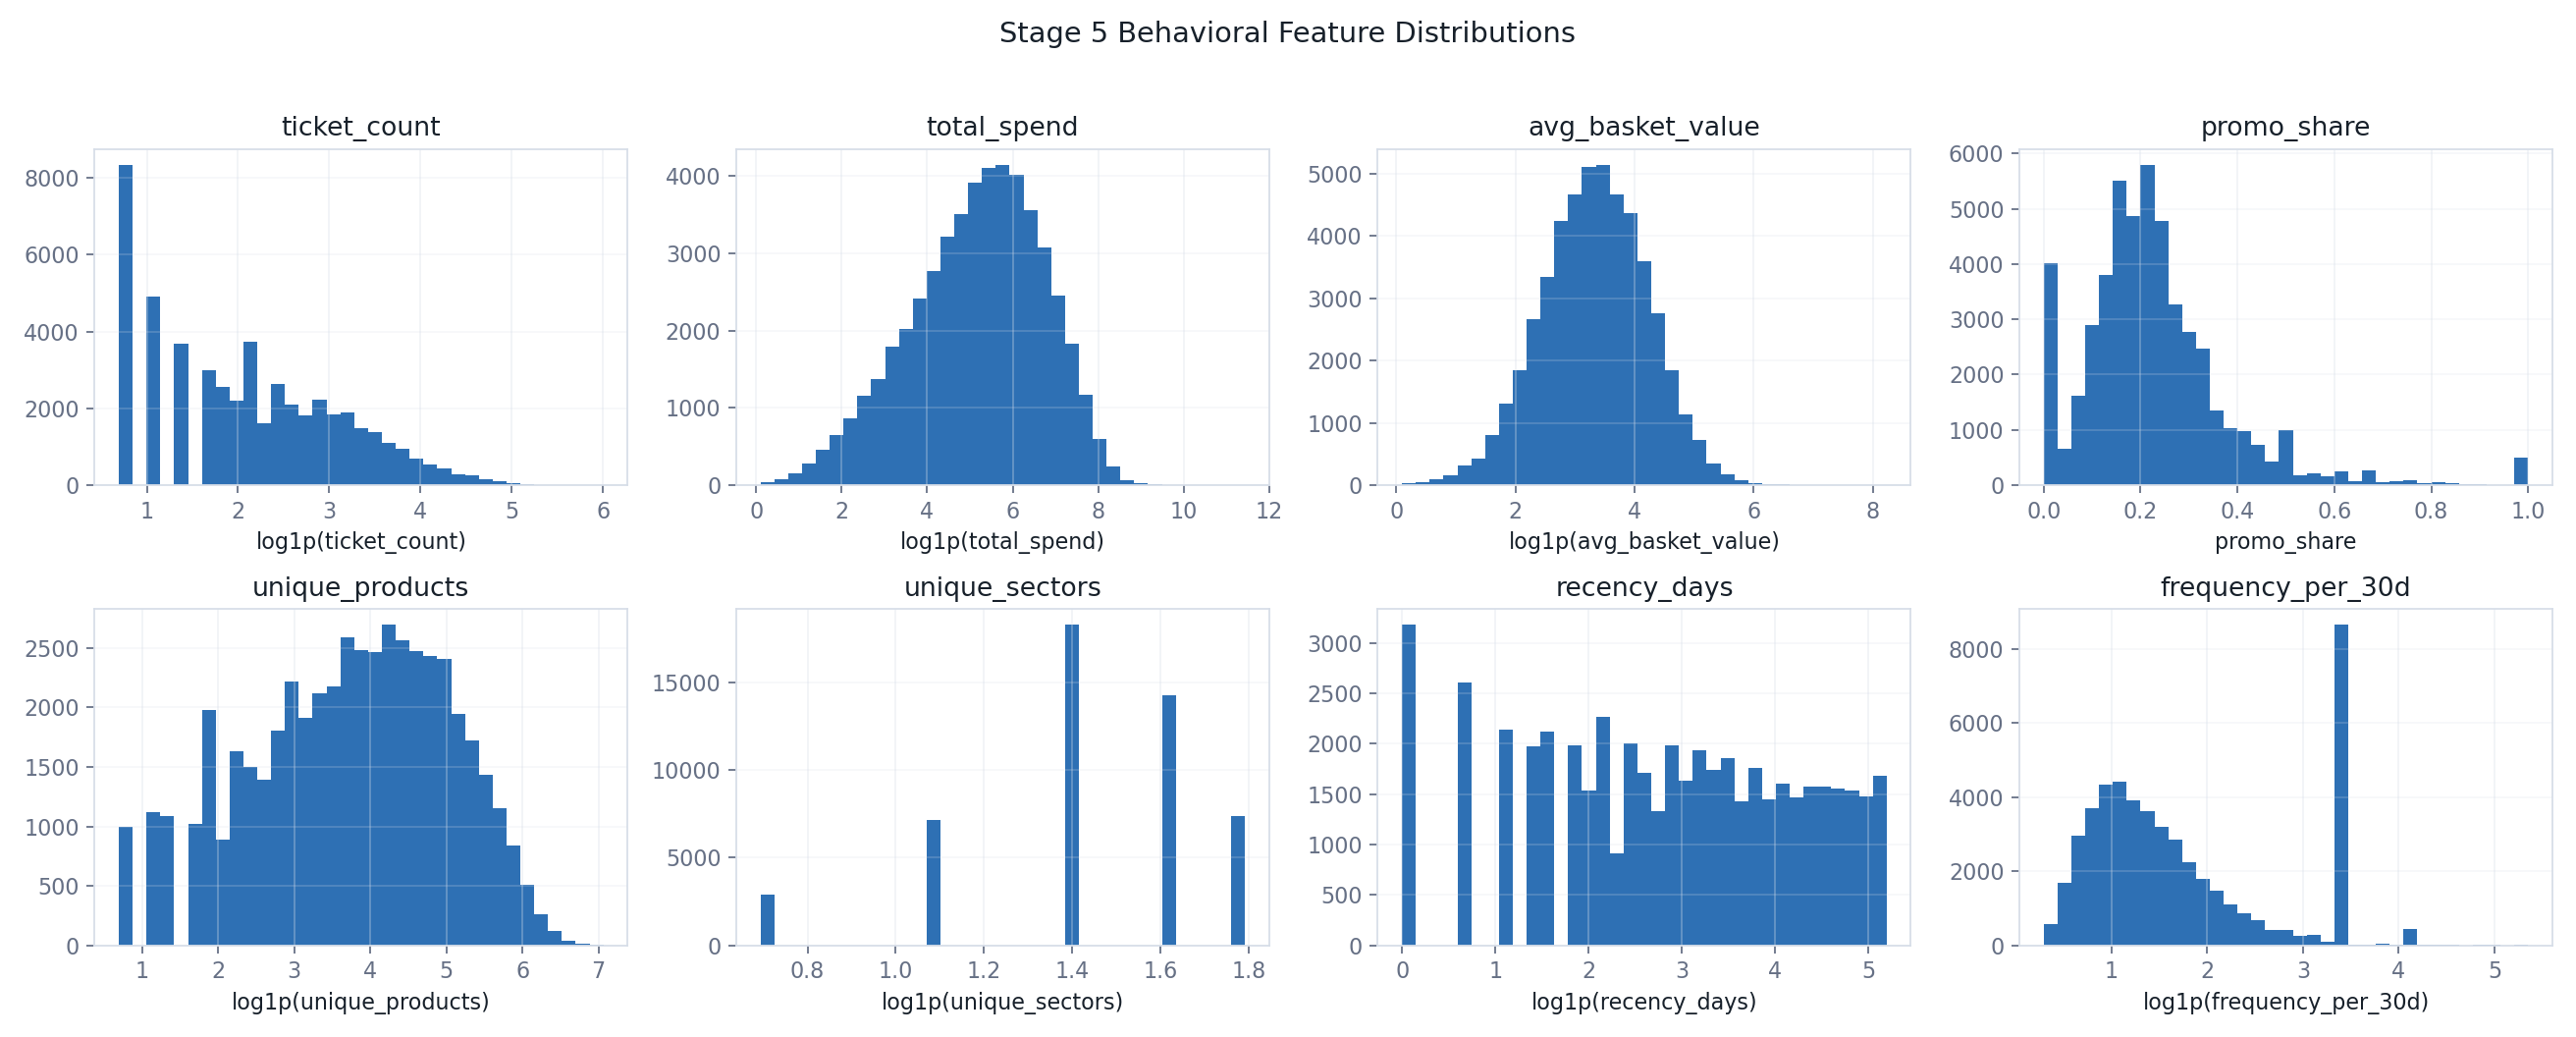

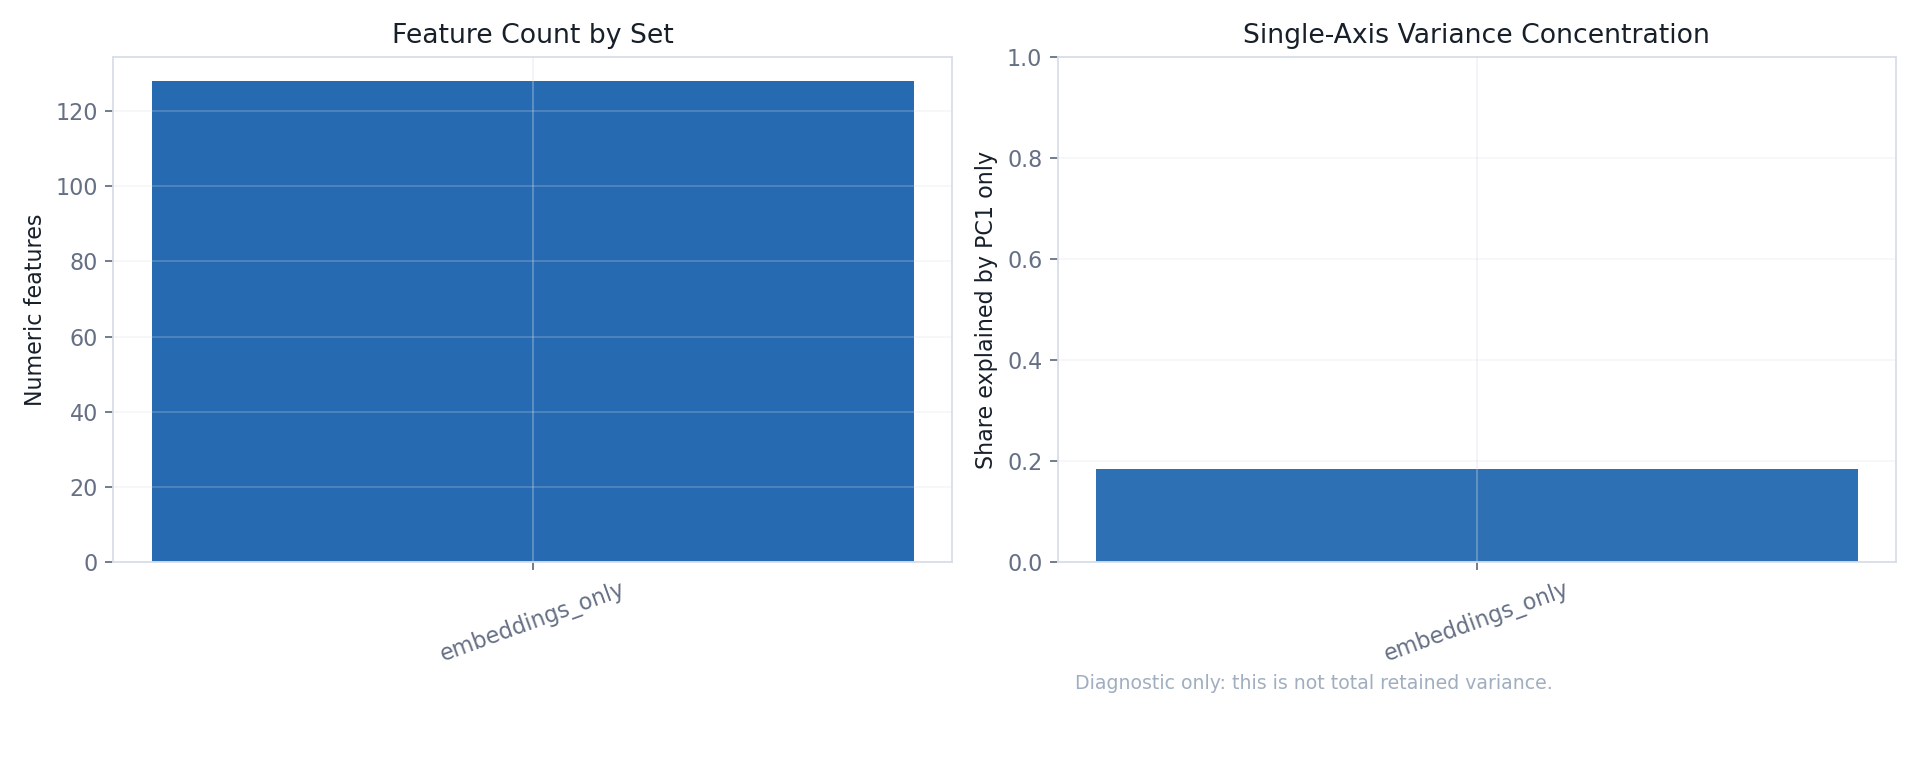

feature_set_name,is_selection_feature_set,rows,feature_count,finite_pct,null_pct,zero_variance_feature_count,customer_alignment_status,missing_vs_baseline_customers,extra_vs_baseline_customers,neighbor_overlap_vs_baseline_pct,selection_warning
str,bool,i64,i64,f64,f64,i64,str,i64,i64,f64,str
"""embeddings_only""",true,1478831,128,100.0,0.0,0,"""pass""",0,0,100.0,"""OK: official selection uses pr…"


In [ ]:
from IPython.display import Image
import polars as pl

from src.feature_engineering import build_behavioral_features, build_feature_set, build_feature_set_diagnostics, build_product_exposure_features
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_behavioral_feature_summary, plot_feature_set_summary

behavior_path = build_behavioral_features(transactions=transactions, cfg=CONFIG)
selection_feature_set = CONFIG.get("modeling.feature_set_for_selection", "embeddings_only")
build_product_exposure_challenger = bool(CONFIG.get("product_exposure_features.enabled", False)) or selection_feature_set == "embeddings_product_exposure"
product_exposure_path = None
embeddings_only_feature_set = build_feature_set(customer_embeddings_path, variant="embeddings_only", cfg=CONFIG)
feature_sets = {"embeddings_only": embeddings_only_feature_set}
if build_product_exposure_challenger:
    product_exposure_path = build_product_exposure_features(transactions=transactions, cfg=CONFIG)
    feature_sets["embeddings_product_exposure"] = build_feature_set(
        customer_embeddings_path,
        product_exposure_path=product_exposure_path,
        variant="embeddings_product_exposure",
        cfg=CONFIG,
    )
stage5_behavior_figure = plot_behavioral_feature_summary(behavior_path, cfg=CONFIG)
stage5_feature_set_figure = plot_feature_set_summary(feature_sets, cfg=CONFIG)
stage5_feature_diagnostics_path = build_feature_set_diagnostics(feature_sets, cfg=CONFIG)
stage5_feature_diagnostics = pl.read_csv(stage5_feature_diagnostics_path)
stage5_diagnostic_display_cols = [
    "feature_set_name",
    "is_selection_feature_set",
    "rows",
    "feature_count",
    "finite_pct",
    "null_pct",
    "zero_variance_feature_count",
    "customer_alignment_status",
    "missing_vs_baseline_customers",
    "extra_vs_baseline_customers",
    "neighbor_overlap_vs_baseline_pct",
    "selection_warning",
]
stage5_report = write_stage_report(
    "05",
    "Official Product/Quantity Feature Set",
    summary=[
        "Official tribe selection uses embeddings_only to keep clustering product-first.",
        "Behavioral features are prepared separately for post-clustering interpretation.",
        "Product-exposure challenger features are opt-in and skipped by default to keep prod runs lean.",
    ],
    metrics={
        "feature_sets_built": len(feature_sets),
        "selection_feature_set": CONFIG.get("modeling.feature_set_for_selection", "embeddings_only"),
        "feature_diagnostics_rows": stage5_feature_diagnostics.height,
        "product_exposure_challenger_enabled": build_product_exposure_challenger,
    },
    figures={
        "Behavioral feature summary": stage5_behavior_figure,
        "Feature set summary": stage5_feature_set_figure,
    },
    artifacts={
        **{"Behavioral features": behavior_path, "Feature diagnostics": stage5_feature_diagnostics_path},
        **({"Product exposure features": product_exposure_path} if product_exposure_path is not None else {}),
        **feature_sets,
    },
    cfg=CONFIG,
)
display_stage_report(stage5_report)
display(Image(filename=str(stage5_behavior_figure)))
display(Image(filename=str(stage5_feature_set_figure)))
display(stage5_feature_diagnostics.select([c for c in stage5_diagnostic_display_cols if c in stage5_feature_diagnostics.columns]))


<a id="stage-6"></a>

## Stage 6: Hard Three-Stage UMAP-HDBSCAN Core Tribe Discovery

This is the official organic-tribe discovery step. It uses the product/quantity customer feature set, builds a UMAP representation, then runs hard HDBSCAN in three visible passes. "Hard" means a customer either belongs to a core tribe or remains `-1` noise; official membership is not forced.

- Stage 6.1 builds the UMAP customer manifold from `embeddings_only`.
- Stage 6.2 runs the first hard HDBSCAN pass on the full UMAP representation.
- Stage 6.3 runs a stricter second hard HDBSCAN pass only on first-pass noise.
- Stage 6.4 runs a third hard HDBSCAN pass over customers still unassigned after the first two passes.
- Stage 6.5 merges all three hard HDBSCAN passes and keeps only clusters with strong product-lift evidence.
- Stage 6.6 writes quality, stability, readiness, and promotion-blocker evidence before Stage 7 interpretation.
- Stage 6.7 segments customers still unassigned after the official hard merge and writes soft-affinity evidence for later campaign-use opportunities.
- Stage 6.8 assembles all raw transaction and behavioral evidence into cached tribe evidence artifacts for Stage 7.

UMAP is treated as a clustering representation, not automatic proof. The tribe claim is credible only when density evidence, product-lift evidence, stability/readiness, remaining-customer review, and Stage 7 interpretation all tell a coherent story.


In [ ]:
import polars as pl
from IPython.display import Image, Markdown, display

from src.model_selection import (
    build_candidate_model_diagnostics,
    build_official_umap_core_representation,
    build_stage6_hdbscan_diagnostics,
    build_stage6_representation_cluster_diagnostics,
    build_stage6_umap_diagnostics,
    merge_official_three_stage_hdbscan_lift_core,
    model_suite_from_single_candidate,
    run_official_three_stage_hdbscan_first_pass,
    run_official_three_stage_hdbscan_second_pass,
    run_official_three_stage_hdbscan_third_pass,
)
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import (
    plot_stage6_hdbscan_assignment_map,
    plot_stage6_quality_evidence,
    plot_stage6_umap_representation,
)

selection_feature_set = CONFIG.get("modeling.feature_set_for_selection", "embeddings_only")
if "feature_sets" not in globals():
    feature_set_outputs = CONFIG.get("feature_sets.outputs", {})
    selection_feature_filename = feature_set_outputs.get(selection_feature_set, f"feature_set_{selection_feature_set}.parquet")
    feature_sets = {
        selection_feature_set: CONFIG.outputs / "features" / selection_feature_filename,
    }
    missing_feature_sets = [path for path in feature_sets.values() if not path.exists()]
    if missing_feature_sets:
        raise FileNotFoundError(
            "Stage 6 needs the Stage 5 feature-set parquet files. "
            f"Missing: {missing_feature_sets}. Run Stage 5 first."
        )

allowed_product_feature_sets = {"embeddings_only", "embeddings_product_exposure"}
if selection_feature_set not in allowed_product_feature_sets:
    raise ValueError(
        "Official Stage 6 core tribe discovery only allows product-derived feature sets: "
        f"{sorted(allowed_product_feature_sets)}. Do not use behavior, spend, or demographic feature sets here."
    )
stage6_feature_path = feature_sets[selection_feature_set]
stage6_feature_path


WindowsPath('C:/Users/rothl/Desktop/IE Capstone/carrefour_capstone/outputs/prod/features/feature_set_embeddings_only.parquet')

### Stage 6.1: UMAP Representation Check

Build the PCA-to-UMAP customer manifold used for density clustering. PCA reduces noise before UMAP; the checks verify row alignment, dimensions, nulls, finite values, and basic neighborhood quality before HDBSCAN runs.


[23:04:21] Stage 6.1 UMAP: building product-only customer manifold | trial=u20_n75_leaf_mcs3000_ms6_core, pca_components=64, components=20, n_neighbors=75
[23:04:21] Stage 6 PCA: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\feature_set_pca_for_umap.parquet, summary=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_1_pca_for_umap_summary.csv
[23:04:42] Stage 6 UMAP: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\feature_set_umap_pca64_u20_n75.parquet
[23:04:44] Stage 6.1 checks: wrote UMAP representation diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_1_umap_checks.csv
[23:04:44] Stage 6.1 figures: wrote UMAP representation preview | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage6_1_umap_representation.png


purpose,dimension_reduction,requested_component_count,retained_component_count,retained_variance_pct,pc1_variance_pct,pc5_cumulative_variance_pct,pc10_cumulative_variance_pct
str,str,i64,i64,f64,f64,f64,f64
"""Pre-reduce standardized custom…","""128 -> 64""",64,64,86.86,14.42,37.17,50.13


stage,check_status,check_issues,feature_path,umap_path,source_rows,umap_rows,missing_feature_customers,extra_umap_customers,duplicate_umap_customers,source_feature_count,umap_component_count,requested_umap_components,umap_n_neighbors,umap_metric,umap_min_dist,finite_pct,null_pct,zero_variance_component_count,pca_pre_reduction_summary_status,pca_summary_path,pca_purpose,pca_dimension_reduction,pca_input_dimension_count,pca_requested_component_count,pca_retained_component_count,pca_retained_variance_pct,pca_pc1_variance_pct,pca_pc5_cumulative_variance_pct,pca_pc10_cumulative_variance_pct
str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,f64,f64,f64,i64,str,str,str,str,i64,i64,i64,f64,f64,f64,f64
"""6.1_umap_representation""","""pass""","""pass""","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…",1478831,1478831,0,0,0,128,20,20,75,"""cosine""",0.0,100.0,0.0,0,"""present""","""C:\Users\rothl\Desktop\IE Caps…","""Pre-reduce standardized custom…","""128 -> 64""",128,64,64,86.858121,14.422275,37.170454,50.134154


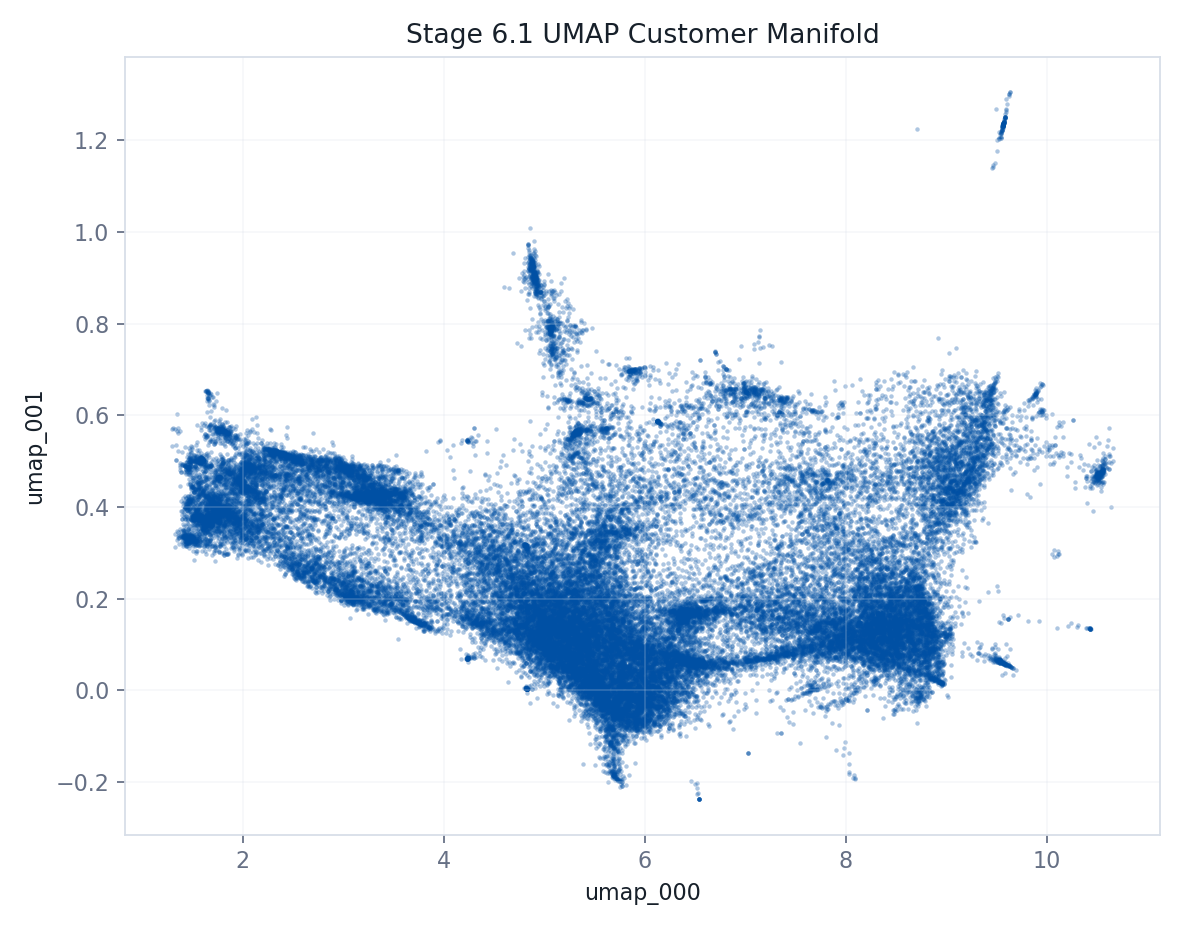

In [ ]:
stage6_umap_path = build_official_umap_core_representation(stage6_feature_path, cfg=CONFIG)
stage6_umap_checks_path = build_stage6_umap_diagnostics(stage6_feature_path, stage6_umap_path, cfg=CONFIG)
stage6_umap_checks = pl.read_csv(stage6_umap_checks_path)
stage6_pca_summary_path = CONFIG.artifacts / "stage6" / "stage6_1_pca_for_umap_summary.csv"
stage6_pca_summary = pl.read_csv(stage6_pca_summary_path)
stage6_pca_overview = stage6_pca_summary.select(
    [
        "purpose",
        "dimension_reduction",
        "requested_component_count",
        "retained_component_count",
        pl.col("retained_variance_pct").round(2),
        pl.col("pc1_variance_pct").round(2),
        pl.col("pc5_cumulative_variance_pct").round(2),
        pl.col("pc10_cumulative_variance_pct").round(2),
    ]
)
stage6_umap_figure = plot_stage6_umap_representation(stage6_umap_path, cfg=CONFIG)

display(stage6_pca_overview)
display(stage6_umap_checks)
display(Image(filename=str(stage6_umap_figure)))
if stage6_umap_checks[0, "check_status"] != "pass":
    raise ValueError(f"Stage 6.1 UMAP checks failed: {stage6_umap_checks[0, 'check_issues']}")


### Stage 6.2: First Hard HDBSCAN Pass

Run hard HDBSCAN on the full UMAP representation. This finds the first core tribes and leaves uncertain customers as first-pass noise for separate review.


[23:04:44] Stage 6 HDBSCAN: fitting density model | model=model_e_three_stage_hdbscan_lift_core_stage1, feature_space=umap_customer_embeddings_pca64_u20_n75, min_cluster_size=3500, min_samples=8
[23:04:45] Stage 6 HDBSCAN: loaded dense feature matrix | rows=1478831, features=20, fit_rows=300000, full_matrix_mb=112.8000, fit_matrix_mb=22.9000, sampled_fit=True


c:\Users\rothl\miniconda3\envs\carrefour\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\rothl\miniconda3\envs\carrefour\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[23:06:19] Stage 6 HDBSCAN: assigning full population with approximate_predict
[23:20:52] Stage 6 HDBSCAN: finished | elapsed_s=967.2000
[23:22:09] Stage 6 HDBSCAN: model evaluated | clusters=8, noise_pct=72.2484, passes_gate=False, source=hdbscan_approximate_predict, soft_assigned=0
[23:22:10] Stage 6.2 checks: wrote hard HDBSCAN diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_2_first_hdbscan_checks.csv
[23:22:12] Stage 6.2 figures: wrote hard HDBSCAN assignment map | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage6_2_first_hdbscan_assignment_map.png


stage,check_status,check_issues,blocking_check_status,blocking_check_issues,quality_gate_status,quality_gate_issues,umap_path,assignment_path,result_path,umap_rows,assignment_rows,missing_umap_customers,extra_assignment_customers,duplicate_assignment_customers,cluster_count,assigned_customers,noise_customers,noise_pct,core_coverage_pct,assignment_policy,soft_assignment_enabled,soft_assigned_pct,soft_assignment_source_rows,passes_quality_gate,quality_gate_reason
str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,str,bool,f64,i64,bool,str
"""6.2_first_hdbscan""","""fail""","""noise_pct>60.0""","""pass""","""pass""","""fail""","""noise_pct>60.0""","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…",1478831,1478831,0,0,0,8,410399,1068432,72.2484,27.7516,"""hard_hdbscan_core_noise_retain…",false,0.0,0,false,"""noise_pct>60.0"""


assignment_source,customers
str,u32
"""hdbscan_noise_unassigned""",1068432
"""hdbscan_approximate_predict""",410399


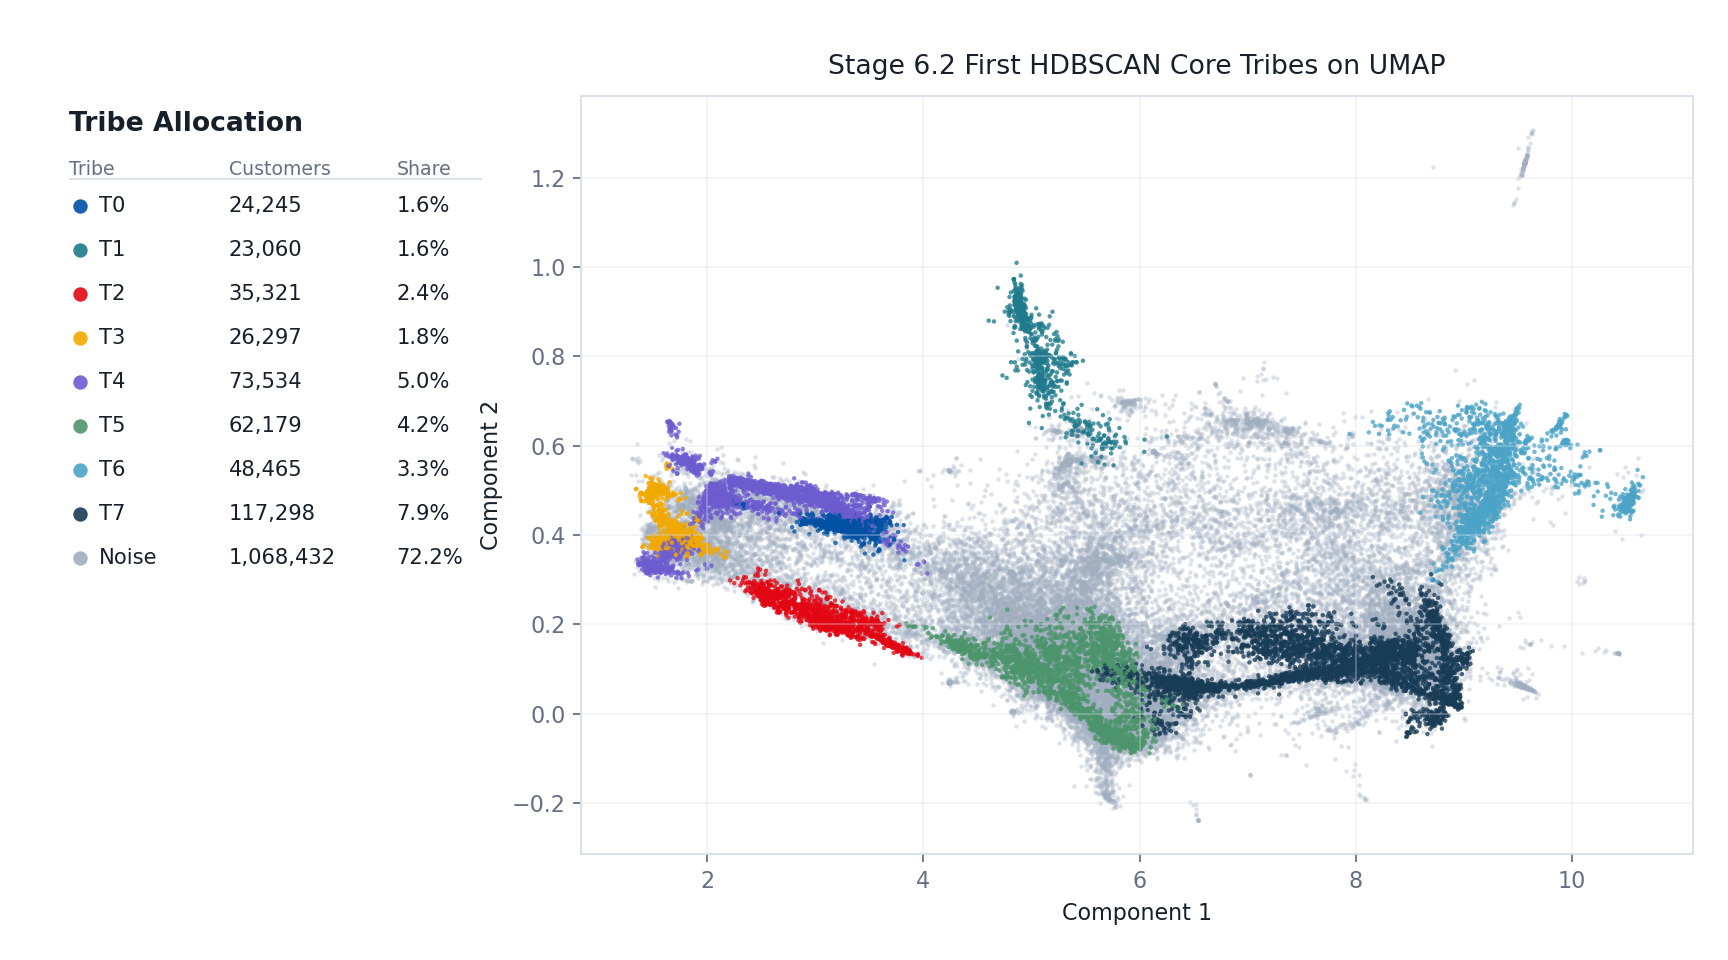

In [ ]:
stage6_stage1_assignment_path, stage6_stage1_result_path, stage6_stage1_candidate = run_official_three_stage_hdbscan_first_pass(
    stage6_umap_path,
    cfg=CONFIG,
)
stage6_stage1_checks_path = build_stage6_hdbscan_diagnostics(
    stage6_umap_path,
    stage6_stage1_assignment_path,
    stage6_stage1_result_path,
    output_path=CONFIG.artifacts / "stage6" / "stage6_2_first_hdbscan_checks.csv",
    stage_name="6.2_first_hdbscan",
    cfg=CONFIG,
)
stage6_stage1_checks = pl.read_csv(stage6_stage1_checks_path)
stage6_stage1_assignment_source_table = (
    pl.read_parquet(stage6_stage1_assignment_path)
    .group_by("assignment_source")
    .agg(pl.len().alias("customers"))
    .sort("customers", descending=True)
)
stage6_stage1_figure = plot_stage6_hdbscan_assignment_map(
    stage6_umap_path,
    stage6_stage1_assignment_path,
    output_path=CONFIG.figures / "stage6_2_first_hdbscan_assignment_map.png",
    title="Stage 6.2 First HDBSCAN Core Tribes on UMAP",
    cfg=CONFIG,
)

display(stage6_stage1_checks)
display(stage6_stage1_assignment_source_table)
display(Image(filename=str(stage6_stage1_figure)))
blocking_status_col = "blocking_check_status" if "blocking_check_status" in stage6_stage1_checks.columns else "check_status"
blocking_issues_col = "blocking_check_issues" if "blocking_check_issues" in stage6_stage1_checks.columns else "check_issues"
if stage6_stage1_checks[0, blocking_status_col] != "pass":
    raise ValueError(f"Stage 6.2 first HDBSCAN structural checks failed: {stage6_stage1_checks[0, blocking_issues_col]}")


### Stage 6.3: Second HDBSCAN Pass Over First-Pass Noise

Run a stricter HDBSCAN only on first-pass noise. This can recover dense niche groups, but customers remain unassigned unless a real density pocket is found.


[23:22:13] Stage 6 HDBSCAN: fitting density model | model=model_e_three_stage_hdbscan_lift_core_stage2, feature_space=umap_customer_embeddings_pca64_u20_n75_stage1_noise, min_cluster_size=3000, min_samples=6
[23:22:13] Stage 6 HDBSCAN: loaded dense feature matrix | rows=1068432, features=20, fit_rows=300000, full_matrix_mb=81.5000, fit_matrix_mb=22.9000, sampled_fit=True


c:\Users\rothl\miniconda3\envs\carrefour\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\rothl\miniconda3\envs\carrefour\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[23:24:06] Stage 6 HDBSCAN: assigning full population with approximate_predict
[23:33:41] Stage 6 HDBSCAN: finished | elapsed_s=687.8000
[23:34:56] Stage 6 HDBSCAN: model evaluated | clusters=8, noise_pct=80.7653, passes_gate=False, source=hdbscan_approximate_predict, soft_assigned=0
[23:34:57] Stage 6.2 checks: wrote hard HDBSCAN diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_3_second_noise_hdbscan_checks.csv
[23:34:59] Stage 6.2 figures: wrote hard HDBSCAN assignment map | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage6_3_second_noise_hdbscan_assignment_map.png


stage,check_status,check_issues,blocking_check_status,blocking_check_issues,quality_gate_status,quality_gate_issues,umap_path,assignment_path,result_path,umap_rows,assignment_rows,missing_umap_customers,extra_assignment_customers,duplicate_assignment_customers,cluster_count,assigned_customers,noise_customers,noise_pct,core_coverage_pct,assignment_policy,soft_assignment_enabled,soft_assigned_pct,soft_assignment_source_rows,passes_quality_gate,quality_gate_reason
str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,str,bool,f64,i64,bool,str
"""6.3_second_noise_hdbscan""","""fail""","""noise_pct>60.0""","""pass""","""pass""","""fail""","""noise_pct>60.0""","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…",1068432,1068432,0,0,0,8,205510,862922,80.7653,19.2347,"""hard_hdbscan_core_noise_retain…",false,0.0,0,false,"""noise_pct>60.0"""


assignment_source,customers
str,u32
"""hdbscan_noise_unassigned""",862922
"""hdbscan_approximate_predict""",205510


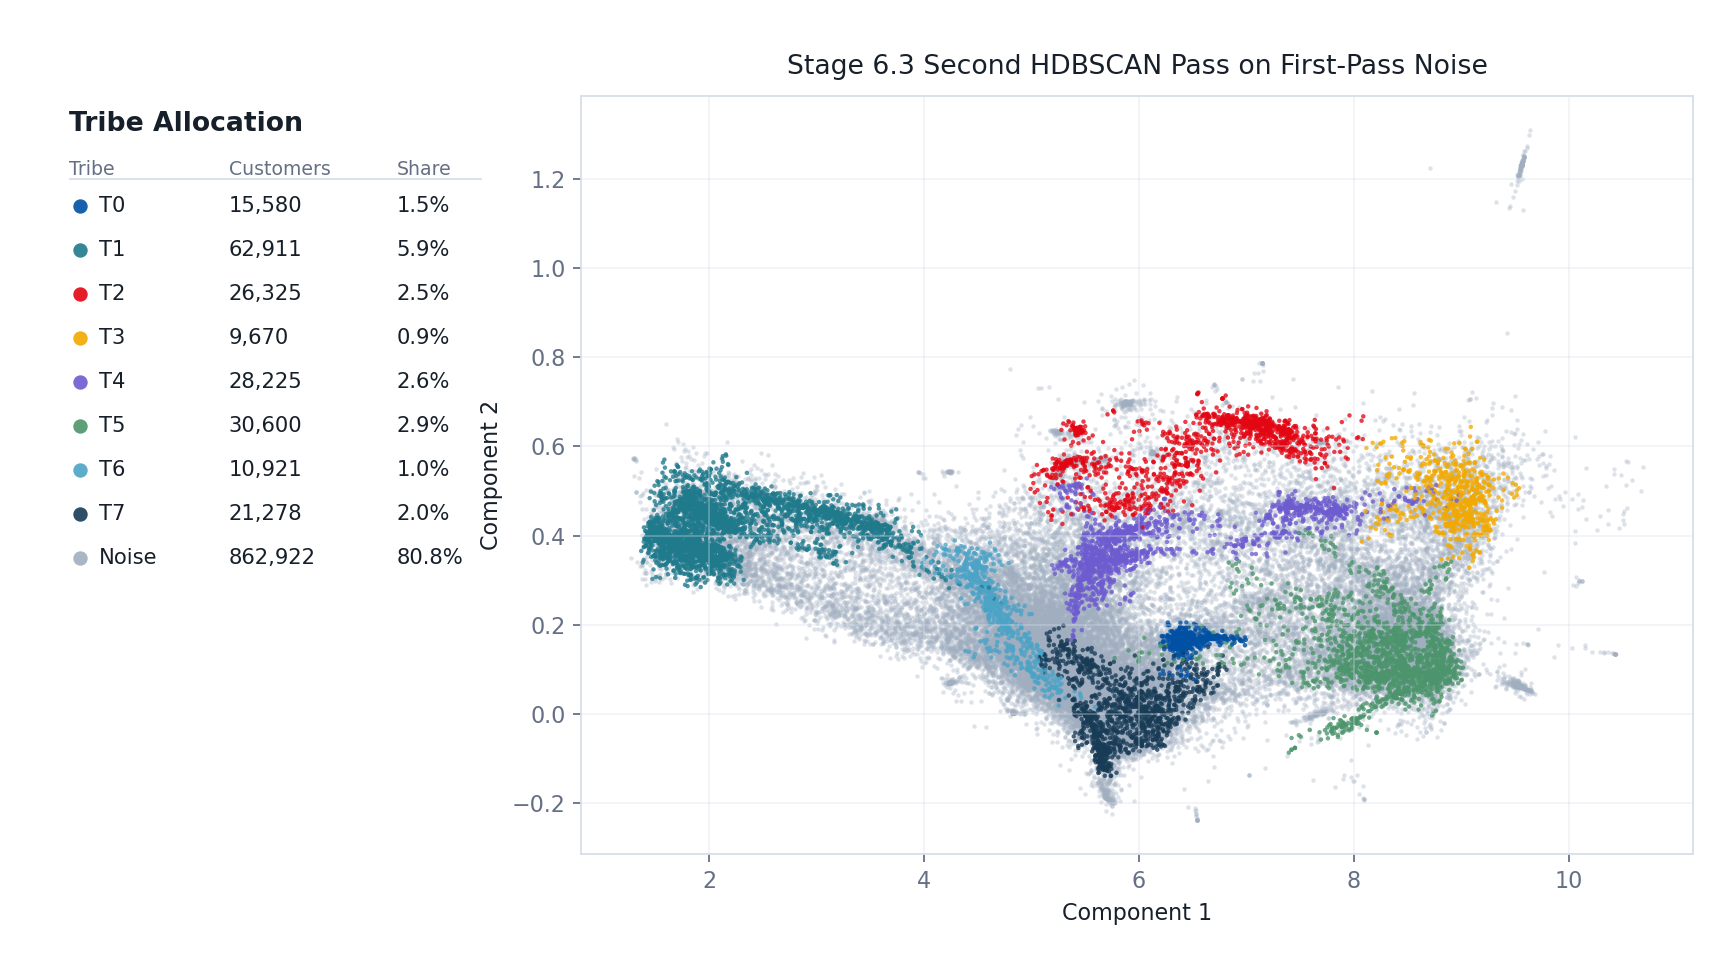

In [ ]:
(
    stage6_stage2_noise_feature_path,
    stage6_stage2_noise_customers,
    stage6_stage2_assignment_path,
    stage6_stage2_result_path,
    stage6_stage2_candidate,
) = run_official_three_stage_hdbscan_second_pass(
    stage6_umap_path,
    stage1_assignment_path=stage6_stage1_assignment_path,
    cfg=CONFIG,
)

if stage6_stage2_assignment_path is not None and stage6_stage2_result_path is not None:
    stage6_stage2_checks_path = build_stage6_hdbscan_diagnostics(
        stage6_stage2_noise_feature_path,
        stage6_stage2_assignment_path,
        stage6_stage2_result_path,
        output_path=CONFIG.artifacts / "stage6" / "stage6_3_second_noise_hdbscan_checks.csv",
        stage_name="6.3_second_noise_hdbscan",
        cfg=CONFIG,
    )
    stage6_stage2_checks = pl.read_csv(stage6_stage2_checks_path)
    stage6_stage2_assignment_source_table = (
        pl.read_parquet(stage6_stage2_assignment_path)
        .group_by("assignment_source")
        .agg(pl.len().alias("customers"))
        .sort("customers", descending=True)
    )
    stage6_stage2_figure = plot_stage6_hdbscan_assignment_map(
        stage6_stage2_noise_feature_path,
        stage6_stage2_assignment_path,
        output_path=CONFIG.figures / "stage6_3_second_noise_hdbscan_assignment_map.png",
        title="Stage 6.3 Second HDBSCAN Pass on First-Pass Noise",
        cfg=CONFIG,
    )
    display(stage6_stage2_checks)
    display(stage6_stage2_assignment_source_table)
    display(Image(filename=str(stage6_stage2_figure)))
    blocking_status_col = "blocking_check_status" if "blocking_check_status" in stage6_stage2_checks.columns else "check_status"
    blocking_issues_col = "blocking_check_issues" if "blocking_check_issues" in stage6_stage2_checks.columns else "check_issues"
    if stage6_stage2_checks[0, blocking_status_col] != "pass":
        raise ValueError(f"Stage 6.3 second HDBSCAN structural checks failed: {stage6_stage2_checks[0, blocking_issues_col]}")
else:
    stage6_stage2_checks_path = None
    stage6_stage2_figure = None
    stage6_stage2_assignment_source_table = pl.DataFrame()
    stage6_stage2_checks = pl.DataFrame([
        {
            "stage": "6.3_second_noise_hdbscan",
            "check_status": "skipped",
            "check_issues": "first-pass noise below second-pass min_cluster_size",
            "noise_customers": stage6_stage2_noise_customers,
        }
    ])
    display(Markdown(
        f"Stage 6.3 skipped: first-pass noise customers ({stage6_stage2_noise_customers:,}) "
        "are below the configured second-pass min_cluster_size."
    ))
    display(stage6_stage2_checks)


### Stage 6.4: Third Hard HDBSCAN Pass Over Remaining Noise

Run one final hard HDBSCAN pass on customers still unassigned after Stage 6.3. This is a last chance to find dense remaining pockets; the later merge and product-lift filter still decide whether those pockets are retained.


[23:35:01] Stage 6 HDBSCAN: fitting density model | model=model_e_three_stage_hdbscan_lift_core_stage3, feature_space=umap_customer_embeddings_pca64_u20_n75_stage2_noise, min_cluster_size=2000, min_samples=6
[23:35:01] Stage 6 HDBSCAN: loaded dense feature matrix | rows=862922, features=20, fit_rows=300000, full_matrix_mb=65.8000, fit_matrix_mb=22.9000, sampled_fit=True


c:\Users\rothl\miniconda3\envs\carrefour\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\rothl\miniconda3\envs\carrefour\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[23:37:03] Stage 6 HDBSCAN: assigning full population with approximate_predict
[23:45:54] Stage 6 HDBSCAN: finished | elapsed_s=652.7000
[23:46:56] Stage 6 HDBSCAN: model evaluated | clusters=6, noise_pct=92.9389, passes_gate=False, source=hdbscan_approximate_predict, soft_assigned=0
[23:46:57] Stage 6.2 checks: wrote hard HDBSCAN diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_4_third_remaining_noise_hdbscan_checks.csv
[23:46:58] Stage 6.2 figures: wrote hard HDBSCAN assignment map | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage6_4_third_remaining_noise_hdbscan_assignment_map.png


stage,check_status,check_issues,blocking_check_status,blocking_check_issues,quality_gate_status,quality_gate_issues,umap_path,assignment_path,result_path,umap_rows,assignment_rows,missing_umap_customers,extra_assignment_customers,duplicate_assignment_customers,cluster_count,assigned_customers,noise_customers,noise_pct,core_coverage_pct,assignment_policy,soft_assignment_enabled,soft_assigned_pct,soft_assignment_source_rows,passes_quality_gate,quality_gate_reason
str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,str,bool,f64,i64,bool,str
"""6.4_third_remaining_noise_hdbs…","""fail""","""noise_pct>60.0""","""pass""","""pass""","""fail""","""noise_pct>60.0""","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…",862922,862922,0,0,0,6,60932,801990,92.9389,7.0611,"""hard_hdbscan_core_noise_retain…",false,0.0,0,false,"""noise_pct>60.0"""


assignment_source,customers
str,u32
"""hdbscan_noise_unassigned""",801990
"""hdbscan_approximate_predict""",60932


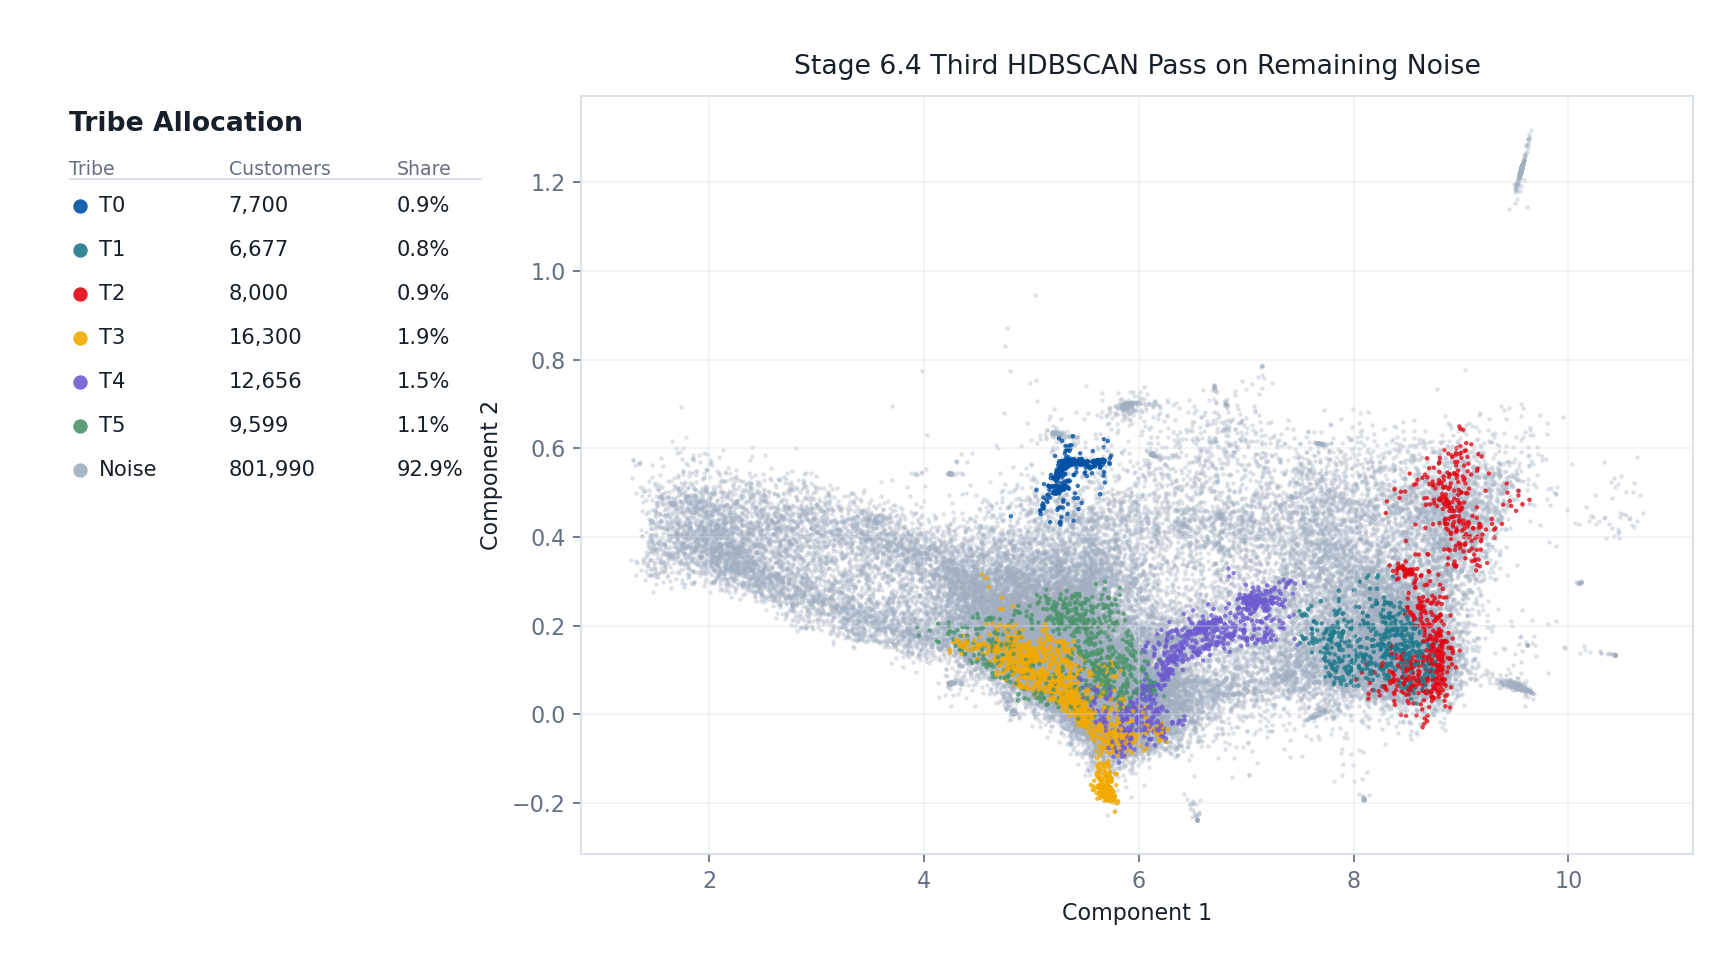

In [ ]:
(
    stage6_stage3_noise_feature_path,
    stage6_stage3_noise_customers,
    stage6_stage3_assignment_path,
    stage6_stage3_result_path,
    stage6_stage3_candidate,
) = run_official_three_stage_hdbscan_third_pass(
    stage6_umap_path,
    stage1_assignment_path=stage6_stage1_assignment_path,
    stage2_assignment_path=stage6_stage2_assignment_path,
    cfg=CONFIG,
)

if stage6_stage3_assignment_path is not None and stage6_stage3_result_path is not None:
    stage6_stage3_checks_path = build_stage6_hdbscan_diagnostics(
        stage6_stage3_noise_feature_path,
        stage6_stage3_assignment_path,
        stage6_stage3_result_path,
        output_path=CONFIG.artifacts / "stage6" / "stage6_4_third_remaining_noise_hdbscan_checks.csv",
        stage_name="6.4_third_remaining_noise_hdbscan",
        cfg=CONFIG,
    )
    stage6_stage3_checks = pl.read_csv(stage6_stage3_checks_path)
    stage6_stage3_assignment_source_table = (
        pl.read_parquet(stage6_stage3_assignment_path)
        .group_by("assignment_source")
        .agg(pl.len().alias("customers"))
        .sort("customers", descending=True)
    )
    stage6_stage3_figure = plot_stage6_hdbscan_assignment_map(
        stage6_stage3_noise_feature_path,
        stage6_stage3_assignment_path,
        output_path=CONFIG.figures / "stage6_4_third_remaining_noise_hdbscan_assignment_map.png",
        title="Stage 6.4 Third HDBSCAN Pass on Remaining Noise",
        cfg=CONFIG,
    )
    display(stage6_stage3_checks)
    display(stage6_stage3_assignment_source_table)
    display(Image(filename=str(stage6_stage3_figure)))
    blocking_status_col = "blocking_check_status" if "blocking_check_status" in stage6_stage3_checks.columns else "check_status"
    blocking_issues_col = "blocking_check_issues" if "blocking_check_issues" in stage6_stage3_checks.columns else "check_issues"
    if stage6_stage3_checks[0, blocking_status_col] != "pass":
        raise ValueError(f"Stage 6.4 third HDBSCAN structural checks failed: {stage6_stage3_checks[0, blocking_issues_col]}")
else:
    stage6_stage3_checks_path = None
    stage6_stage3_figure = None
    stage6_stage3_assignment_source_table = pl.DataFrame()
    stage6_stage3_checks = pl.DataFrame([
        {
            "stage": "6.4_third_remaining_noise_hdbscan",
            "check_status": "skipped",
            "check_issues": "remaining second-pass noise below third-pass minimum",
            "noise_customers": stage6_stage3_noise_customers,
        }
    ])
    display(Markdown(
        f"Stage 6.4 skipped: remaining second-pass noise customers ({stage6_stage3_noise_customers:,}) "
        "are below the configured third-pass minimum."
    ))
    display(stage6_stage3_checks)


### Stage 6.5: Merge Three Passes and Apply Product-Lift Filter

Merge retained clusters from the three HDBSCAN passes, then keep only clusters with enough strong significant product-lift evidence. Unsupported candidate clusters and residual noise stay unassigned.


[23:47:00] Stage 7 profiling: building organic tribe profile | assignments=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\models\model_selection\cluster_assignments_model_e_three_stage_hdbscan_lift_core_unfiltered.parquet
[23:47:01] Stage 7 profiling: assignment population | clusters=22, assigned_customers=676841, noise_customers=801990, model=model_e_three_stage_hdbscan_lift_core, variant=three_stage_u20_n75_leaf_mcs3000_ms6_balanced_stage1_mcs3500_ms8_leaf_stage2_mcs3000_ms6_leaf_stage3_mcs2000_ms6_leaf_lift
[23:47:01] Stage 7 profiling: aggregating product lift evidence | min_product_customers=10
[23:48:05] Stage 7 profiling: product lift evidence ready | rows=430466
[23:48:24] Stage 7 profiling: sector concentration evidence ready | rows=110
[23:48:24] Stage 7 profiling: assembling profile rows | clusters=22
[23:48:25] Stage 7 profiling: wrote profile | tribes=22, path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\profiles\tribe_profiles_mod

stage,check_status,check_issues,blocking_check_status,blocking_check_issues,quality_gate_status,quality_gate_issues,umap_path,assignment_path,result_path,umap_rows,assignment_rows,missing_umap_customers,extra_assignment_customers,duplicate_assignment_customers,cluster_count,assigned_customers,noise_customers,noise_pct,core_coverage_pct,assignment_policy,soft_assignment_enabled,soft_assigned_pct,soft_assignment_source_rows,passes_quality_gate,quality_gate_reason
str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,str,bool,f64,i64,bool,str
"""6.5_merged_three_stage_lift_co…","""pass""","""pass""","""pass""","""pass""","""pass""","""pass""","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…",1478831,1478831,0,0,0,22,676841,801990,54.2313,45.7687,"""hard_three_stage_hdbscan_lift_…",false,0.0,0,true,"""pass"""


assignment_source,customers
str,u32
"""three_stage_hdbscan_noise_unas…",801990
"""three_stage_hdbscan_stage1_cor…",410399
"""three_stage_hdbscan_stage2_noi…",205510
"""three_stage_hdbscan_stage3_rem…",60932


tribe_id,n_customers,strong_product_lift_threshold,min_strong_product_lifts,require_significant_product_lift,strong_product_lift_count,significant_strong_product_lift_count,passes_lift_filter
i64,i64,f64,i64,bool,i64,i64,bool
0,24245,1.5,2,true,15,15,true
1,23060,1.5,2,true,15,15,true
2,35321,1.5,2,true,15,15,true
3,26297,1.5,2,true,15,15,true
4,73534,1.5,2,true,15,15,true
…,…,…,…,…,…,…,…
17,6677,1.5,2,true,15,15,true
18,8000,1.5,2,true,15,15,true
19,16300,1.5,2,true,15,15,true


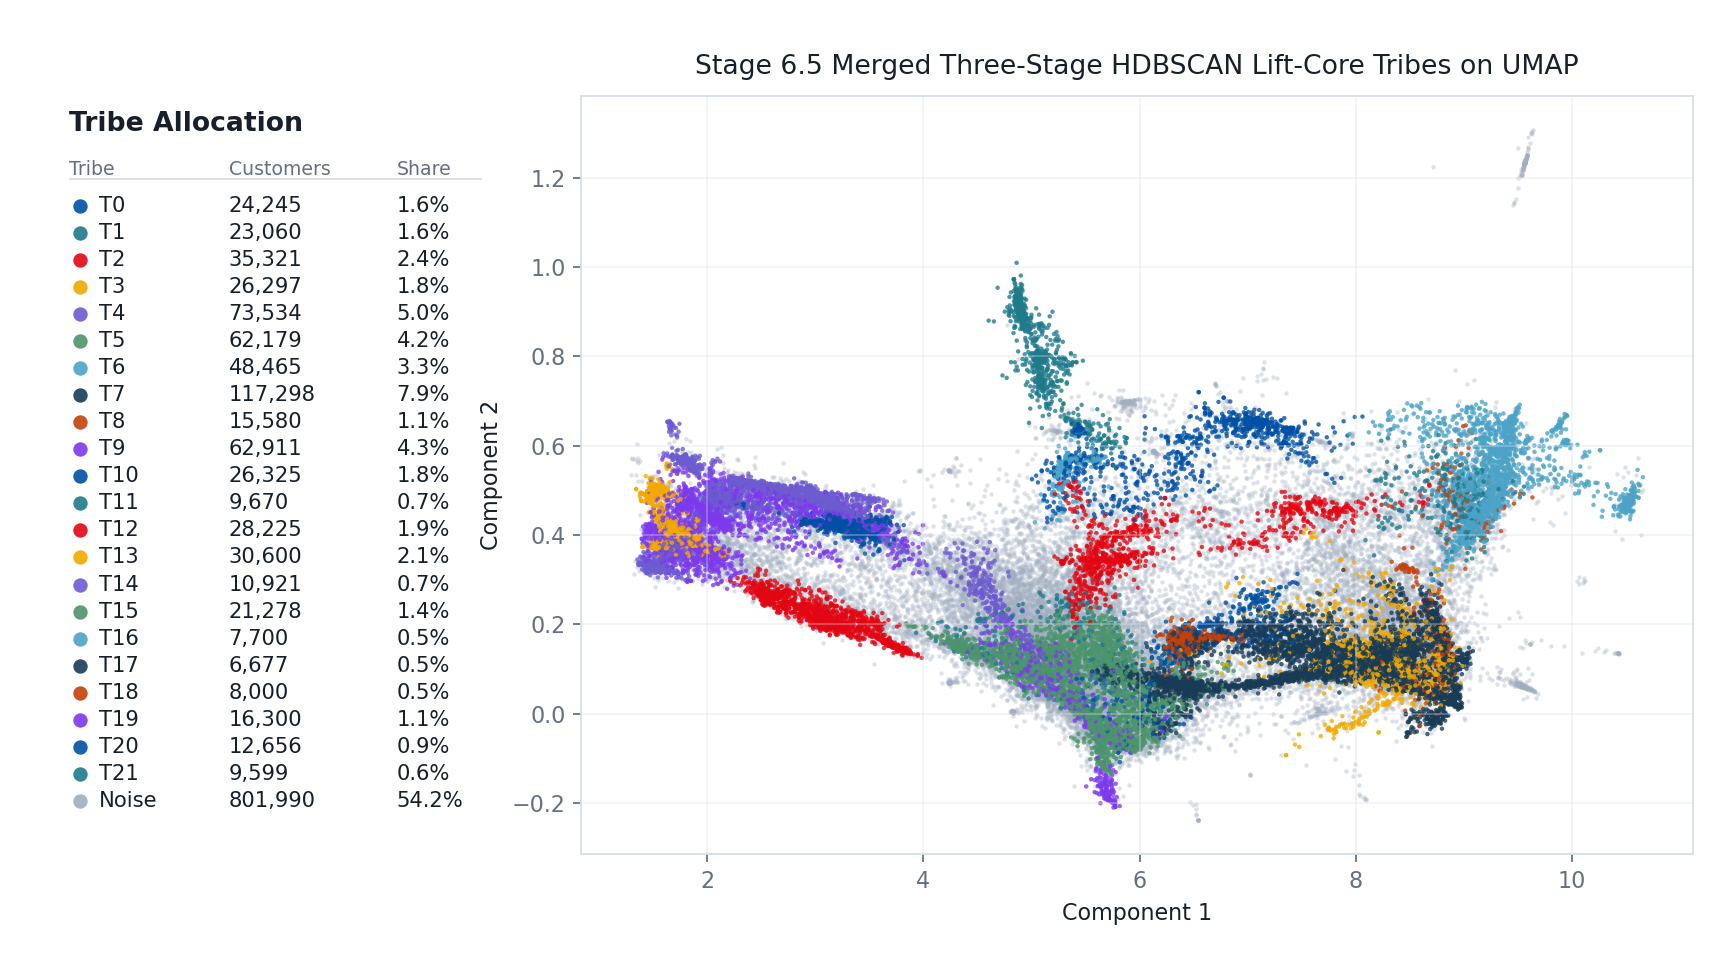

In [ ]:
stage6_assignment_path, stage6_result_path, stage6_core_candidate = merge_official_three_stage_hdbscan_lift_core(
    stage6_feature_path,
    stage6_umap_path,
    stage1_assignment_path=stage6_stage1_assignment_path,
    stage1_results_path=stage6_stage1_result_path,
    stage2_assignment_path=stage6_stage2_assignment_path,
    stage2_results_path=stage6_stage2_result_path,
    stage2_noise_feature_path=stage6_stage2_noise_feature_path,
    stage2_noise_customers=stage6_stage2_noise_customers,
    stage3_assignment_path=stage6_stage3_assignment_path,
    stage3_results_path=stage6_stage3_result_path,
    stage3_noise_feature_path=stage6_stage3_noise_feature_path,
    stage3_noise_customers=stage6_stage3_noise_customers,
    cfg=CONFIG,
)
stage6_hdbscan_checks_path = build_stage6_hdbscan_diagnostics(
    stage6_umap_path,
    stage6_assignment_path,
    stage6_result_path,
    output_path=CONFIG.artifacts / "stage6" / "stage6_5_merged_three_stage_hdbscan_checks.csv",
    stage_name="6.5_merged_three_stage_lift_core",
    cfg=CONFIG,
)
stage6_hdbscan_checks = pl.read_csv(stage6_hdbscan_checks_path)
stage6_assignment_source_table = (
    pl.read_parquet(stage6_assignment_path)
    .group_by("assignment_source")
    .agg(pl.len().alias("customers"))
    .sort("customers", descending=True)
)
stage6_lift_evidence_path = stage6_core_candidate.get("lift_filter_evidence_csv_path")
stage6_lift_evidence = pl.read_csv(stage6_lift_evidence_path) if stage6_lift_evidence_path else pl.DataFrame()
stage6_assignment_figure = plot_stage6_hdbscan_assignment_map(
    stage6_umap_path,
    stage6_assignment_path,
    output_path=CONFIG.figures / "stage6_5_merged_three_stage_hdbscan_assignment_map.png",
    title="Stage 6.5 Merged Three-Stage HDBSCAN Lift-Core Tribes on UMAP",
    cfg=CONFIG,
)

display(stage6_hdbscan_checks)
display(stage6_assignment_source_table)
if not stage6_lift_evidence.is_empty():
    display(stage6_lift_evidence)
display(Image(filename=str(stage6_assignment_figure)))
blocking_status_col = "blocking_check_status" if "blocking_check_status" in stage6_hdbscan_checks.columns else "check_status"
blocking_issues_col = "blocking_check_issues" if "blocking_check_issues" in stage6_hdbscan_checks.columns else "check_issues"
if stage6_hdbscan_checks[0, blocking_status_col] != "pass":
    raise ValueError(f"Stage 6.5 merged HDBSCAN structural checks failed: {stage6_hdbscan_checks[0, blocking_issues_col]}")


### Stage 6 Quality Evidence: Representation and Density

After the merged hard assignment exists, write compact evidence about representation quality, density validity, noise, balance, and core-only separation. This is model-quality context before the cluster-level readiness audit.


[23:49:31] Experiment summary: wrote human-readable summaries | rows=1, csv=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\model_selection\stage6_candidate_model_summary.csv
[23:49:31] Stage 6 diagnostics: wrote candidate diagnostics | candidates=1, parquet=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\model_selection\stage6_candidate_model_diagnostics.parquet, summary_csv=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\model_selection\stage6_candidate_model_summary.csv
[23:49:50] Stage 6.5 diagnostics: wrote representation and cluster quality evidence | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_6_representation_cluster_quality.csv
[23:49:50] Stage 6.5 diagnostics: wrote quality evidence scorecard | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage6_6_quality_evidence.png


# Stage 06: Hard Three-Stage UMAP-HDBSCAN Core Tribe Discovery

- Mode: `prod`

## Status
- Selection feature set: embeddings_only (official signal is product identity, quantity, and optional product-derived exp...
- Stage 6.1 PCA pre-reduces 128 -> 64 dimensions and retains 86.9% standardized variance before UMAP.
- Stage 6.1 builds the UMAP customer manifold; Stage 6.2 runs first-pass hard HDBSCAN; Stage 6.3 reruns stricter HDBSCAN ...
- Stage 6.4 runs the third pass; Stage 6.5 merges all three passes and keeps only clusters with strong significant produc...
- Stage 6.6 reports UMAP neighborhood retention and density-aware HDBSCAN validity evidence for the merged official assig...
- Official core model: model_e_three_stage_hdbscan_lift_core / three_stage_u20_n75_leaf_mcs3000_ms6_balanced_stage1_mcs35...

## Key Metrics

| Metric | Value | Ideal Value / Range |
|---|---|---|
| pca_dimension_reduction | 128 -> 64 | pre-UMAP PCA reduction |
| pca_retained_variance_pct | 86.858 | standardized variance retained before UMAP |
| first_pass_cluster_count | 8 | diagnostic first pass |
| first_pass_noise_pct | 72.248 | noise inspected in Stage 6.3 |
| second_pass_cluster_count | 8 | recovered from first-pass noise |
| second_pass_noise_customers | 1068432 | remaining candidates for second pass |
| third_pass_cluster_count | 6 | recovered from remaining second-pass noise |
| third_pass_noise_customers | 862922 | remaining candidates for third pass |
| unfiltered_cluster_count | 22 | before product-lift filtering |
| lift_supported_cluster_count | 22 | official retained clusters |
| lift_rejected_cluster_count | 0 | clusters rejected for weak product evidence |
| cluster_count | 22 | 10-15 client hypothesis; not a hard constraint |
| noise_pct | 54.231 | <= 60% quality gate; <= 40% strong |
| core_coverage_pct | 45.769 | >= 40% useful; >= 60% strong |
| quality_gate_status | pass | pass |
| quality_gate_issues | pass | pass / None |
| umap_trustworthiness | 0.9044 | >= 0.95 strong; >= 0.90 usable |
| umap_mean_knn_overlap_pct | 20.36 | >= 25% useful; >= 15% review |
| umap_distance_spearman | 0.4517 | >= 0.70 strong; >= 0.60 usable |
| hdbscan_dbcv_score | -0.1715 | >= 0.25 strong; >= 0.10 usable; near 0 weak |
| hdbscan_dbcv_status | computed | computed / unavailable / failed |
| silhouette_core_only | 0.0996 | >= 0.40 strong; >= 0.25 usable |
| coverage_adjusted_silhouette | 0.0456 | >= 0.25 strong; >= 0.15 usable |
| davies_bouldin_core_only | 2.241 | lower is better; < 1.0 usually usable |
| avg_assignment_confidence | 0.9264 | >= 0.40 stronger; >= 0.30 review |
| assignment_policy | hard_three_stage_hdbscan_lift_core_noise_retained | hard_three_stage_hdbscan_lift_core_noise_retained |
| soft_assigned_pct | 0 | 0% for official hard-core recipe |

## Visual Evidence
- Stage 6.1 UMAP representation: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage6_1_umap_representation.png`
- Stage 6.2 first HDBSCAN assignment map: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage6_2_first_hdbscan_assignment_map.png`
- Stage 6.3 second-pass noise HDBSCAN assignment map: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage6_3_second_noise_hdbscan_assignment_map.png`
- Stage 6.5 merged lift-core assignment map: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage6_5_merged_three_stage_hdbscan_assignment_map.png`
- Stage 6.6 representation and density evidence: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage6_6_quality_evidence.png`

## Artifacts
- Stage 6.1 PCA summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_1_pca_for_umap_summary.csv`
- UMAP representation: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\feature_set_umap_pca64_u20_n75.parquet`
- Stage 6.1 UMAP checks: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_1_umap_checks.csv`
- Stage 6.2 first-pass assignments: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\models\model_selection\cluster_assignments_model_e_three_stage_hdbscan_lift_core_stage1.parquet`
- Stage 6.2 first-pass checks: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_2_first_hdbscan_checks.csv`
- Stage 6.3 noise feature subset: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\models\model_selection\model_e_three_stage_hdbscan_lift_core_stage2_noise_features.parquet`
- Stage 6.3 second-pass assignments: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\models\model_selection\cluster_assignments_model_e_three_stage_hdbscan_lift_core_stage2_noise.parquet`
- Stage 6.3 second-pass checks: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_3_second_noise_hdbscan_checks.csv`
- Stage 6.5 merged lift-core assignments: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\models\model_selection\cluster_assignments_model_e_three_stage_hdbscan_lift_core.parquet`
- Stage 6.5 merged checks: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_5_merged_three_stage_hdbscan_checks.csv`
- Stage 6.5 lift filter evidence: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\model_e_three_stage_hdbscan_lift_co...`
- Stage 6.6 representation and cluster quality CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_6_representation_cluster_quality.csv`
- Diagnostics parquet: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\model_selection\stage6_candidate_model_diagnostics.parquet`
- Diagnostics summary CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\model_selection\stage6_candidate_model_summary.csv`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

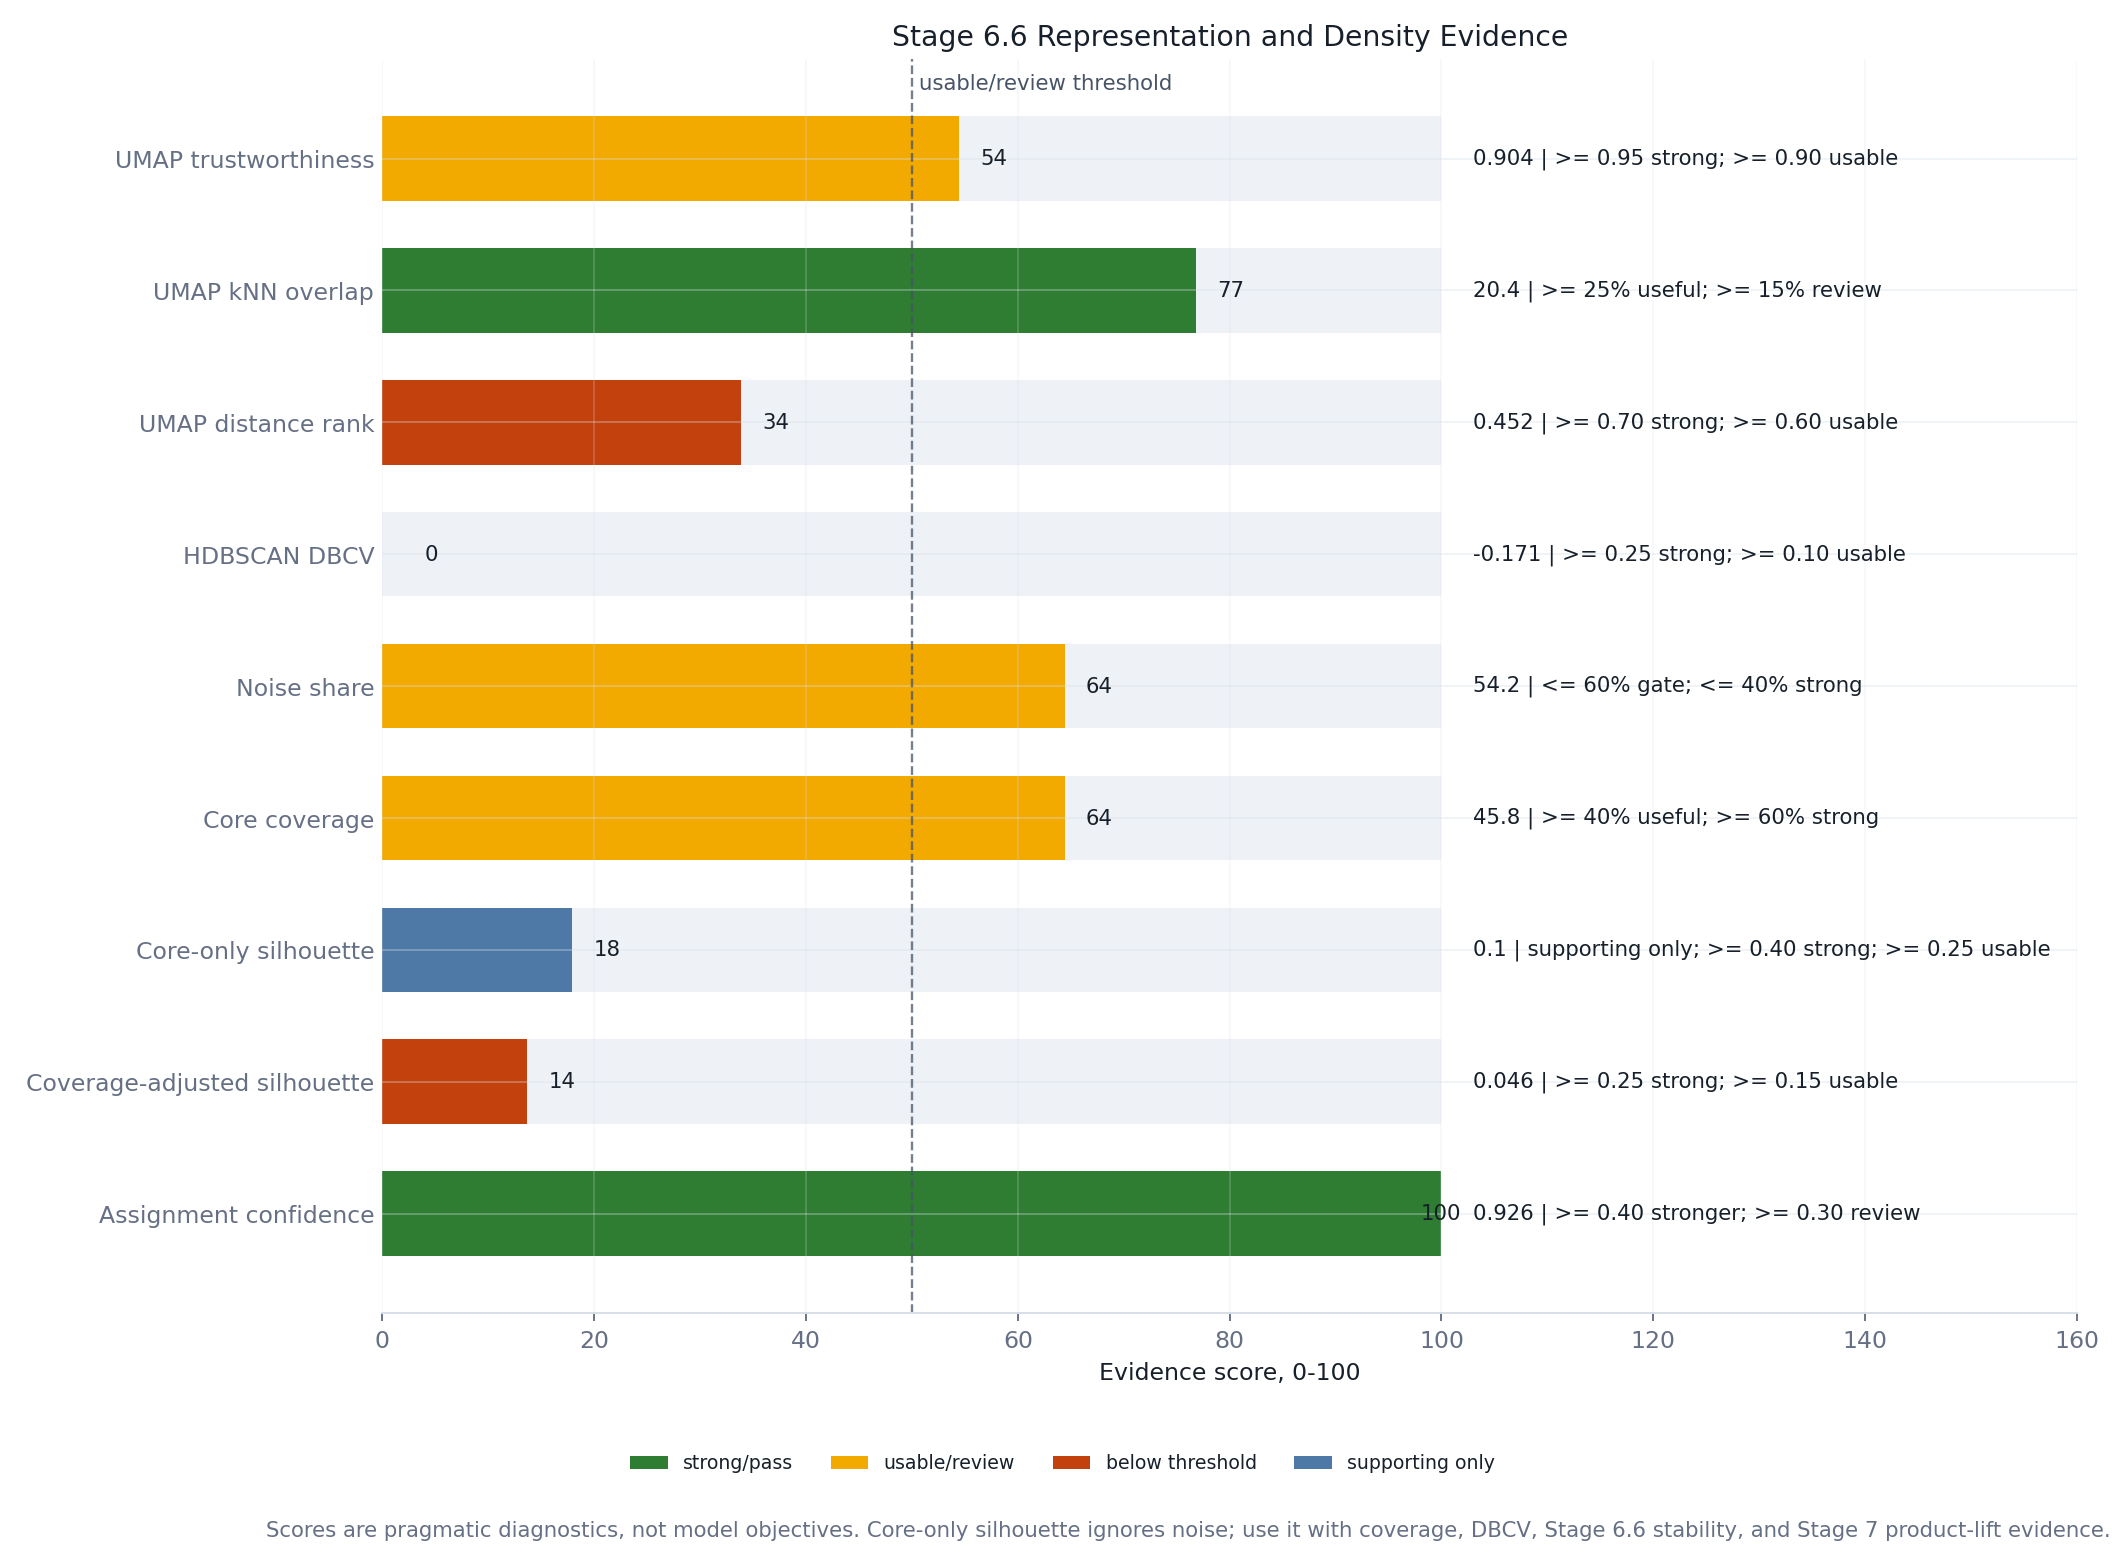

aligned_rows,source_feature_count,umap_component_count,umap_quality_sample_size,umap_neighbor_k,umap_trustworthiness,umap_mean_knn_overlap_pct,umap_distance_spearman,cluster_count,noise_pct,core_coverage_pct,hdbscan_dbcv_score,hdbscan_dbcv_status,silhouette_core_only,coverage_adjusted_silhouette,davies_bouldin_core_only,avg_assignment_confidence,hdbscan_cluster_persistence_mean
i64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,f64,str,f64,f64,f64,f64,str
1478831,128,20,5000,15,0.904443,20.36,0.451659,22,54.2313,45.7687,-0.17147,"""computed""",0.09956,0.045567,2.241155,0.926374,null


stage6_rank,candidate_id,model_name,algorithm_name,assignment_policy,model_variant,cluster_count,coverage_adjusted_silhouette,silhouette,davies_bouldin,noise_pct,core_coverage_pct,soft_assigned_pct,lift_supported_cluster_count,lift_rejected_cluster_count,passes_quality_gate
i64,str,str,str,str,str,i64,f64,f64,f64,f64,f64,f64,i64,i64,bool
1,"""model_e_three_stage_hdbscan_li…","""model_e_three_stage_hdbscan_li…","""UMAP_HDBSCAN_ThreeStageLiftCor…","""hard_three_stage_hdbscan_lift_…","""three_stage_u20_n75_leaf_mcs30…",22,0.045567,0.09956,2.241155,54.2313,45.7687,0.0,22,0,true


assignment_source,customers
str,u32
"""three_stage_hdbscan_noise_unas…",801990
"""three_stage_hdbscan_stage1_cor…",410399
"""three_stage_hdbscan_stage2_noi…",205510
"""three_stage_hdbscan_stage3_rem…",60932


In [ ]:
model_suite = model_suite_from_single_candidate(
    stage6_assignment_path,
    stage6_result_path,
    stage6_core_candidate,
    umap_path=stage6_umap_path,
)
stage6_diagnostics = build_candidate_model_diagnostics(model_suite, cfg=CONFIG)
stage6_quality_path = build_stage6_representation_cluster_diagnostics(
    stage6_feature_path,
    stage6_umap_path,
    stage6_assignment_path,
    stage6_result_path,
    output_path=CONFIG.artifacts / "stage6" / "stage6_6_representation_cluster_quality.csv",
    cfg=CONFIG,
)
stage6_quality = pl.read_csv(stage6_quality_path)
stage6_figure = plot_stage6_quality_evidence(
    stage6_quality_path,
    output_path=CONFIG.figures / "stage6_6_quality_evidence.png",
    title="Stage 6.6 Representation and Density Evidence",
    cfg=CONFIG,
)
stage6_ranked = pl.read_parquet(stage6_diagnostics["parquet"]).sort("stage6_rank")
stage6_quality_display_cols = [
    "aligned_rows",
    "source_feature_count",
    "umap_component_count",
    "umap_quality_sample_size",
    "umap_neighbor_k",
    "umap_trustworthiness",
    "umap_mean_knn_overlap_pct",
    "umap_distance_spearman",
    "cluster_count",
    "noise_pct",
    "core_coverage_pct",
    "hdbscan_dbcv_score",
    "hdbscan_dbcv_status",
    "silhouette_core_only",
    "coverage_adjusted_silhouette",
    "davies_bouldin_core_only",
    "avg_assignment_confidence",
    "hdbscan_cluster_persistence_mean",
]
stage6_quality_table = stage6_quality.select([c for c in stage6_quality_display_cols if c in stage6_quality.columns])
stage6_display_cols = [
    "stage6_rank",
    "candidate_id",
    "model_name",
    "algorithm_name",
    "assignment_policy",
    "model_variant",
    "cluster_count",
    "coverage_adjusted_silhouette",
    "silhouette",
    "davies_bouldin",
    "noise_pct",
    "core_coverage_pct",
    "soft_assigned_pct",
    "lift_supported_cluster_count",
    "lift_rejected_cluster_count",
    "passes_quality_gate",
]
stage6_table = stage6_ranked.select([c for c in stage6_display_cols if c in stage6_ranked.columns])
stage6_best = stage6_ranked.row(0, named=True)
stage6_quality_best = stage6_quality.row(0, named=True)
stage6_report_metrics = [
    ("pca_dimension_reduction", stage6_pca_summary[0, "dimension_reduction"], "pre-UMAP PCA reduction"),
    ("pca_retained_variance_pct", stage6_pca_summary[0, "retained_variance_pct"], "standardized variance retained before UMAP"),
    ("first_pass_cluster_count", stage6_stage1_candidate.get("cluster_count"), "diagnostic first pass"),
    ("first_pass_noise_pct", stage6_stage1_candidate.get("noise_pct"), "noise inspected in Stage 6.3"),
    ("second_pass_cluster_count", stage6_stage2_candidate.get("cluster_count"), "recovered from first-pass noise"),
    ("second_pass_noise_customers", stage6_stage2_noise_customers, "remaining candidates for second pass"),
    ("third_pass_cluster_count", stage6_stage3_candidate.get("cluster_count"), "recovered from remaining second-pass noise"),
    ("third_pass_noise_customers", stage6_stage3_noise_customers, "remaining candidates for third pass"),
    ("unfiltered_cluster_count", stage6_best.get("unfiltered_cluster_count"), "before product-lift filtering"),
    ("lift_supported_cluster_count", stage6_best.get("lift_supported_cluster_count"), "official retained clusters"),
    ("lift_rejected_cluster_count", stage6_best.get("lift_rejected_cluster_count"), "clusters rejected for weak product evidence"),
    ("cluster_count", stage6_quality_best.get("cluster_count"), "10-15 client hypothesis; not a hard constraint"),
    ("noise_pct", stage6_quality_best.get("noise_pct"), "<= 60% quality gate; <= 40% strong"),
    ("core_coverage_pct", stage6_quality_best.get("core_coverage_pct"), ">= 40% useful; >= 60% strong"),
    ("quality_gate_status", stage6_hdbscan_checks[0, "quality_gate_status"] if "quality_gate_status" in stage6_hdbscan_checks.columns else stage6_best.get("passes_quality_gate"), "pass"),
    ("quality_gate_issues", stage6_hdbscan_checks[0, "quality_gate_issues"] if "quality_gate_issues" in stage6_hdbscan_checks.columns else stage6_best.get("quality_gate_reason"), "pass / None"),
    ("umap_trustworthiness", stage6_quality_best.get("umap_trustworthiness"), ">= 0.95 strong; >= 0.90 usable"),
    ("umap_mean_knn_overlap_pct", stage6_quality_best.get("umap_mean_knn_overlap_pct"), ">= 25% useful; >= 15% review"),
    ("umap_distance_spearman", stage6_quality_best.get("umap_distance_spearman"), ">= 0.70 strong; >= 0.60 usable"),
    ("hdbscan_dbcv_score", stage6_quality_best.get("hdbscan_dbcv_score"), ">= 0.25 strong; >= 0.10 usable; near 0 weak"),
    ("hdbscan_dbcv_status", stage6_quality_best.get("hdbscan_dbcv_status"), "computed / unavailable / failed"),
    ("silhouette_core_only", stage6_quality_best.get("silhouette_core_only"), ">= 0.40 strong; >= 0.25 usable"),
    ("coverage_adjusted_silhouette", stage6_quality_best.get("coverage_adjusted_silhouette"), ">= 0.25 strong; >= 0.15 usable"),
    ("davies_bouldin_core_only", stage6_quality_best.get("davies_bouldin_core_only"), "lower is better; < 1.0 usually usable"),
    ("avg_assignment_confidence", stage6_quality_best.get("avg_assignment_confidence"), ">= 0.40 stronger; >= 0.30 review"),
    ("assignment_policy", stage6_best.get("assignment_policy"), "hard_three_stage_hdbscan_lift_core_noise_retained"),
    ("soft_assigned_pct", stage6_best.get("soft_assigned_pct"), "0% for official hard-core recipe"),
]
stage6_report = write_stage_report(
    "06",
    "Hard Three-Stage UMAP-HDBSCAN Core Tribe Discovery",
    summary=[
        f"Selection feature set: {selection_feature_set} (official signal is product identity, quantity, and optional product-derived exposure; no spend or demographic inputs).",
        f"Stage 6.1 PCA pre-reduces {stage6_pca_summary[0, 'dimension_reduction']} dimensions and retains {stage6_pca_summary[0, 'retained_variance_pct']:.1f}% standardized variance before UMAP.",
        "Stage 6.1 builds the UMAP customer manifold; Stage 6.2 runs first-pass hard HDBSCAN; Stage 6.3 reruns stricter HDBSCAN over first-pass noise.",
        "Stage 6.4 runs the third pass; Stage 6.5 merges all three passes and keeps only clusters with strong significant product-lift evidence.",
        "Stage 6.6 reports UMAP neighborhood retention and density-aware HDBSCAN validity evidence for the merged official assignment.",
        f"Official core model: {stage6_best['model_name']} / {stage6_best['model_variant']}",
    ],
    metrics=stage6_report_metrics,
    figures={
        "Stage 6.1 UMAP representation": stage6_umap_figure,
        "Stage 6.2 first HDBSCAN assignment map": stage6_stage1_figure,
        "Stage 6.3 second-pass noise HDBSCAN assignment map": stage6_stage2_figure,
        "Stage 6.5 merged lift-core assignment map": stage6_assignment_figure,
        "Stage 6.6 representation and density evidence": stage6_figure,
    },
    artifacts={
        "Stage 6.1 PCA summary": stage6_pca_summary_path,
        "UMAP representation": model_suite.get("umap_path"),
        "Stage 6.1 UMAP checks": stage6_umap_checks_path,
        "Stage 6.2 first-pass assignments": stage6_stage1_assignment_path,
        "Stage 6.2 first-pass checks": stage6_stage1_checks_path,
        "Stage 6.3 noise feature subset": stage6_stage2_noise_feature_path,
        "Stage 6.3 second-pass assignments": stage6_stage2_assignment_path,
        "Stage 6.3 second-pass checks": stage6_stage2_checks_path,
        "Stage 6.5 merged lift-core assignments": stage6_assignment_path,
        "Stage 6.5 merged checks": stage6_hdbscan_checks_path,
        "Stage 6.5 lift filter evidence": stage6_lift_evidence_path,
        "Stage 6.6 representation and cluster quality CSV": stage6_quality_path,
        "Diagnostics parquet": stage6_diagnostics["parquet"],
        "Diagnostics summary CSV": stage6_diagnostics["summary_csv"],
    },
    cfg=CONFIG,
    max_metric_rows=30,
)
display_stage_report(stage6_report)
display(Image(filename=str(stage6_figure)))
display(stage6_quality_table)
display(stage6_table.head(12))
display(stage6_assignment_source_table)


<a id="stage-6-6"></a>

## Stage 6.6: Quality, Stability, Readiness, and Promotion Audit

Stage 6.6 is the handoff from clustering into profiling. It checks whether each retained cluster is stable, confidence-backed, and safe enough to interpret as a tribe.

Readiness labels:

- `strong`: no blockers, jitter recovery is at least `0.80`, and mean assignment confidence is at least `0.30` when available.
- `usable`: no blockers, but below the stronger `strong` threshold.
- `review`: fails a blocker such as too few customers, missing/low jitter recovery, low mean confidence, or very low p10 confidence.

Cluster-readiness figure metrics:

- `mean_assignment_confidence`: average customer assignment confidence inside the tribe. For HDBSCAN core points this is membership strength/probability; for soft nearest-centroid points it is distance-percentile confidence.
- `jitter_label_recovery_accuracy_mean`: perturbation stability. The code adds small random noise to sampled customer vectors, assigns the perturbed points to the nearest original tribe centroid, and measures how often the original tribe label is recovered.

These metrics can disagree. High confidence with low jitter means the fitted model assigned customers confidently, but the tribe's centroid geometry is fragile: it may be close to another tribe, elongated, boundary-adjacent, or formed from a later noise-recovery pass. Treat those clusters cautiously.

The notebook-facing summary is written to `outputs/<mode>/reports/stage_06_6.md`, with cluster readiness, stability diagnostics, and winner projection figures displayed directly below.


[23:49:51] Cluster validity: building validity and stability report | feature_path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\feature_set_embeddings_only.parquet, repeats=5
[23:49:54] Cluster validity: finished | elapsed_s=2.3000
[23:49:54] Experiment summary: wrote human-readable summaries | rows=1, csv=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_6_cluster_stability_readiness_summary.csv
[23:49:54] Experiment summary: wrote human-readable summaries | rows=22, csv=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_6_cluster_stability_readiness_clusters_summary.csv
[23:49:54] Cluster validity: wrote validity and stability report | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_6_cluster_stability_readiness.parquet
[23:49:55] Stage 6.6 figures: building 2D projection figures
[23:51:47] Stage 6.6 figures: wrote projection 

# Stage 6.6: Quality, Stability, Readiness, and Promotion Audit

- Mode: `prod`

## Status
- Stage 6 winner checked: model_e_three_stage_hdbscan_lift_core::three_stage_u20_n75_leaf_mcs3000_ms6_balanced_stage1_mcs...
- Stage 6.6 focuses on the retained and rejected candidate clusters: quality, stability, confidence, size, readiness, and...
- This is the technical and evidence gate before Stage 7 business interpretation.

## Key Metrics

| Metric | Value | Ideal Value / Range |
|---|---|---|
| cluster_count | 22 | 10-15 client hypothesis; not a hard constraint |
| noise_pct | 54.231 | <= 60% quality gate; <= 40% strong |
| cluster_size_cv | 0.8654 | <= 1.5 gate; lower is more balanced |
| jitter_ari_mean | 0.3832 | >= 0.80 strong; >= 0.60 usable |
| jitter_label_recovery_accuracy_mean | 0.5766 | >= 0.80 strong; < 0.60 review blocker |
| clusters_marked_review | 7 | 0 ideal; review before profiling if > 0 |
| promotion_audit_review_not_promoted | 7 | retained but not promoted |
| promotion_audit_rejected_lift_filter | 0 | candidate clusters rejected for product evidence |
| clusters_marked_usable_or_strong | 15 | all retained clusters |

## Visual Evidence
- Cluster readiness: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage6_6_cluster_readiness.png`
- PCA projection: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage_06_6_winner_projection_pca.png`
- UMAP projection: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage_06_6_winner_projection_umap.png`

## Artifacts
- Stability/readiness parquet: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_6_cluster_stability_readiness.parquet`
- Stability/readiness summary CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_6_cluster_stability_readiness_summary.csv`
- Cluster readiness parquet: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_6_cluster_stability_readiness_clusters.parquet`
- Cluster readiness summary CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_6_cluster_stability_readiness_clusters_summary.csv`
- Cluster promotion audit CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_6_cluster_promotion_audit_prod.csv`
- Cluster promotion audit MD: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_6_cluster_promotion_audit_prod.md`
- Projection figures root: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

candidate_id,cluster_count,noise_pct,cluster_size_cv,jitter_ari_mean,jitter_ari_std,jitter_label_recovery_accuracy_mean,validity_note
str,i64,f64,f64,f64,f64,f64,str
"""model_e_three_stage_hdbscan_li…",22,54.2313,0.865386,0.383196,0.000431,0.57658,"""Checks internal geometry and p…"


candidate_id,cluster_count,noise_pct,cluster_size_cv,jitter_ari_mean,jitter_ari_std,jitter_label_recovery_accuracy_mean,validity_note
str,i64,f64,f64,f64,f64,f64,str
"""model_e_three_stage_hdbscan_li…",22,54.2313,0.865386,0.383196,0.000431,0.57658,"""Checks internal geometry and p…"


candidate_tribe_id,final_tribe_id,source_pass,candidate_customers,candidate_population_share_pct,mean_assignment_confidence,p10_assignment_confidence,jitter_label_recovery_accuracy_mean,strong_product_lift_count,significant_strong_product_lift_count,passes_lift_filter,profile_readiness,readiness_issues,promotion_status,blocker_reason
i64,i64,str,i64,f64,f64,f64,f64,i64,i64,bool,str,str,str,str
0,0,"""three_stage_hdbscan_stage1_cor…",24245,1.639471,0.987066,1.0,0.778616,15,15,true,"""usable""","""pass""","""promoted_to_stage7""","""pass"""
1,1,"""three_stage_hdbscan_stage1_cor…",23060,1.55934,0.944504,0.735571,0.792353,15,15,true,"""usable""","""pass""","""promoted_to_stage7""","""pass"""
2,2,"""three_stage_hdbscan_stage1_cor…",35321,2.388441,0.942849,0.767499,0.810507,15,15,true,"""usable""","""pass""","""promoted_to_stage7""","""pass"""
3,3,"""three_stage_hdbscan_stage1_cor…",26297,1.778229,0.964975,0.832719,0.82191,15,15,true,"""usable""","""pass""","""promoted_to_stage7""","""pass"""
4,4,"""three_stage_hdbscan_stage1_cor…",73534,4.972441,0.892862,0.675063,0.618705,15,15,true,"""usable""","""pass""","""promoted_to_stage7""","""pass"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
17,17,"""three_stage_hdbscan_stage3_rem…",6677,0.451505,0.999243,0.997578,0.494624,15,15,true,"""review""","""jitter_recovery<0.60""","""review_not_promoted""","""jitter_recovery<0.60"""
18,18,"""three_stage_hdbscan_stage3_rem…",8000,0.540968,0.999711,1.0,0.476636,15,15,true,"""review""","""jitter_recovery<0.60""","""review_not_promoted""","""jitter_recovery<0.60"""
19,19,"""three_stage_hdbscan_stage3_rem…",16300,1.102222,0.997624,0.9881,0.69869,15,15,true,"""usable""","""pass""","""promoted_to_stage7""","""pass"""


tribe_id,customers,customer_share_pct,mean_assignment_confidence,p10_assignment_confidence,jitter_label_recovery_accuracy_mean,profile_readiness,readiness_issues
i64,i64,f64,f64,f64,f64,str,str
0,24245,1.639471,0.987066,1.0,0.778616,"""usable""","""pass"""
1,23060,1.55934,0.944504,0.735571,0.792353,"""usable""","""pass"""
2,35321,2.388441,0.942849,0.767499,0.810507,"""usable""","""pass"""
3,26297,1.778229,0.964975,0.832719,0.82191,"""usable""","""pass"""
4,73534,4.972441,0.892862,0.675063,0.618705,"""usable""","""pass"""
…,…,…,…,…,…,…,…
17,6677,0.451505,0.999243,0.997578,0.494624,"""review""","""jitter_recovery<0.60"""
18,8000,0.540968,0.999711,1.0,0.476636,"""review""","""jitter_recovery<0.60"""
19,16300,1.102222,0.997624,0.9881,0.69869,"""usable""","""pass"""


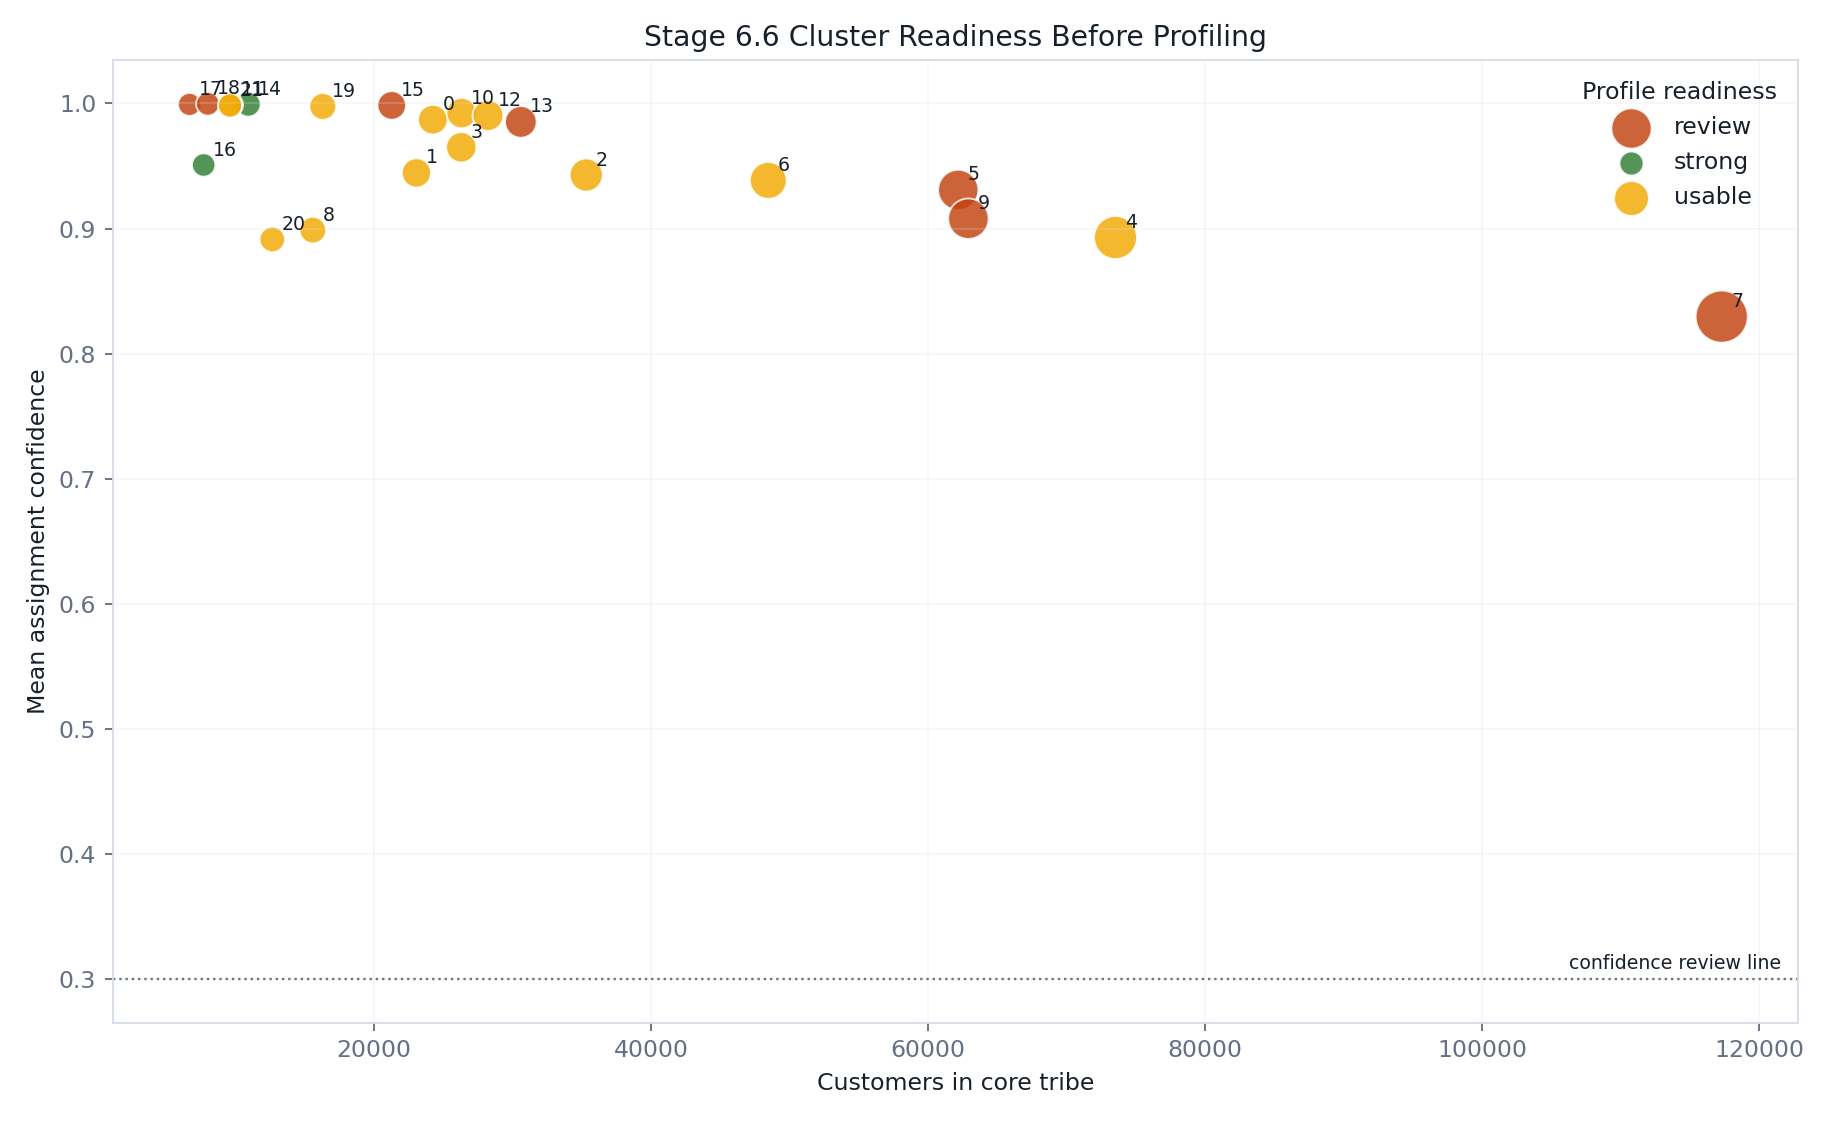

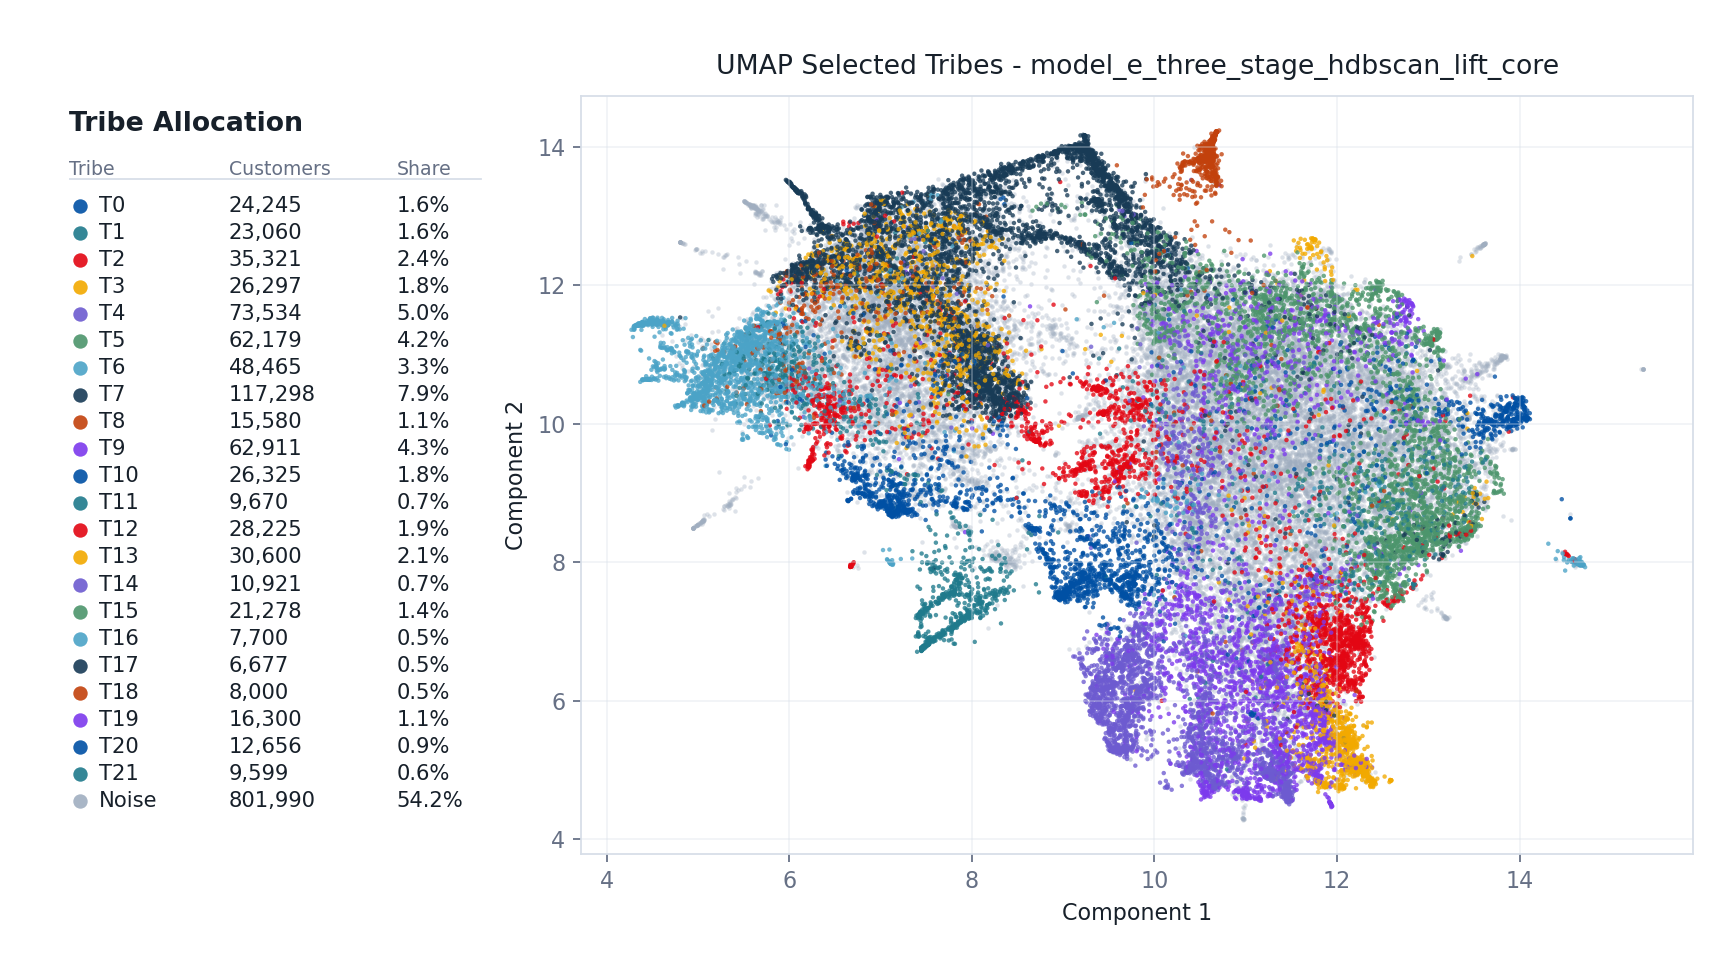

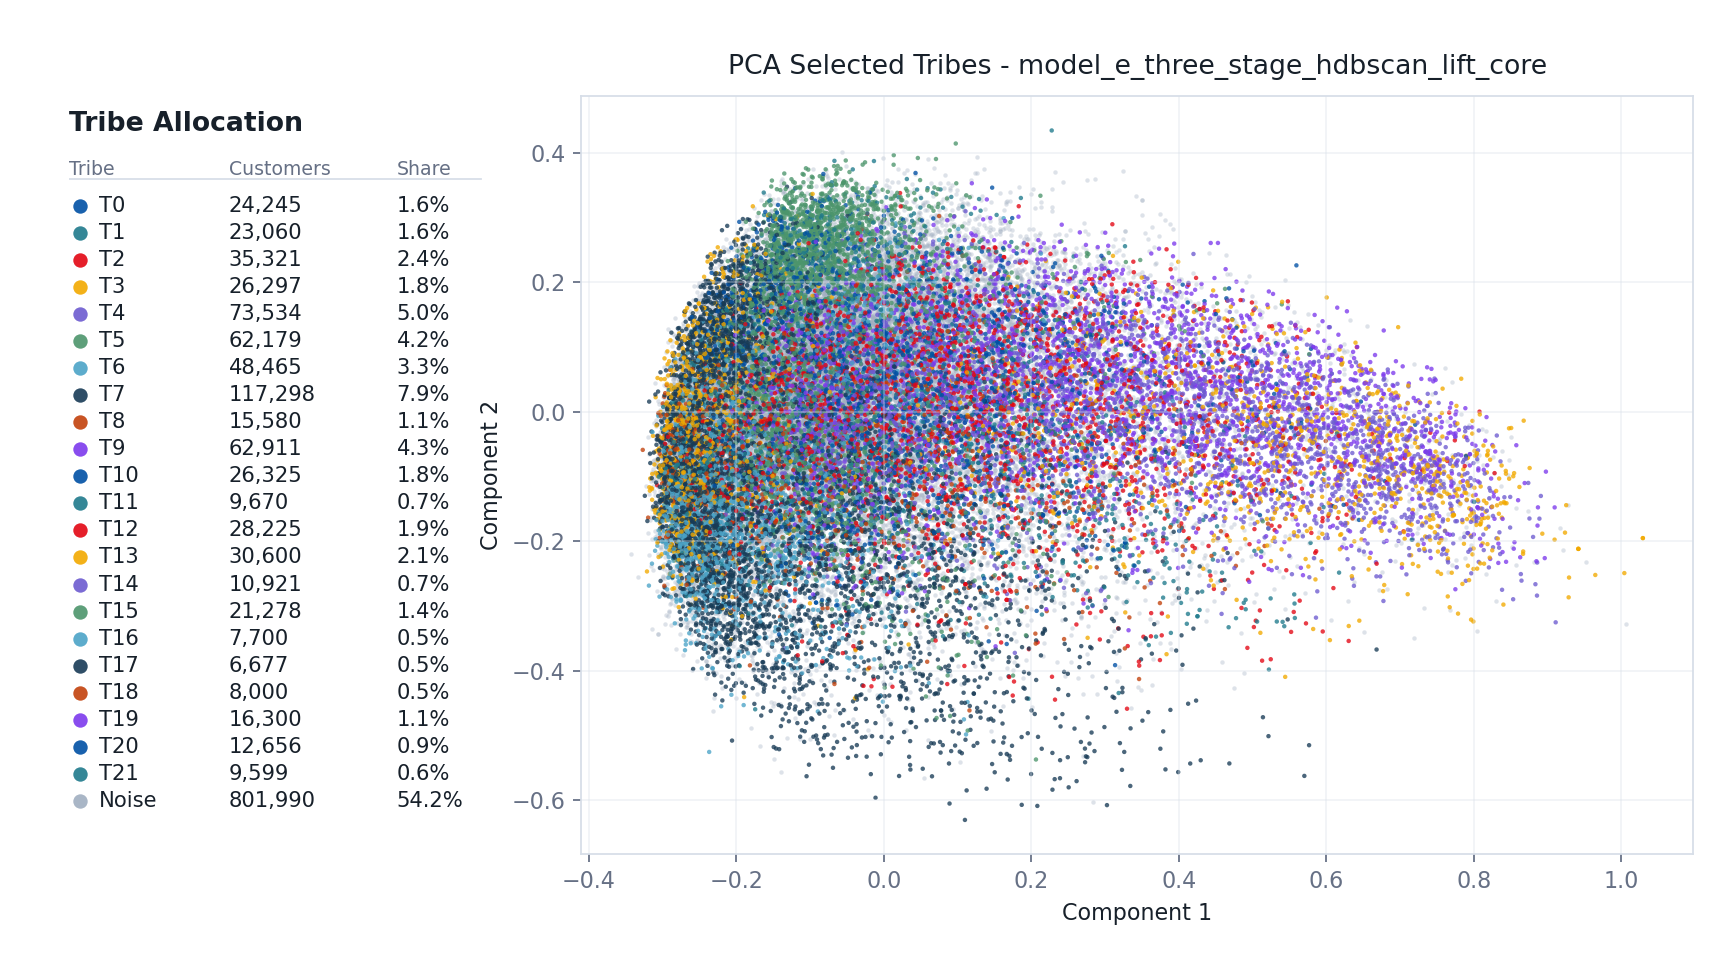

In [ ]:
from IPython.display import Image, display
import polars as pl

from src.cluster_validation import build_cluster_promotion_audit, build_cluster_validity_stability_report
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import build_2d_projection_figures, plot_stage6_cluster_readiness

cluster_stability = build_cluster_validity_stability_report(
    model_suite,
    feature_sets[selection_feature_set],
    output_path=CONFIG.artifacts / "stage6" / "stage6_6_cluster_stability_readiness.parquet",
    cfg=CONFIG,
)

stability_table = pl.read_csv(cluster_stability["summary_csv"]).select([
    "candidate_id",
    "cluster_count",
    "noise_pct",
    "cluster_size_cv",
    "jitter_ari_mean",
    "jitter_ari_std",
    "jitter_label_recovery_accuracy_mean",
    "validity_note",
])
stage6_winner_key = pl.read_parquet(stage6_diagnostics["parquet"]).sort("stage6_rank")[0, "candidate_id"]
stage6_6_winner_stability = stability_table.filter(pl.col("candidate_id") == stage6_winner_key)
cluster_readiness_table = pl.read_csv(cluster_stability["cluster_summary_csv"])
stage6_6_cluster_readiness = cluster_readiness_table.filter(pl.col("candidate_id") == stage6_winner_key)

stage6_6_promotion_audit_paths = build_cluster_promotion_audit(
    stage6_core_candidate.get("unfiltered_assignment_path"),
    stage6_core_candidate.get("lift_filter_evidence_path"),
    cluster_stability["cluster_summary_csv"],
    output_csv=CONFIG.artifacts / "stage6" / f"stage6_6_cluster_promotion_audit_{CONFIG.mode}.csv",
    output_md=CONFIG.artifacts / "stage6" / f"stage6_6_cluster_promotion_audit_{CONFIG.mode}.md",
    cfg=CONFIG,
)
stage6_6_promotion_audit = pl.read_csv(stage6_6_promotion_audit_paths["csv"])

stage6_6_projection_dir = CONFIG.figures
stage6_6_projection_figures = build_2d_projection_figures(
    feature_sets[selection_feature_set],
    model_suite["assignment_paths"][stage6_winner_key],
    output_dir=stage6_6_projection_dir,
    output_prefix="stage_06_6_winner_projection",
    stage_label="Stage 6.6 figures",
    cfg=CONFIG,
)
stage6_6_cluster_readiness_figure = plot_stage6_cluster_readiness(
    cluster_stability["cluster_summary_csv"],
    output_path=CONFIG.figures / "stage6_6_cluster_readiness.png",
    title="Stage 6.6 Cluster Readiness Before Profiling",
    cfg=CONFIG,
)
stage6_6_metrics_row = stage6_6_winner_stability.row(0, named=True)
stage6_6_report_metrics = [
    ("cluster_count", stage6_6_metrics_row.get("cluster_count"), "10-15 client hypothesis; not a hard constraint"),
    ("noise_pct", stage6_6_metrics_row.get("noise_pct"), "<= 60% quality gate; <= 40% strong"),
    ("cluster_size_cv", stage6_6_metrics_row.get("cluster_size_cv"), "<= 1.5 gate; lower is more balanced"),
    ("jitter_ari_mean", stage6_6_metrics_row.get("jitter_ari_mean"), ">= 0.80 strong; >= 0.60 usable"),
    ("jitter_label_recovery_accuracy_mean", stage6_6_metrics_row.get("jitter_label_recovery_accuracy_mean"), ">= 0.80 strong; < 0.60 review blocker"),
    ("clusters_marked_review", stage6_6_cluster_readiness.filter(pl.col("profile_readiness") == "review").height, "0 ideal; review before profiling if > 0"),
    ("promotion_audit_review_not_promoted", stage6_6_promotion_audit.filter(pl.col("promotion_status") == "review_not_promoted").height, "retained but not promoted"),
    ("promotion_audit_rejected_lift_filter", stage6_6_promotion_audit.filter(pl.col("promotion_status") == "rejected_lift_filter").height, "candidate clusters rejected for product evidence"),
    ("clusters_marked_usable_or_strong", stage6_6_cluster_readiness.filter(pl.col("profile_readiness").is_in(["usable", "strong"])).height, "all retained clusters"),
]
stage6_6_report = write_stage_report(
    "06_6",
    "Quality, Stability, Readiness, and Promotion Audit",
    summary=[
        f"Stage 6 winner checked: {stage6_winner_key}",
        "Stage 6.6 focuses on the retained and rejected candidate clusters: quality, stability, confidence, size, readiness, and explicit promotion blockers.",
        "This is the technical and evidence gate before Stage 7 business interpretation.",
    ],
    metrics=stage6_6_report_metrics,
    figures={
        "Cluster readiness": stage6_6_cluster_readiness_figure,
        "PCA projection": stage6_6_projection_figures.get("pca"),
        "UMAP projection": stage6_6_projection_figures.get("umap"),
    },
    artifacts={
        "Stability/readiness parquet": cluster_stability["parquet"],
        "Stability/readiness summary CSV": cluster_stability["summary_csv"],
        "Cluster readiness parquet": cluster_stability["cluster_parquet"],
        "Cluster readiness summary CSV": cluster_stability["cluster_summary_csv"],
        "Cluster promotion audit CSV": stage6_6_promotion_audit_paths["csv"],
        "Cluster promotion audit MD": stage6_6_promotion_audit_paths["markdown"],
        "Projection figures root": stage6_6_projection_dir,
    },
    cfg=CONFIG,
    max_metric_rows=16,
)
display_stage_report(stage6_6_report)
display(stability_table.head(20))
display(stage6_6_winner_stability)
display(stage6_6_promotion_audit)

display(stage6_6_cluster_readiness.select([
    "tribe_id",
    "customers",
    "customer_share_pct",
    "mean_assignment_confidence",
    "p10_assignment_confidence",
    "jitter_label_recovery_accuracy_mean",
    "profile_readiness",
    "readiness_issues",
]).sort("tribe_id"))
display(Image(filename=str(stage6_6_cluster_readiness_figure)))
if "umap" in stage6_6_projection_figures:
    display(Image(filename=str(stage6_6_projection_figures["umap"])))
display(Image(filename=str(stage6_6_projection_figures["pca"])))


<a id="stage-6-7"></a>

## Stage 6.7: Remaining-Customer Evidence

Stage 6.7 analyzes customers still unassigned after the hard merge. It creates descriptive remaining-customer segments and soft-affinity scores for possible campaign audiences. These are not tribe memberships and do not change the official hard assignment.


In [ ]:
from IPython.display import Markdown, display
import polars as pl

from src.profiling import write_remaining_customer_segment_artifacts
from src.stage_reports import display_stage_report, write_stage_report

stage6_7_remaining_paths = write_remaining_customer_segment_artifacts(
    stage6_assignment_path,
    behavior_path=behavior_path if "behavior_path" in globals() else None,
    output_csv=CONFIG.artifacts / "stage6" / f"stage6_7_remaining_customer_segments_{CONFIG.mode}.csv",
    output_md=CONFIG.artifacts / "stage6" / f"stage6_7_remaining_customer_segments_{CONFIG.mode}.md",
    output_html=CONFIG.artifacts / "stage6" / f"stage6_7_remaining_customer_segments_{CONFIG.mode}.html",
    affinity_output_parquet=CONFIG.artifacts / "stage6" / f"stage6_7_remaining_customer_affinity_{CONFIG.mode}.parquet",
    cfg=CONFIG,
)
stage6_7_remaining_segments = pl.read_csv(stage6_7_remaining_paths["csv"])
stage6_7_affinity = pl.read_parquet(stage6_7_remaining_paths["affinity_parquet"])
stage6_7_affinity_summary = (
    stage6_7_affinity.group_by("affinity_confidence_band")
    .agg(pl.len().alias("customers"))
    .sort("customers", descending=True)
    if not stage6_7_affinity.is_empty()
    else pl.DataFrame()
)

stage6_7_report_metrics = [
    ("remaining_customer_segments", stage6_7_remaining_segments.height, "business-readable descriptive segments"),
    ("remaining_customers", int(stage6_7_remaining_segments["customer_count"].sum()) if not stage6_7_remaining_segments.is_empty() else 0, "still unassigned after hard merge"),
    ("affinity_rows", stage6_7_affinity.height, "remaining customers scored against hard-tribe centroids"),
    ("high_confidence_affinity_rows", stage6_7_affinity.filter(pl.col("affinity_confidence_band") == "high").height if not stage6_7_affinity.is_empty() else 0, "eligible for later soft-audience review"),
]
stage6_7_report = write_stage_report(
    "06_7",
    "Remaining-Customer Evidence",
    summary=[
        "Stage 6.7 keeps hard assignments authoritative and analyzes the customers still outside the retained tribes.",
        "Segments are descriptive business groups, not hidden hard tribes.",
        "Soft affinity is campaign-use evidence only and does not alter official membership.",
    ],
    metrics=stage6_7_report_metrics,
    artifacts={
        "Remaining customer segments CSV": stage6_7_remaining_paths["csv"],
        "Remaining customer segments MD": stage6_7_remaining_paths["markdown"],
        "Remaining customer segments HTML": stage6_7_remaining_paths["html"],
        "Remaining customer affinity parquet": stage6_7_remaining_paths["affinity_parquet"],
    },
    cfg=CONFIG,
    max_metric_rows=16,
)
display_stage_report(stage6_7_report)
display(stage6_7_remaining_segments)
if not stage6_7_affinity_summary.is_empty():
    display(Markdown("### Remaining-Customer Soft Affinity Bands"))
    display(stage6_7_affinity_summary)


# Stage 6.7: Remaining-Customer Evidence

- Mode: `prod`

## Status
- Stage 6.7 keeps hard assignments authoritative and analyzes the customers still outside the retained tribes.
- Segments are descriptive business groups, not hidden hard tribes.
- Soft affinity is campaign-use evidence only and does not alter official membership.

## Key Metrics

| Metric | Value | Ideal Value / Range |
|---|---|---|
| remaining_customer_segments | 6 | business-readable descriptive segments |
| remaining_customers | 801990 | still unassigned after hard merge |
| affinity_rows | 801990 | remaining customers scored against hard-tribe centroids |
| high_confidence_affinity_rows | 120910 | eligible for later soft-audience review |

## Artifacts
- Remaining customer segments CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_7_remaining_customer_segments_prod.csv`
- Remaining customer segments MD: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_7_remaining_customer_segments_prod.md`
- Remaining customer segments HTML: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_7_remaining_customer_segments_prod.html`
- Remaining customer affinity parquet: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_7_remaining_customer_affinity_prod.parquet`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

segment_id,segment_name,customer_count,share_of_remaining_pct,share_of_total_pct,closest_tribe_id,closest_tribe_affinity_mean,second_tribe_id,affinity_margin_mean,product_theme_signal,targetability,likely_reason_for_no_hard_cluster,recommended_action,avg_ticket_count,avg_total_spend,avg_basket_value,avg_promo_share,avg_unique_products,avg_unique_sectors,avg_recency_days,avg_frequency_per_30d
str,str,i64,f64,f64,i64,f64,i64,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""near_tribe_fringe_customers""","""Near-tribe fringe customers""",120910,15.076,8.176,0,0.824936,1,0.197754,"""Behaviorally close to one hard…","""high""","""Close to a core tribe but outs…","""Use as a measured expansion au…",10.89713,244.784514,27.667974,0.22508,44.144852,3.159987,51.512001,11.31732
"""bridge_customers_between_tribe…","""Bridge customers between tribe…",341588,42.593,23.099,5,0.775252,21,0.027335,"""Affinity is split across multi…","""medium""","""Mixed purchase missions blur t…","""Avoid exclusive tribe messagin…",16.57983,683.553058,46.127293,0.224907,125.45434,3.580811,25.309279,6.882023
"""high_value_broad_basket_custom…","""High-value broad-basket custom…",35171,4.385,2.378,5,0.720814,21,0.086125,"""High spend plus broad product …","""high""","""Large baskets span multiple mi…","""Prioritize retention, premium …",52.97896,1838.622936,57.821432,0.244133,276.668107,4.306104,7.416309,9.302165
"""broad_generalist_shoppers""","""Broad generalist shoppers""",95140,11.863,6.433,0,0.577827,19,0.095312,"""Wide product or sector variety…","""medium""","""Generalist baskets dilute prod…","""Use lifecycle, store, and bask…",14.259943,338.664838,33.003157,0.246597,75.066544,3.982153,21.138711,3.148432
"""sparse_low_signal_shoppers""","""Sparse or low-signal shoppers""",155026,19.33,10.483,2,0.579945,2,0.07363,"""Low spend, low visits, or few …","""low""","""Too little behavioral evidence…","""Use onboarding, reactivation, …",2.5754,86.6301,44.411398,0.210549,21.821288,2.81925,60.719195,12.725548
"""unclear_long_tail_customers""","""Unclear long-tail customers""",54155,6.753,3.662,6,0.492855,4,0.065967,"""No strong affinity or simple b…","""low""","""Long-tail behavior remains het…","""Monitor after more transaction…",8.332102,188.275809,27.383211,0.220066,43.388533,2.854824,29.214791,2.39379


### Remaining-Customer Soft Affinity Bands

affinity_confidence_band,customers
str,u32
"""low""",434795
"""medium""",246285
"""high""",120910


<a id="stage-6-8"></a>

## Stage 6.8: Tribe Evidence Assembly

Stage 6.8 is the boundary between clustering and interpretation. It reads the final Stage 6 assignment, transactions, behavioral features, and Stage 6.6 readiness once, then writes the evidence bundle used by Stage 7.

After this point, Stage 7 should not reopen raw/prepared inputs or change membership. It should read `tribe_evidence_<mode>.parquet`, the Stage 6.8 manifest, per-tribe exports, and Stage 6.7 remaining-customer outputs.

The notebook-facing summary is written to `outputs/<mode>/reports/stage_06_8.md`; the evidence bundle itself is written under `outputs/<mode>/artifacts/stage6/stage6_8_evidence/`.


In [ ]:
import json
import polars as pl
from IPython.display import Image, display

from src.profiling import build_stage68_tribe_evidence
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_stage68_evidence_overview

cluster_readiness_source = cluster_stability.get("cluster_summary_csv") if "cluster_stability" in globals() else None
stage6_8_evidence = build_stage68_tribe_evidence(
    stage6_assignment_path,
    cluster_readiness_path=cluster_readiness_source,
    behavior_path=behavior_path if "behavior_path" in globals() else None,
    cfg=CONFIG,
)
stage6_8_manifest_path = stage6_8_evidence["manifest_json"]
stage6_8_tribe_evidence_path = stage6_8_evidence["tribe_evidence_path"]
stage6_8_product_lifts_path = stage6_8_evidence["product_lifts_path"]
stage6_8_sector_lifts_path = stage6_8_evidence["sector_lifts_path"]
stage6_8_customer_metric_tests_path = stage6_8_evidence["customer_metric_tests_csv"]
stage6_8_manifest = stage6_8_evidence["manifest"]
stage6_8_counts = stage6_8_manifest.get("row_counts", {})
stage6_8_readiness_summary = stage6_8_manifest.get("readiness_summary", {})
stage6_8_overview_figure = plot_stage68_evidence_overview(
    stage6_8_tribe_evidence_path,
    noise_vs_core_path=stage6_8_evidence.get("noise_vs_core_customer_metrics_csv"),
    output_path=CONFIG.figures / f"stage6_8_tribe_evidence_overview_{CONFIG.mode}.png",
    cfg=CONFIG,
)
stage6_8_report = write_stage_report(
    "06_8",
    "Tribe Evidence Assembly",
    summary=[
        "Stage 6.8 precomputes product lifts, sector lifts, co-purchase, behavioral, temporal, loyalty, ANOVA, and analyst exports for every retained Stage 6 tribe before Stage 7.",
        "The retained evidence count is allowed to differ from the final promoted profile count; Stage 7 profiles only the Stage 6.6 promoted readiness statuses carried here.",
        "Stage 7 should consume the saved tribe evidence parquet, Stage 6.8 manifest, and per-tribe exports rather than reopening raw evidence inputs.",
        f"Evidence root: {stage6_8_manifest_path.parent}",
    ],
    metrics=[
        ("tribe_evidence_rows", stage6_8_counts.get("tribe_evidence"), "one row per retained Stage 6 tribe before readiness filtering"),
        ("stage6_6_promoted_tribes", stage6_8_readiness_summary.get("promoted_tribes"), "Stage 7 card/index candidates"),
        ("stage6_6_review_tribes", stage6_8_readiness_summary.get("review_tribes"), "held for review; no Stage 7 card/index row"),
        ("stage6_6_missing_readiness", stage6_8_readiness_summary.get("missing_readiness_tribes"), "0 required for a coherent Stage 6.8-to-Stage 7 handoff"),
        ("product_lift_rows", stage6_8_counts.get("product_lifts"), "full tribe x product evidence table"),
        ("sector_lift_rows", stage6_8_counts.get("sector_lifts"), "full tribe x sector evidence table"),
        ("customer_metric_tests", stage6_8_counts.get("customer_metric_tests"), "precomputed ANOVA rows"),
        ("transaction_export_files", len(stage6_8_manifest.get("transaction_exports", [])), "one parquet per tribe"),
        ("customer_export_files", len(stage6_8_manifest.get("customer_exports", [])), "one customer KPI parquet per tribe"),
    ],
    figures={
        "Stage 6.8 evidence overview": stage6_8_overview_figure,
    },
    artifacts={
        "Stage 6.8 manifest": stage6_8_manifest_path,
        "Tribe evidence parquet": stage6_8_tribe_evidence_path,
        "Product lifts parquet": stage6_8_product_lifts_path,
        "Sector lifts parquet": stage6_8_sector_lifts_path,
        "Customer metric ANOVA CSV": stage6_8_customer_metric_tests_path,
        "Transaction exports": stage6_8_evidence.get("transaction_export_dir"),
        "Customer summary exports": stage6_8_evidence.get("customer_export_dir"),
    },
    cfg=CONFIG,
    max_metric_rows=12,
)
display_stage_report(stage6_8_report)
display(Image(filename=str(stage6_8_overview_figure)))


[23:51:55] Stage 6.8 evidence: assembling tribe evidence from raw inputs
[23:51:55] Stage 6.8 evidence: building organic tribe profile | assignments=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\models\model_selection\cluster_assignments_model_e_three_stage_hdbscan_lift_core.parquet
[23:51:56] Stage 6.8 evidence: assignment population | clusters=22, assigned_customers=676841, noise_customers=801990, model=model_e_three_stage_hdbscan_lift_core, variant=three_stage_u20_n75_leaf_mcs3000_ms6_balanced_stage1_mcs3500_ms8_leaf_stage2_mcs3000_ms6_leaf_stage3_mcs2000_ms6_leaf_lift
[23:51:56] Stage 6.8 evidence: aggregating product lift evidence | min_product_customers=10
[23:53:07] Stage 6.8 evidence: product lift evidence ready | rows=430466
[23:53:26] Stage 6.8 evidence: sector concentration evidence ready | rows=110
[23:53:26] Stage 6.8 evidence: assembling profile rows | clusters=22


<a id="stage-7"></a>

## Stage 7: Tribe Profiling and Stakeholder Handoff

Stage 7 is read-only interpretation. It turns frozen Stage 6/6.8 evidence into stakeholder-facing profiles, caveats, soft-audience opportunities, relationships, and final handoff materials. It can explain tribes, but it cannot change assignments or promote review tribes silently.


### Stage 7.0: Scope And Readiness Map

Generate the Stage 7 artifact pack from the Stage 6.8 evidence bundle. This confirms promoted tribe count, review-only tribe count, remaining-customer coverage, and handoff paths before interpretation starts.


In [ ]:
import polars as pl
from pathlib import Path
from IPython.display import Image, Markdown, display

from src.profiling import (
    profile_quality_summary,
    write_stage7_final_handoff_pack,
)
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_tribe_vs_population_evidence_dashboard

stage6_ranked = pl.read_parquet(stage6_diagnostics["parquet"]).sort("stage6_rank")
stage6_winner = stage6_ranked.row(0, named=True)
selected_key = stage6_winner["candidate_id"]

stage7_artifacts_dir = CONFIG.artifacts / "stage7"
stage7_figures_dir = CONFIG.figures
stage7_artifacts_dir.mkdir(parents=True, exist_ok=True)
stage7_figures_dir.mkdir(parents=True, exist_ok=True)

selected_profile_path = stage6_8_tribe_evidence_path
stage68_manifest_path = stage6_8_manifest_path
stage7_quality = profile_quality_summary(selected_profile_path, cfg=CONFIG)

stage7_final_pack = write_stage7_final_handoff_pack(
    selected_profile_path,
    stage68_manifest_path=stage68_manifest_path,
    output_dir=stage7_artifacts_dir / "final_handoff",
    write_cards=True,
    cfg=CONFIG,
)
stage7_final_index = stage7_final_pack["final_index"]
stage7_card_paths = stage7_final_pack["card_paths"]
stage7_card_count = len(stage7_card_paths)
stage7_final_tribes = stage7_final_index.height
stage7_review_candidates = stage7_final_pack["review_candidates"]
stage7_review_clusters = stage7_review_candidates.height

stage7_substage_paths = stage7_final_pack["substage_paths"]
stage7_all_tribe_profiles = pl.read_csv(stage7_substage_paths["all_tribe_profiles"]["csv"])
stage7_review_tribe_audit = pl.read_csv(stage7_substage_paths["review_tribe_audit"]["csv"])
stage7_remaining_customer_analysis = pl.read_csv(stage7_substage_paths["remaining_customer_analysis"]["csv"])
stage7_soft_audience_opportunities = pl.read_csv(stage7_substage_paths["soft_audience_opportunities"]["csv"])
stage7_relationship_atlas = pl.read_csv(stage7_substage_paths["tribe_relationship_atlas"]["csv"])
stage7_persona_deep_dives_path = Path(stage7_substage_paths["persona_deep_dives"]["markdown"])
stage7_stakeholder_readiness_paths = stage7_final_pack["stakeholder_readiness_paths"]
stage7_campaign_playbook_paths = stage7_final_pack["campaign_playbook_paths"]
stage7_stakeholder_readiness = pl.read_csv(stage7_stakeholder_readiness_paths["csv"])
stage7_campaign_playbook = pl.read_csv(stage7_campaign_playbook_paths["csv"])
stage7_soft_activation_customers_path = stage7_final_pack["soft_audience_activation_customers_csv"]
stage7_soft_activation_customers = pl.read_csv(stage7_soft_activation_customers_path)
stage7_customer_metric_tests_path = stage7_final_pack["customer_metric_tests_csv"]
stage7_customer_metric_tests = pl.read_csv(stage7_customer_metric_tests_path)
stage7_llm_evidence_path = stage7_final_pack["llm_evidence_csv"]
q_threshold = float(CONFIG.get("profiling.significance_q_threshold", 0.05))
stage7_significant_customer_metric_tests = (
    stage7_customer_metric_tests.filter(pl.col("anova_q_value") <= q_threshold).height
    if not stage7_customer_metric_tests.is_empty() and "anova_q_value" in stage7_customer_metric_tests.columns
    else 0
)

tribe_vs_population_dashboard = plot_tribe_vs_population_evidence_dashboard(
    selected_profile_path,
    output_path=stage7_figures_dir / f"stage_07_tribe_vs_population_evidence_dashboard_{CONFIG.mode}.png",
    cfg=CONFIG,
)

stage7_model_table = pl.DataFrame([
    {
        "stage6_rank": stage6_winner.get("stage6_rank"),
        "candidate_id": selected_key,
        "cluster_count": stage6_winner.get("cluster_count"),
        "profile_path": str(selected_profile_path),
        "final_story": str(stage7_final_pack["story_markdown"]),
        "final_index": str(stage7_final_pack["index_csv"]),
        "tribe_cards": str(stage7_final_pack["card_directory"]),
    }
])
stage7_scope_table = pl.DataFrame([
    {
        "total_profiled_tribes": int(stage7_all_tribe_profiles.height),
        "promoted_tribes": int(stage7_final_tribes),
        "review_tribes": int(stage7_review_clusters),
        "remaining_customer_segments": int(stage7_remaining_customer_analysis.height),
        "soft_audience_opportunities": int(stage7_soft_audience_opportunities.height),
        "relationship_pairs": int(stage7_relationship_atlas.height),
        "stakeholder_readiness_status": stage7_stakeholder_readiness.filter(pl.col("check_id") == "overall_delivery_readiness")[0, "status"] if not stage7_stakeholder_readiness.is_empty() else "missing",
        "stakeholder_readiness_critical_findings": stage7_stakeholder_readiness.filter((pl.col("status") == "fail") & (pl.col("severity") == "critical")).height if not stage7_stakeholder_readiness.is_empty() else 0,
        "soft_activation_customer_rows": int(stage7_soft_activation_customers.height),
    }
])
stage7_report = write_stage_report(
    "07",
    "Tribe Profiling and Communication",
    summary=[
        f"Profiling selected Stage 6 model: {selected_key}",
        "Accepted Stage 6.6 readiness as final and profiled only promoted readiness statuses from the Stage 6.8 evidence parquet.",
        "Read Stage 6.8 master evidence plus per-tribe transaction/customer exports; no global raw-data or assignment fallback is allowed.",
        "Review tribes receive full audit profiles and are explicitly marked not promoted.",
        "Cards and index rows combine distinctive product evidence, widely purchased products, sector spend share, spend percentiles, recency, temporal, and loyalty context.",
    ],
    metrics=[
        ("profiled_candidate_tribes", stage7_quality.get("profiled_clusters"), "all retained Stage 6 clusters reviewed"),
        ("final_promoted_tribes", stage7_final_tribes, "Stage 6.6 promoted readiness only"),
        ("tribe_cards", stage7_card_count, "one PNG card per final promoted tribe"),
        ("review_candidate_clusters", stage7_review_clusters, "held out and recorded in manifest"),
        ("all_tribe_profile_rows", stage7_all_tribe_profiles.height, "promoted plus review-only tribes"),
        ("remaining_customer_segments", stage7_remaining_customer_analysis.height, "descriptive groups outside hard tribes"),
        ("soft_audience_opportunities", stage7_soft_audience_opportunities.height, "campaign-use only; no assignment mutation"),
        ("tribe_relationship_pairs", stage7_relationship_atlas.height, "pairwise similarity/difference map"),
        ("clusters_with_significant_product_lift", stage7_quality.get("clusters_with_significant_product_lift"), "context only; not a Stage 7 gate"),
        ("avg_significant_product_lifts_per_cluster", stage7_quality.get("avg_significant_product_lifts_per_cluster"), "context only"),
        ("avg_max_product_lift_vs_rest", stage7_quality.get("avg_max_product_lift_vs_rest"), ">1.5 indicates clear over-indexing"),
        ("customer_metric_anova_tests", stage7_customer_metric_tests.height, "precomputed in Stage 6.8"),
        ("significant_customer_metric_anova_tests", stage7_significant_customer_metric_tests, "q<=0.05 after FDR in Stage 6.8"),
        ("stage68_product_lift_rows", stage6_8_counts.get("product_lifts"), "precomputed in Stage 6.8"),
        ("stage68_transaction_export_files", len(stage6_8_manifest.get("transaction_exports", [])), "precomputed in Stage 6.8"),
        ("stakeholder_readiness_critical_findings", stage7_stakeholder_readiness.filter((pl.col("status") == "fail") & (pl.col("severity") == "critical")).height if not stage7_stakeholder_readiness.is_empty() else 0, "Stage 7.7 delivery gate"),
        ("soft_activation_customer_rows", stage7_soft_activation_customers.height, "customer-level campaign-use rows"),
    ],
    figures={
        "Tribe vs population dashboard": tribe_vs_population_dashboard,
        "Tribe card directory": stage7_final_pack["card_directory"],
    },
    artifacts={
        "Final story MD": stage7_final_pack["story_markdown"],
        "Final story HTML": stage7_final_pack["story_html"],
        "Final index CSV": stage7_final_pack["index_csv"],
        "Final manifest": stage7_final_pack["manifest_json"],
        "Selected profile parquet": selected_profile_path,
        "Stage 6.8 manifest": stage68_manifest_path,
        "Product summary long table": stage7_final_pack["product_summary_paths"]["combined_csv"],
        "Evidence long CSV": stage7_llm_evidence_path,
        "All-tribe comparison HTML": stage7_final_pack["comparison_paths"]["html"],
        "Customer metric context": stage7_customer_metric_tests_path,
        "All-tribe profiles": stage7_substage_paths["all_tribe_profiles"]["csv"],
        "Review tribe audit": stage7_substage_paths["review_tribe_audit"]["csv"],
        "Persona deep dives": stage7_substage_paths["persona_deep_dives"]["markdown"],
        "Remaining customer analysis": stage7_substage_paths["remaining_customer_analysis"]["csv"],
        "Soft audience opportunities": stage7_substage_paths["soft_audience_opportunities"]["csv"],
        "Soft audience activation customers": stage7_soft_activation_customers_path,
        "Campaign playbook": stage7_campaign_playbook_paths["csv"],
        "Stakeholder readiness": stage7_stakeholder_readiness_paths["csv"],
        "Tribe relationship atlas": stage7_substage_paths["tribe_relationship_atlas"]["csv"],
    },
    cfg=CONFIG,
    max_metric_rows=14,
)

display_stage_report(stage7_report, max_lines=80)
display(stage7_scope_table)
display(stage7_model_table)
display(stage7_final_index)


### Stage 7.1: All-Tribe Evidence Profiling

Review every retained tribe. Promoted tribes and review-only tribes are both profiled, but review-only tribes stay explicitly not promoted.


In [ ]:
display(stage7_all_tribe_profiles)
if not stage7_review_tribe_audit.is_empty():
    display(stage7_review_tribe_audit)
if not stage7_review_candidates.is_empty():
    display(stage7_review_candidates)


### Stage 7.2: Persona Deep Dives

Show stakeholder-ready personas for promoted tribes and audit personas for review-only tribes. Each persona must stay tied to product evidence, commercial meaning, confidence, and caveats.


In [ ]:
display(Markdown(stage7_persona_deep_dives_path.read_text(encoding="utf-8")))
first_card = next(iter(stage7_card_paths.values()), None)
if first_card is not None:
    display(Image(filename=str(first_card)))


### Stage 7.3: Remaining Customer Analysis

Explain customers still outside hard tribes. These can be broad generalists, weak-signal customers, bridge customers, near-tribe fringe groups, or other descriptive segments.


In [ ]:
display(stage7_remaining_customer_analysis)


### Stage 7.4: Campaign-Use Soft Assignment

Show only high-confidence campaign audience opportunities. These are soft affinity audiences for activation tests, not core tribe membership, and they do not mutate hard assignments.


In [ ]:
if stage7_soft_audience_opportunities.is_empty():
    display(Markdown("No high-confidence campaign-use soft audience opportunities were produced."))
else:
    display(stage7_soft_audience_opportunities)


### Stage 7.5: Tribe Relationship Atlas

Compare tribes through product overlap, behavior similarity, mission/theme context, and commercial relationship type. This helps explain which tribes are related, distinct, or potential campaign conflicts.


In [ ]:
display(stage7_relationship_atlas.head(30))
display(Image(filename=str(tribe_vs_population_dashboard)))


### Stage 7.6: Stakeholder Synthesis

Collect the final story and delivery artifacts: index, cards, manifest, remaining-customer appendix, soft-audience appendix, relationship map, revenue recommendations, and caveats.


In [ ]:
display(Markdown(
    f"### Stage 7 Stakeholder Handoff\n\n"
    f"Final story: {stage7_final_pack['story_markdown']}  \n"
    f"Readable HTML: {stage7_final_pack['story_html']}  \n"
    f"Tribe cards: {stage7_final_pack['card_directory']}  \n"
    f"Final promoted tribes: {stage7_final_tribes}; review tribes in manifest: {stage7_review_clusters}.  \n"
    f"Evidence bundle: {stage68_manifest_path}  \n"
    "Start with the card gallery, then use the final index and manifest to defend each promoted label."
))
display(Markdown(
    "### Supporting Evidence\n\n"
    f"- Final index: {stage7_final_pack['index_csv']}\n"
    f"- Product summaries: {stage7_final_pack['product_summary_paths']['directory']}\n"
    f"- Tribe comparison: {stage7_final_pack['comparison_paths']['html']}\n"
    f"- Evidence long CSV: {stage7_llm_evidence_path}\n"
    f"- Relationship atlas: {stage7_substage_paths['tribe_relationship_atlas']['csv']}\n"
    f"- Remaining customer analysis: {stage7_substage_paths['remaining_customer_analysis']['csv']}\n"
    f"- Manifest: {stage7_final_pack['manifest_json']}"
))
selected_profile_path


### Stage 7.7: Stakeholder Delivery Readiness Check

Final delivery gate for stakeholder submission. This checks that names, evidence, personas, remaining-customer interpretation, soft-audience exports, and campaign playbooks are complete enough to hand off.


In [ ]:
stage7_critical_findings = stage7_stakeholder_readiness.filter(
    (pl.col("status") == "fail") & (pl.col("severity") == "critical")
)
stage7_warning_findings = stage7_stakeholder_readiness.filter(pl.col("status") == "warn")
stage7_activation_summary = (
    stage7_soft_activation_customers.group_by(["target_tribe_id", "target_tribe_name"])
    .agg(
        pl.len().alias("activation_customers"),
        pl.col("top_affinity_score").mean().alias("mean_top_affinity"),
        pl.col("affinity_margin").mean().alias("mean_affinity_margin"),
    )
    .sort("activation_customers", descending=True)
    if not stage7_soft_activation_customers.is_empty()
    else pl.DataFrame(
        schema={
            "target_tribe_id": pl.Int64,
            "target_tribe_name": pl.Utf8,
            "activation_customers": pl.Int64,
            "mean_top_affinity": pl.Float64,
            "mean_affinity_margin": pl.Float64,
        }
    )
)

display(Markdown("### Stage 7.7 Stakeholder Readiness"))
display(stage7_stakeholder_readiness)
if not stage7_warning_findings.is_empty():
    display(Markdown("### Stage 7.7 Warnings"))
    display(stage7_warning_findings)
display(Markdown("### Stage 7.7 Campaign Playbook"))
display(stage7_campaign_playbook)
display(Markdown("### Stage 7.7 Soft Audience Activation Export Summary"))
display(stage7_activation_summary)
display(Markdown(
    f"Readiness report: {stage7_stakeholder_readiness_paths['csv']}  \n"
    f"Campaign playbook: {stage7_campaign_playbook_paths['csv']}  \n"
    f"Activation customers CSV: {stage7_soft_activation_customers_path}  \n"
    f"Activation customers parquet: {stage7_final_pack['soft_audience_activation_customers_parquet']}"
))

fail_on_critical = bool(CONFIG.get("profiling.stage7_delivery_readiness.fail_on_critical", True))
if fail_on_critical and not stage7_critical_findings.is_empty():
    raise ValueError(
        "Stage 7.7 stakeholder readiness failed. "
        f"Critical findings: {stage7_critical_findings['check_id'].to_list()}"
    )
